In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import time
import matplotlib.pyplot as plt
from scipy.signal import detrend
import scipy.stats as stats
from scipy.stats import bootstrap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import geopandas as gpd
import seaborn as sns
from math import radians, cos
import rasterio
from matplotlib.colors import LinearSegmentedColormap
from rasterio.transform import from_origin
import xskillscore as xs
import numpy.ma as ma
import os
from statsmodels.stats.multitest import multipletests
import pickle

In [2]:
file_path = '/home/madhulika.gurazada/paper2/Data/Nino3.4_OG_SST1.xlsx'

nino34 = pd.read_excel(file_path)

nino34_1900_2024 = nino34[(nino34['Year'] >= 1900) & (nino34['Year'] <= 2024)]

def select_seasons(data):
    # Create DJF (December, January, February) within the function
    djf_data = pd.DataFrame(columns=['Year', 'Dec', 'Jan', 'Feb'])
    djf_data['Year'] = data['Year'] 
    djf_data['Dec'] = data['Dec']
    djf_data['Jan'] = data['Jan'].shift(-1)
    djf_data['Feb'] = data['Feb'].shift(-1)
    
    return djf_data

# Assuming you have already read the data into 'nino34_1900_2022'
djf_data = select_seasons(nino34_1900_2024)

# Define the columns for each season
seasonal_columns = {
    'DJF': ['Dec', 'Jan', 'Feb']
}

# Create a dictionary to hold the DataFrames
seasonal_data = {
    'DJF': djf_data
}

climatology_start_year = 1991
climatology_end_year = 2020

# Calculate seasonal means for each DataFrame
for season, columns in seasonal_columns.items():
    data = seasonal_data[season]
    data[f'{season}_Mean'] = data[columns].mean(axis=1)
    # Filter the data for the climatology years
    climatology_data = data[(data['Year'] >= climatology_start_year) & (data['Year'] <= climatology_end_year)]
    climatology_mean = climatology_data[f'{season}_Mean'].mean()
    climatology_std = climatology_data[f'{season}_Mean'].std()
    # Calculate Nino anomalies
    data[f'Nino_{season}_Anomaly'] = (data[f'{season}_Mean'] - climatology_mean)/climatology_std
    # Classify as El Niño, La Niña, or Neutral
    data[f'Nino_{season}_Classification'] = np.where(data[f'Nino_{season}_Anomaly'] > 0.5, 'El Niño',
                                                     np.where(data[f'Nino_{season}_Anomaly'] < -0.5, 'La Niña', 'Neutral'))
    
el_nino_years = {}
la_nina_years = {}
neutral_years = {}

for season in seasonal_columns.keys():
    data = seasonal_data[season]
    # Extract the years for each classification and filter for years between 1901 and 2024
    el_nino_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'El Niño')]['Year'].tolist()
    la_nina_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'La Niña')]['Year'].tolist()
    neutral_years[season] = data[(data['Year'] >= 1901) & (data['Year'] <= 2024) & (data[f'Nino_{season}_Classification'] == 'Neutral')]['Year'].tolist()

el_nino_years_1 = [year + 1 for year in el_nino_years['DJF']]
la_nina_years_1 = [year + 1 for year in la_nina_years['DJF']]
neutral_years_1 = [year + 1 for year in neutral_years['DJF']]

In [3]:
print(el_nino_years)
print(la_nina_years)
print(neutral_years)

{'DJF': [1902, 1904, 1905, 1911, 1913, 1914, 1918, 1923, 1925, 1930, 1939, 1940, 1941, 1957, 1963, 1965, 1968, 1972, 1976, 1977, 1982, 1986, 1987, 1991, 1994, 1997, 2002, 2006, 2009, 2014, 2015, 2018, 2019, 2023]}
{'DJF': [1903, 1908, 1909, 1910, 1916, 1917, 1922, 1924, 1933, 1938, 1942, 1949, 1950, 1954, 1955, 1964, 1967, 1970, 1971, 1973, 1975, 1983, 1984, 1985, 1988, 1995, 1998, 1999, 2000, 2005, 2007, 2008, 2010, 2011, 2017, 2020, 2021, 2022, 2024]}
{'DJF': [1901, 1906, 1907, 1912, 1915, 1919, 1920, 1921, 1926, 1927, 1928, 1929, 1931, 1932, 1934, 1935, 1936, 1937, 1943, 1944, 1945, 1946, 1947, 1948, 1951, 1952, 1953, 1956, 1958, 1959, 1960, 1961, 1962, 1966, 1969, 1974, 1978, 1979, 1980, 1981, 1989, 1990, 1992, 1993, 1996, 2001, 2003, 2004, 2012, 2013, 2016]}


In [4]:
cru_pre = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.pre.dat.nc')
cru_pre.info()  

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
pre_mam_data = cru_pre.sel(time=cru_pre['time.month'].isin(mam_months))
pre_jja_data = cru_pre.sel(time=cru_pre['time.month'].isin(jja_months))
pre_son_data = cru_pre.sel(time=cru_pre['time.month'].isin(son_months))

pre_mam_data['year'] = pre_mam_data['time'].dt.year
pre_mam1_data_year = pre_mam_data['year'] + 1
pre_mam1_data_year = pre_mam1_data_year[pre_mam1_data_year != 2025]
pre_mam1_data = pre_mam_data.sel(time=pre_mam_data['time.year'].isin(pre_mam1_data_year))

pre_jja_data['year'] = pre_jja_data['time'].dt.year
pre_jja1_data_year = pre_jja_data['year'] + 1
pre_jja1_data_year = pre_jja1_data_year[pre_jja1_data_year != 2025]
pre_jja1_data = pre_jja_data.sel(time=pre_jja_data['time.year'].isin(pre_jja1_data_year))

pre_son_data['year'] = pre_son_data['time'].dt.year
pre_son1_data_year = pre_son_data['year'] + 1
pre_son1_data_year = pre_son1_data_year[pre_son1_data_year != 2025]
pre_son1_data = pre_son_data.sel(time=pre_son_data['time.year'].isin(pre_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_pre.sel(time=(cru_pre['time.month'] == 12) & (cru_pre['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_pre.sel(time=(cru_pre['time.month'] == 1) & (cru_pre['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_pre.sel(time=(cru_pre['time.month'] == 2) & (cru_pre['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
pre_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
# pre_mam_mean_yearly = calculate_yearly_mean(pre_mam_data)
pre_jja_mean_yearly = calculate_yearly_mean(pre_jja_data)
pre_son_mean_yearly = calculate_yearly_mean(pre_son_data)
pre_djf_mean_yearly = calculate_yearly_mean(pre_djf_data)
pre_mam1_mean_yearly = calculate_yearly_mean(pre_mam1_data)
pre_jja1_mean_yearly = calculate_yearly_mean(pre_jja1_data)
pre_son1_mean_yearly = calculate_yearly_mean(pre_son1_data)

def plot_precipitation_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    pre_median = dataset['pre'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, pre_median, marker='o', linestyle='-')
    plt.title(f'Precipitation ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Precipitation (mm)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    pre_median = dataarray['pre'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_pre_median = detrend(pre_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_pre_median_da = xr.DataArray(
        detrended_pre_median, 
        dims=['year'], 
        coords={'year': pre_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(pre_median['year'], detrended_pre_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Precipitation')
    plt.title(f'Detrended Median Yearly Precipitation ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
# pre_el_nino_composite_mam = pre_mam_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_jja = pre_jja_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_son = pre_son_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_djf = pre_djf_mean_yearly.sel(year=el_nino_years_djf)
pre_el_nino_composite_mam1 = pre_mam1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_jja1 = pre_jja1_mean_yearly.sel(year=el_nino_years_1)
pre_el_nino_composite_son1 = pre_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
# pre_mam_el_nino = pre_el_nino_composite_mam.mean(dim='year')['pre']
pre_jja_el_nino = pre_el_nino_composite_jja.mean(dim='year')['pre']
pre_son_el_nino = pre_el_nino_composite_son.mean(dim='year')['pre']
pre_djf_el_nino = pre_el_nino_composite_djf.mean(dim='year')['pre']
pre_mam1_el_nino = pre_el_nino_composite_mam1.mean(dim='year')['pre']
pre_jja1_el_nino = pre_el_nino_composite_jja1.mean(dim='year')['pre']
pre_son1_el_nino = pre_el_nino_composite_son1.mean(dim='year')['pre']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

# pre_la_nina_composite_mam = pre_mam_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_jja = pre_jja_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_son = pre_son_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_djf = pre_djf_mean_yearly.sel(year=la_nina_years_djf)
pre_la_nina_composite_mam1 = pre_mam1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_jja1 = pre_jja1_mean_yearly.sel(year=la_nina_years_1)
pre_la_nina_composite_son1 = pre_son1_mean_yearly.sel(year=la_nina_years_1)

# pre_mam_la_nina = pre_la_nina_composite_mam.mean(dim='year')['pre']
pre_jja_la_nina = pre_la_nina_composite_jja.mean(dim='year')['pre']
pre_son_la_nina = pre_la_nina_composite_son.mean(dim='year')['pre']
pre_djf_la_nina = pre_la_nina_composite_djf.mean(dim='year')['pre']
pre_mam1_la_nina = pre_la_nina_composite_mam1.mean(dim='year')['pre']
pre_jja1_la_nina = pre_la_nina_composite_jja1.mean(dim='year')['pre']
pre_son1_la_nina = pre_la_nina_composite_son1.mean(dim='year')['pre']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]
neutral_years_1 = neutral_years_1[:-1]

# pre_neutral_composite_mam = pre_mam_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_jja = pre_jja_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_son = pre_son_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_djf = pre_djf_mean_yearly.sel(year=neutral_years_djf)
pre_neutral_composite_mam1 = pre_mam1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_jja1 = pre_jja1_mean_yearly.sel(year=neutral_years_1)
pre_neutral_composite_son1 = pre_son1_mean_yearly.sel(year=neutral_years_1)

# pre_mam_neutral = pre_neutral_composite_mam.mean(dim='year')['pre']
pre_jja_neutral = pre_neutral_composite_jja.mean(dim='year')['pre']
pre_son_neutral = pre_neutral_composite_son.mean(dim='year')['pre']
pre_djf_neutral = pre_neutral_composite_djf.mean(dim='year')['pre']
pre_mam1_neutral = pre_neutral_composite_mam1.mean(dim='year')['pre']
pre_jja1_neutral = pre_neutral_composite_jja1.mean(dim='year')['pre']
pre_son1_neutral = pre_neutral_composite_son1.mean(dim='year')['pre']

pre_el_nino_differences = [pre_jja_el_nino - pre_jja_neutral, pre_son_el_nino - pre_son_neutral, pre_djf_el_nino - pre_djf_neutral, pre_mam1_el_nino - pre_mam1_neutral, pre_jja1_el_nino - pre_jja1_neutral, pre_son1_el_nino - pre_son1_neutral]
pre_la_nina_differences = [pre_jja_la_nina - pre_jja_neutral, pre_son_la_nina - pre_son_neutral, pre_djf_la_nina - pre_djf_neutral, pre_mam1_la_nina - pre_mam1_neutral, pre_jja1_la_nina - pre_jja1_neutral, pre_son1_la_nina - pre_son1_neutral]

# Get the dimensions of the dataset
lat_size = pre_jja_mean_yearly.dims['lat']
lon_size = pre_jja_mean_yearly.dims['lon']
year_size = pre_jja_mean_yearly.sizes['year']
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': pre_jja_mean_yearly['year'], 'lat': pre_jja_mean_yearly['lat'], 
                                           'lon': pre_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = pre_jja_mean_yearly['pre'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['pre'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

datasets = {'pre_jja_mean_yearly': pre_jja_mean_yearly,
            'pre_son_mean_yearly': pre_son_mean_yearly,
            'pre_djf_mean_yearly': pre_djf_mean_yearly,
            'pre_mam1_mean_yearly': pre_mam1_mean_yearly,
            'pre_jja1_mean_yearly': pre_jja1_mean_yearly,
            'pre_son1_mean_yearly': pre_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='BrBG', transform=ccrs.PlateCarree(), vmin=-20, vmax=20)

    # Add colorbar
    plt.colorbar(label='Detrended Precipitation')

    # Add title and labels
    plt.title(f'Detrended Precipitation for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()
    
# List of the datasets
pre_datasets = [detrended_datasets_xr['pre_jja_mean_yearly'], detrended_datasets_xr['pre_son_mean_yearly'], detrended_datasets_xr['pre_djf_mean_yearly'], detrended_datasets_xr['pre_mam1_mean_yearly'], detrended_datasets_xr['pre_jja1_mean_yearly'], detrended_datasets_xr['pre_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
pre_datasets_climatology = []

# Loop through each dataset and select the climatology period
for pre_dataset in pre_datasets:
    pre_dataset_climatology = pre_dataset.sel(year=climatology_period)
    pre_datasets_climatology.append(pre_dataset_climatology)
    
# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for pre_dataset_climatology in pre_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = pre_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = pre_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)

standardized_anomalies = []

for pre_dataset, mean, std_dev in zip(pre_datasets, means, std_devs):
    standardized_anomaly = (pre_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_pre_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

if len(la_nina_years_djf) > 0:
    la_nina_years_djf.pop()

for i in range(6):
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_pre_anom_el = el_nino_std_anom
std_pre_anom_la = la_nina_std_anom
std_pre_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 pre(time, lat, lon) ;
		pre:long_name = precipitation ;
		pre:units = mm/month ;
		pre:correlation_decay_distance = 450.0 ;
	float64 stn(time, lat, lon) ;
		stn:description = number of stations contributing to each datum ;
	float32 mae(time, lat, lon) ;
		mae:description = mean of absolute diffs between interpolant anomalies and interpolated anomaly, where available ;
	float32 maea(time, lat, lon) ;
		maea:description = MAE anomaly, relative to long-term mean ;

// global attributes:
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Precipitation ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:pre.2503051121.dtb ;

In [5]:
cru_tmx = xr.open_dataset('/home/madhulika.gurazada/paper2/Data/cru_ts4.09.1901.2024.tmx.dat.nc')
cru_tmx.info()

# Define the seasons based on months
mam_months = [3, 4, 5]  # March, April, May
jja_months = [6, 7, 8]  # June, July, August
son_months = [9, 10, 11]  # September, October, November
djf = []  # December, January, February

# Select the seasons based on months
tmx_mam_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(mam_months))
tmx_jja_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(jja_months))
tmx_son_data = cru_tmx.sel(time=cru_tmx['time.month'].isin(son_months))

tmx_mam_data['year'] = tmx_mam_data['time'].dt.year
tmx_mam1_data_year = tmx_mam_data['year'] + 1
tmx_mam1_data_year = tmx_mam1_data_year[tmx_mam1_data_year != 2025]
tmx_mam1_data = tmx_mam_data.sel(time=tmx_mam_data['time.year'].isin(tmx_mam1_data_year))

tmx_jja_data['year'] = tmx_jja_data['time'].dt.year
tmx_jja1_data_year = tmx_jja_data['year'] + 1
tmx_jja1_data_year = tmx_jja1_data_year[tmx_jja1_data_year != 2025]
tmx_jja1_data = tmx_jja_data.sel(time=tmx_jja_data['time.year'].isin(tmx_jja1_data_year))

tmx_son_data['year'] = tmx_son_data['time'].dt.year
tmx_son1_data_year = tmx_son_data['year'] + 1
tmx_son1_data_year = tmx_son1_data_year[tmx_son1_data_year != 2025]
tmx_son1_data = tmx_son_data.sel(time=tmx_son_data['time.year'].isin(tmx_son1_data_year))

# Iterate over the years from 1901 to 2020
for year in range(1901, 2024):
    # Select December data for the current year
    dec = cru_tmx.sel(time=(cru_tmx['time.month'] == 12) & (cru_tmx['time.year'] == year))
    djf.append(dec)
    
    # Select January data for the next year and assign 'year' as the next year
    jan = cru_tmx.sel(time=(cru_tmx['time.month'] == 1) & (cru_tmx['time.year'] == year + 1))
    djf.append(jan)
    
    # Select February data for the next year and assign 'year' as the next year
    feb = cru_tmx.sel(time=(cru_tmx['time.month'] == 2) & (cru_tmx['time.year'] == year + 1))
    djf.append(feb)

# Concatenate the list of data arrays along the 'time' dimension to create the DJF dataset
tmx_djf_data = xr.concat(djf, dim='time')

def calculate_yearly_mean(data):
    # Calculate the yearly mean
    yearly_mean = data.groupby('time.year').mean(dim='time')
    return yearly_mean

# Calculate yearly means for each season
tmx_jja_mean_yearly = calculate_yearly_mean(tmx_jja_data)
tmx_son_mean_yearly = calculate_yearly_mean(tmx_son_data)
tmx_djf_mean_yearly = calculate_yearly_mean(tmx_djf_data)
tmx_mam1_mean_yearly = calculate_yearly_mean(tmx_mam1_data)
tmx_jja1_mean_yearly = calculate_yearly_mean(tmx_jja1_data)
tmx_son1_mean_yearly = calculate_yearly_mean(tmx_son1_data)

def plot_temperature_time_series(dataset, season):
    # Calculate the mean over the spatial dimensions (latitude and longitude)
    tmx_median = dataset['tmx'].median(dim=['lat', 'lon'])
    
    # Extract the years coordinate
    years = dataset['year']
    
    # Plotting the time series line plot
    plt.figure(figsize=(10, 6))
    plt.plot(years, tmx_median, marker='o', linestyle='-')
    plt.title(f'Temperature ({season.upper()})')
    plt.xlabel('Year')
    plt.ylabel('Tmax (degC)')
    plt.grid(True)
    plt.show()
    
# Function to compute mean, detrend and plot the data
def compute_and_plot_detrend(dataarray, season_name):
    # Compute the mean of 'pre' over 'lat' and 'lon' dimensions
    tmx_median = dataarray['tmx'].median(dim=['lat', 'lon'])
    
    # Detrend the time series
    detrended_tmx_median = detrend(tmx_median, type='linear')

    # Create a new DataArray for the detrended data
    detrended_tmx_median_da = xr.DataArray(
        detrended_tmx_median, 
        dims=['year'], 
        coords={'year': tmx_median['year']}
    )

    # Plot the original and detrended data
    plt.figure(figsize=(10, 6))
    plt.plot(tmx_median['year'], detrended_tmx_median_da, label='Linear Detrend')
    plt.xlabel('Year')
    plt.ylabel('Max Temperature')
    plt.title(f'Detrended Median Yearly Max Temperature ({season_name})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# Define El Niño years for the composite maps
el_nino_years_djf = el_nino_years['DJF']
el_nino_years_1 = [year + 1 for year in el_nino_years_djf]

# Create composite maps for El Niño years
el_nino_composite_jja = tmx_jja_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_son = tmx_son_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_djf = tmx_djf_mean_yearly.sel(year=el_nino_years_djf)
el_nino_composite_mam1 = tmx_mam1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_jja1 = tmx_jja1_mean_yearly.sel(year=el_nino_years_1)
el_nino_composite_son1 = tmx_son1_mean_yearly.sel(year=el_nino_years_1)

# Calculate the means of the precipitation variable
tmx_jja_el_nino = el_nino_composite_jja.mean(dim='year')['tmx']
tmx_son_el_nino = el_nino_composite_son.mean(dim='year')['tmx']
tmx_djf_el_nino = el_nino_composite_djf.mean(dim='year')['tmx']
tmx_mam1_el_nino = el_nino_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_el_nino = el_nino_composite_jja1.mean(dim='year')['tmx']
tmx_son1_el_nino = el_nino_composite_son1.mean(dim='year')['tmx']

la_nina_years_djf = la_nina_years['DJF']
la_nina_years_1 = [year + 1 for year in la_nina_years_djf]
la_nina_years_1 = la_nina_years_1[:-1]

la_nina_composite_jja = tmx_jja_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_son = tmx_son_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_djf = tmx_djf_mean_yearly.sel(year=la_nina_years_djf)
la_nina_composite_mam1 = tmx_mam1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_jja1 = tmx_jja1_mean_yearly.sel(year=la_nina_years_1)
la_nina_composite_son1 = tmx_son1_mean_yearly.sel(year=la_nina_years_1)

tmx_jja_la_nina = la_nina_composite_jja.mean(dim='year')['tmx']
tmx_son_la_nina = la_nina_composite_son.mean(dim='year')['tmx']
tmx_djf_la_nina = la_nina_composite_djf.mean(dim='year')['tmx']
tmx_mam1_la_nina = la_nina_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_la_nina = la_nina_composite_jja1.mean(dim='year')['tmx']
tmx_son1_la_nina = la_nina_composite_son1.mean(dim='year')['tmx']

neutral_years_djf = neutral_years['DJF']
neutral_years_1 = [year + 1 for year in neutral_years_djf]

neutral_composite_jja = tmx_jja_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_son = tmx_son_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_djf = tmx_djf_mean_yearly.sel(year=neutral_years_djf)
neutral_composite_mam1 = tmx_mam1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_jja1 = tmx_jja1_mean_yearly.sel(year=neutral_years_1)
neutral_composite_son1 = tmx_son1_mean_yearly.sel(year=neutral_years_1)

tmx_jja_neutral = neutral_composite_jja.mean(dim='year')['tmx']
tmx_son_neutral = neutral_composite_son.mean(dim='year')['tmx']
tmx_djf_neutral = neutral_composite_djf.mean(dim='year')['tmx']
tmx_mam1_neutral = neutral_composite_mam1.mean(dim='year')['tmx']
tmx_jja1_neutral = neutral_composite_jja1.mean(dim='year')['tmx']
tmx_son1_neutral = neutral_composite_son1.mean(dim='year')['tmx']

tmx_el_nino_differences = [tmx_jja_el_nino - tmx_jja_neutral, tmx_son_el_nino - tmx_son_neutral, tmx_djf_el_nino - tmx_djf_neutral, tmx_mam1_el_nino - tmx_mam1_neutral, tmx_jja1_el_nino - tmx_jja1_neutral, tmx_son1_el_nino - tmx_son1_neutral]
tmx_la_nina_differences = [tmx_jja_la_nina - tmx_jja_neutral, tmx_son_la_nina - tmx_son_neutral, tmx_djf_la_nina - tmx_djf_neutral, tmx_mam1_la_nina - tmx_mam1_neutral, tmx_jja1_la_nina - tmx_jja1_neutral, tmx_son1_la_nina - tmx_son1_neutral]

# Get the dimensions of the dataset
lat_size = tmx_jja_mean_yearly.dims['lat']
lon_size = tmx_jja_mean_yearly.dims['lon']
year_size = tmx_jja_mean_yearly.sizes['year']
# Create an array to store the detrended data
# Initialize detrended_dataarray with NaNs
detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), dims=('year', 'lat', 'lon'),
                                   coords={'year': tmx_jja_mean_yearly['year'], 'lat': tmx_jja_mean_yearly['lat'], 
                                           'lon': tmx_jja_mean_yearly['lon']})

# Loop through each latitude and longitude
for lat in range(lat_size):
    for lon in range(lon_size):
        data = tmx_jja_mean_yearly['tmx'].isel(lat=lat, lon=lon).values
        
        # Remove NaNs
        data = data[np.isfinite(data)]
        
        if len(data) == 0:
            # Handle case where all values are NaNs
            continue
        
         # Detrend the time series
        detrended = detrend(data, type='linear')
        
        # Put detrended data back in place, accounting for NaNs
        detrended_data.values[np.isfinite(data), lat, lon] = detrended

        
print(detrended_data)

# Function to detrend a single data array
def detrend_data(data_array):
    lat_size = data_array.dims['lat']
    lon_size = data_array.dims['lon']
    year_size = data_array.sizes['year']
    
    # Create an array to store the detrended data
    detrended_data = xr.DataArray(np.nan * np.ones((year_size, lat_size, lon_size)), 
                                  dims=('year', 'lat', 'lon'),
                                  coords={'year': data_array['year'], 
                                          'lat': data_array['lat'], 
                                          'lon': data_array['lon']})

    # Loop through each latitude and longitude
    for lat in range(lat_size):
        for lon in range(lon_size):
            data = data_array['tmx'].isel(lat=lat, lon=lon).values
            
            # Remove NaNs
            data = data[np.isfinite(data)]
            
            if len(data) == 0:
                # Handle case where all values are NaNs
                continue
            
            # Detrend the time series
            detrended = detrend(data, type='linear')
            
            # Put detrended data back in place, accounting for NaNs
            detrended_data.values[np.isfinite(data), lat, lon] = detrended
    
    return detrended_data

# Initialize an empty dictionary to store detrended datasets
detrended_datasets = {}

# Example datasets (replace with your actual datasets)
datasets = {'tmx_jja_mean_yearly': tmx_jja_mean_yearly,
            'tmx_son_mean_yearly': tmx_son_mean_yearly,
            'tmx_djf_mean_yearly': tmx_djf_mean_yearly,
            'tmx_mam1_mean_yearly': tmx_mam1_mean_yearly,
            'tmx_jja1_mean_yearly': tmx_jja1_mean_yearly,
            'tmx_son1_mean_yearly': tmx_son1_mean_yearly}

# Loop through each dataset
for key, dataset in datasets.items():
    # Detrend the dataset
    detrended_data = detrend_data(dataset)
    
    # Store detrended data in the dictionary
    detrended_datasets[key] = detrended_data

# Create an Xarray dataset from the detrended datasets dictionary
detrended_datasets_xr = xr.Dataset(detrended_datasets)

def plot_detrended_data(dataarray, year):
    # Select data for the specified year
    data_for_year = dataarray.sel(year=year)

    # Get latitude and longitude coordinates
    lons = data_for_year['lon']
    lats = data_for_year['lat']

    # Plotting using Cartopy
    plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Plot using pcolormesh
    plt.pcolormesh(lons, lats, data_for_year, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)

    # Add colorbar
    plt.colorbar(label='Detrended Max Temperature')

    # Add title and labels
    plt.title(f'Detrended Max Temperature for {year}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')

    # Add coastlines for reference
    ax.coastlines()

    # Show plot
    plt.show()

# List of the datasets
tmx_datasets = [detrended_datasets_xr['tmx_jja_mean_yearly'], detrended_datasets_xr['tmx_son_mean_yearly'], detrended_datasets_xr['tmx_djf_mean_yearly'], detrended_datasets_xr['tmx_mam1_mean_yearly'], detrended_datasets_xr['tmx_jja1_mean_yearly'], detrended_datasets_xr['tmx_son1_mean_yearly']]

# Define the climatology period
climatology_period = slice('1991', '2020')

# Create an empty list to store the datasets with the climatology period
tmx_datasets_climatology = []

# Loop through each dataset and select the climatology period
for tmx_dataset in tmx_datasets:
    tmx_dataset_climatology = tmx_dataset.sel(year=climatology_period)
    tmx_datasets_climatology.append(tmx_dataset_climatology)

# Calculate the mean and standard deviation for each dataset in pre_datasets_climatology
means = []
std_devs = []

for tmx_dataset_climatology in tmx_datasets_climatology:
    # Calculate the mean along the 'year' dimension
    mean = tmx_dataset_climatology.mean(dim='year', skipna=True)
    means.append(mean)

    # Calculate the standard deviation along the 'year' dimension
    std_dev = tmx_dataset_climatology.std(dim='year', ddof=1, skipna=False)  # Use ddof=1 for sample standard deviation
    std_devs.append(std_dev)
    
standardized_anomalies = []

for tmx_dataset, mean, std_dev in zip(tmx_datasets, means, std_devs):
    standardized_anomaly = (tmx_dataset - mean) / std_dev
    standardized_anomalies.append(standardized_anomaly)
    
std_tmx_anom = standardized_anomalies

seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

el_nino_std_anom = []
la_nina_std_anom = []
neutral_std_anom = []

for i in range(6):  # 0 to 2, as range(3) generates 0, 1, 2
    season = seasons[i]
    standardized_anomaly = standardized_anomalies[i]

    if season in ['JJA', 'SON', 'DJF']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_djf)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_djf)
        neutral_data = standardized_anomaly.sel(year=neutral_years_djf)
        
    elif season in ['MAM1', 'JJA1', 'SON1']:
        el_nino_data = standardized_anomaly.sel(year=el_nino_years_1)
        la_nina_data = standardized_anomaly.sel(year=la_nina_years_1)
        neutral_data = standardized_anomaly.sel(year=neutral_years_1)

    el_nino_std_anom.append(el_nino_data)
    la_nina_std_anom.append(la_nina_data)
    neutral_std_anom.append(neutral_data)

std_tmx_anom_el = el_nino_std_anom
std_tmx_anom_la = la_nina_std_anom
std_tmx_anom_ne = neutral_std_anom

xarray.Dataset {
dimensions:
	lon = 720 ;
	lat = 360 ;
	time = 1488 ;

variables:
	float32 lon(lon) ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
	float32 lat(lat) ;
		lat:long_name = latitude ;
		lat:units = degrees_north ;
	datetime64[ns] time(time) ;
		time:long_name = time ;
	float32 tmx(time, lat, lon) ;
		tmx:long_name = near-surface temperature maximum ;
		tmx:units = degrees Celsius ;
		tmx:correlation_decay_distance = 1200.0 ;
	float64 stn(time, lat, lon) ;

// global attributes:
	:description = number of DTR stations contributing to each datum, TMP counts may be higher or lower ;
	:Conventions = CF-1.4 ;
	:title = CRU TS4.09 Maximum Temperature ;
	:institution = Data held at British Atmospheric Data Centre, RAL, UK. ;
	:source = Run ID = 2503051245. Data generated from:TMX derived from gridded TMP & DTR absolutes, DTR in turn derived from tmn.2503051121.dtb, tmx.2503051121.dtb ;
	:history = Wed  5 Mar 20:47:26 GMT 2025 : User f098 : Program makegridsauto.for ca

In [6]:
cropland_0p5 = xr.open_dataset('/home/madhulika.gurazada/paper2/Code/corrected_code/Code_to_use/correct_code/cropland_0p5_data.nc')
cropland_0p5.where(cropland_0p5['Band1'] > 0)
crop_mask = cropland_0p5['Band1'] > 0

In [7]:
pre_el_nino_composite = [data.mean(dim='year', skipna=True) for data in std_pre_anom_el]
pre_la_nina_composite = [data.mean(dim='year', skipna=True) for data in std_pre_anom_la]
pre_neutral_composite = [data.mean(dim='year', skipna=True) for data in std_pre_anom_ne]

# Subtract neutral_composite from el_nino_composite and la_nina_composite
pre_el_nino_minus_neutral = [el_nino - neutral for el_nino, neutral in zip(pre_el_nino_composite, pre_neutral_composite)]
pre_la_nina_minus_neutral = [la_nina - neutral for la_nina, neutral in zip(pre_la_nina_composite, pre_neutral_composite)]

pre_el_nino_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in pre_el_nino_minus_neutral
]

pre_la_nina_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in pre_la_nina_minus_neutral
]

/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/home/madhulika.gurazada/.conda/envs/myenv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:88: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


In [8]:
tmx_el_nino_composite = [data.mean(dim='year', skipna=True) for data in std_tmx_anom_el]
tmx_la_nina_composite = [data.mean(dim='year', skipna=True) for data in std_tmx_anom_la]
tmx_neutral_composite = [data.mean(dim='year', skipna=True) for data in std_tmx_anom_ne]

# Subtract neutral_composite from el_nino_composite and la_nina_composite
tmx_el_nino_minus_neutral = [el_nino - neutral for el_nino, neutral in zip(tmx_el_nino_composite, tmx_neutral_composite)]
tmx_la_nina_minus_neutral = [la_nina - neutral for la_nina, neutral in zip(tmx_la_nina_composite, tmx_neutral_composite)]

tmx_el_nino_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in tmx_el_nino_minus_neutral
]

tmx_la_nina_minus_neutral_cropmask = [
    da.where(crop_mask)
    for da in tmx_la_nina_minus_neutral
]

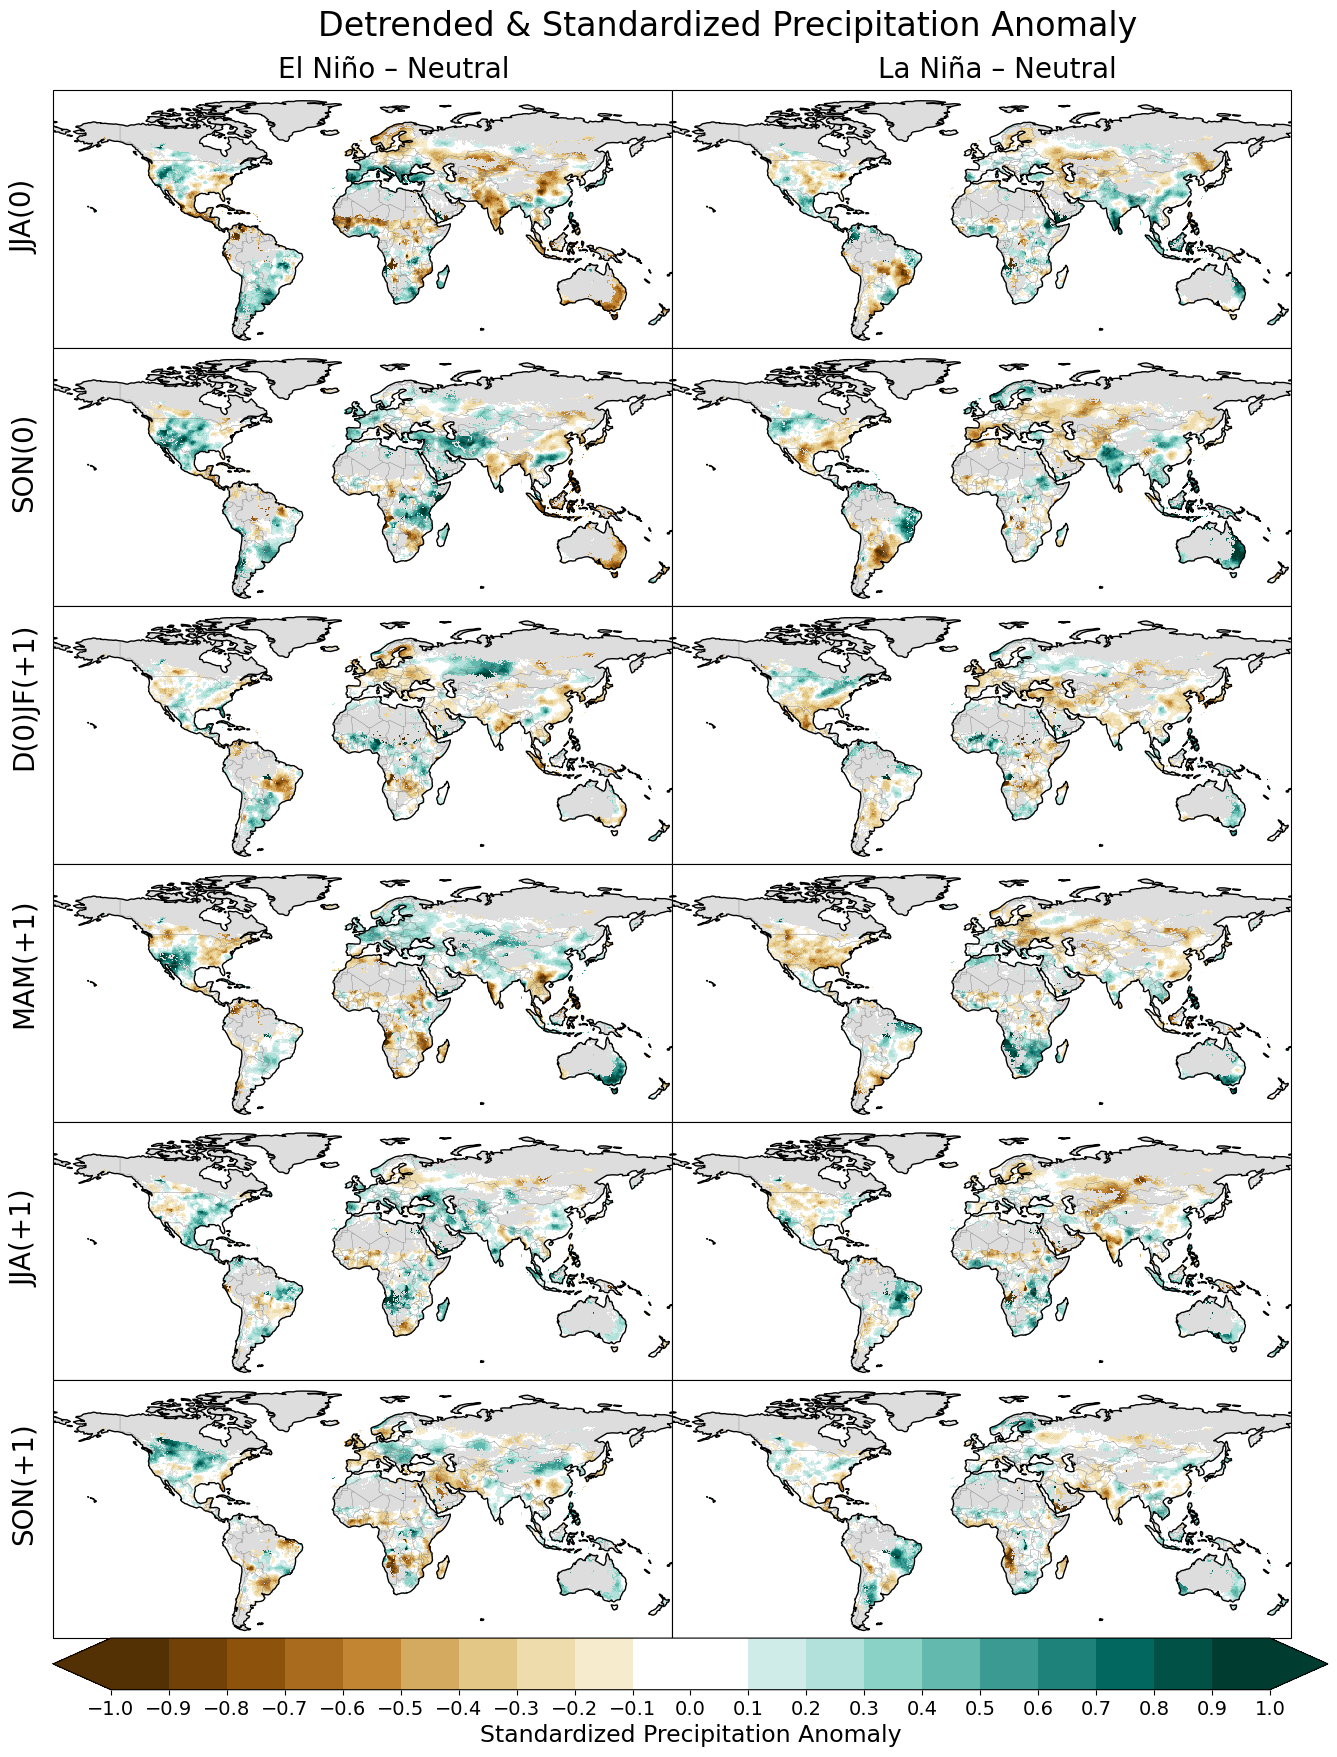

In [9]:
# your season names and titles
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# custom BrBG with white midpoint
brbg = plt.get_cmap('BrBG')(np.linspace(0,1,20))
brbg[9:11] = [1,1,1,1]  # force two central entries to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', brbg, N=20)
levels = np.linspace(-1.0, 1.0, 21)

fig = plt.figure(figsize=(15,20))
gs =  fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# axes lists
axs_el = [fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree()) for i in range(6)]
axs_la = [fig.add_subplot(gs[i,1], projection=ccrs.PlateCarree()) for i in range(6)]

# plot each season
for ax_el, ax_la, data_el, data_la, title in zip(
    axs_el,
    axs_la,
    pre_el_nino_minus_neutral_cropmask,
    pre_la_nina_minus_neutral_cropmask,
    titles
):
    # El Niño – Neutral
    im = ax_el.pcolormesh(
        data_el.lon, data_el.lat, data_el,
        cmap=cmap, vmin=-1.0, vmax=1.0,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_el.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_el.coastlines()
    ax_el.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_el.add_feature(cfeature.LAND, facecolor='#dddddd')
    ax_el.text(-205, -2, title, fontsize=20, ha='left', rotation='vertical')

    # La Niña – Neutral
    ax_la.pcolormesh(
        data_la.lon, data_la.lat, data_la,
        cmap=cmap, vmin=-1.0, vmax=1.0,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_la.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_la.coastlines()
    ax_la.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_la.add_feature(cfeature.LAND, facecolor='#dddddd')

# shared colorbar
cbar_ax = fig.add_subplot(gs[-1, :])  # Span all columns
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Standardized Precipitation Anomaly', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# super-title and column labels
fig.suptitle('Detrended & Standardized Precipitation Anomaly', fontsize=24, x=0.50, y=0.94)

fig.text(0.20, 0.91, 'El Niño – Neutral', fontsize=20, va='center')
fig.text(0.60, 0.91, 'La Niña – Neutral', fontsize=20, va='center')

# adjust margins
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
plt.show()

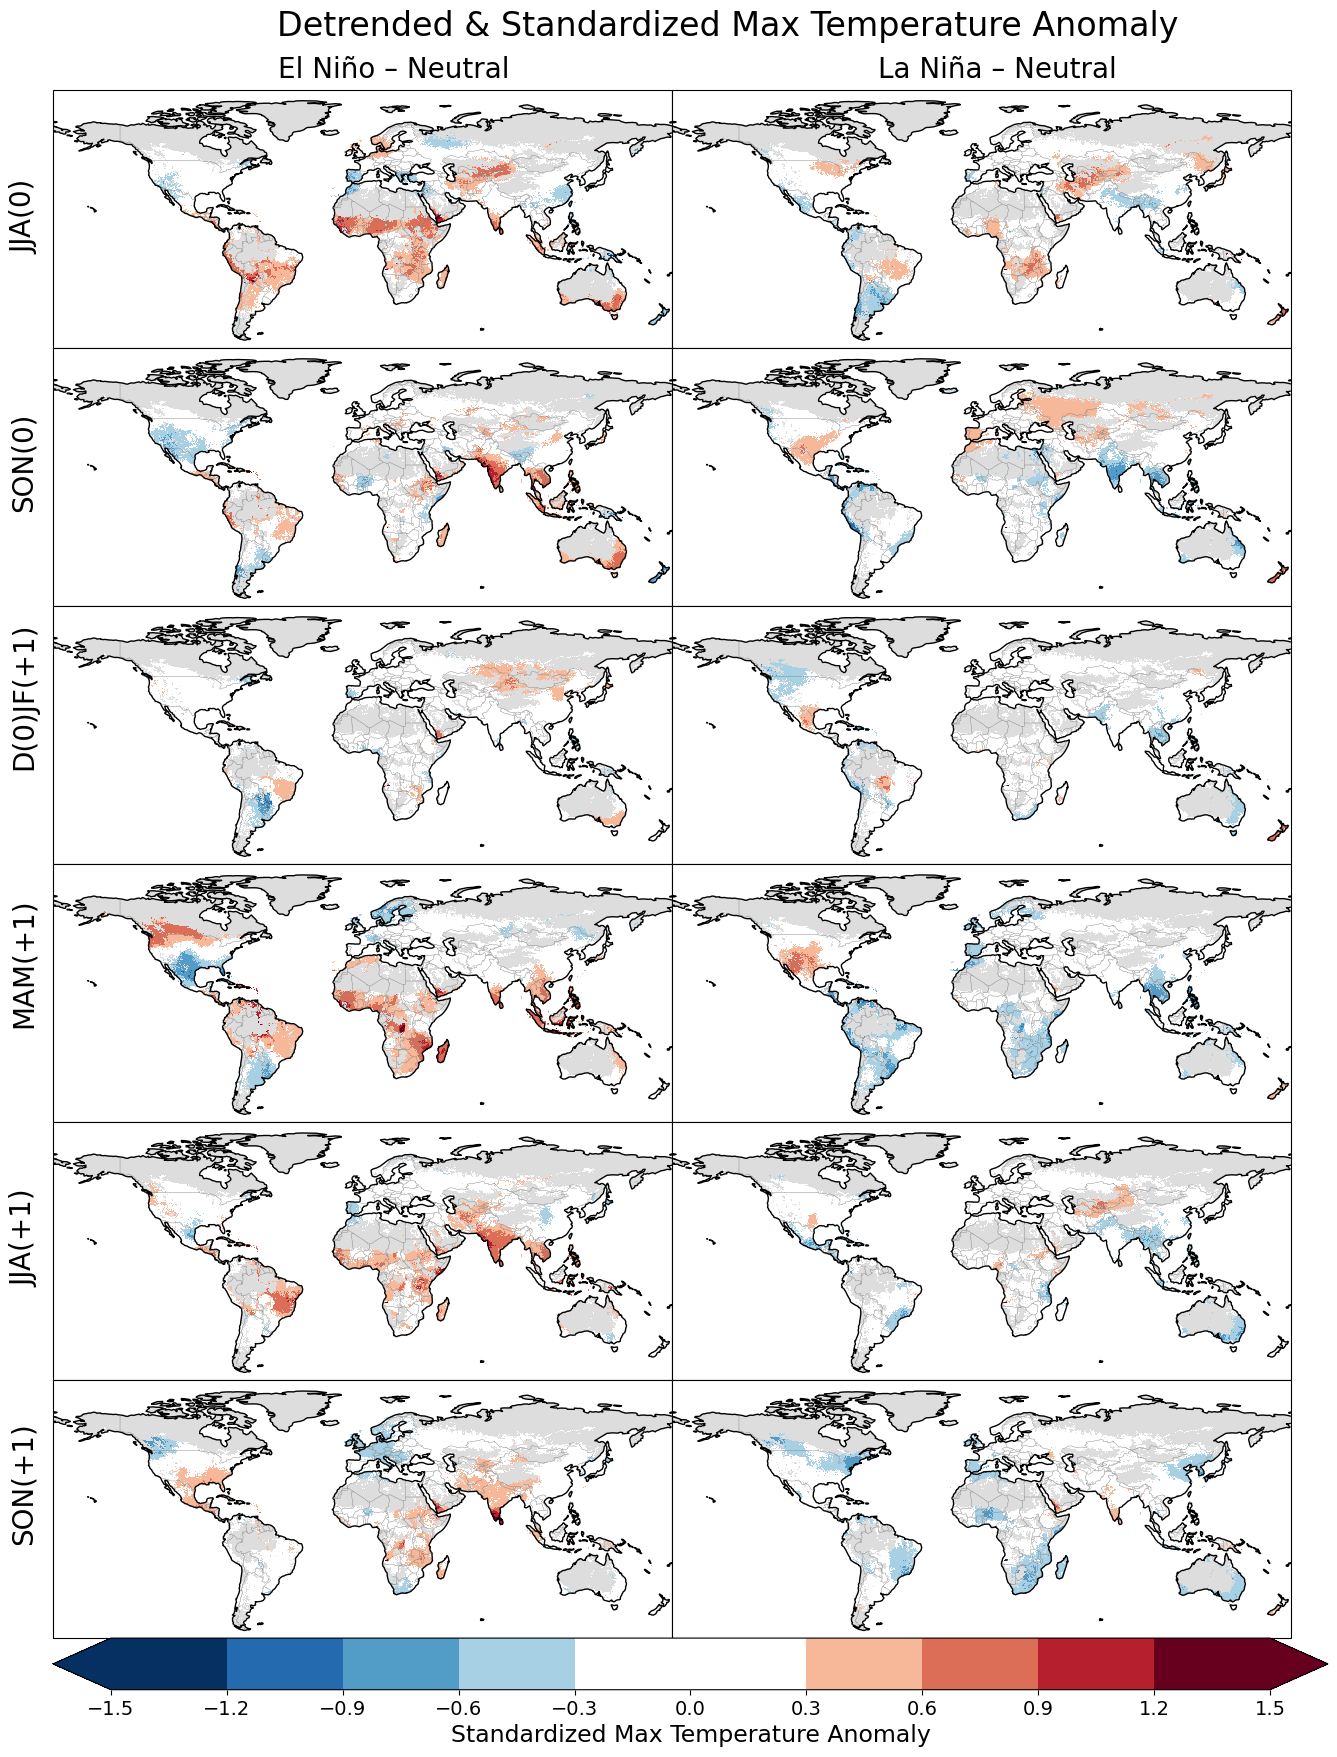

In [10]:
# your season names and titles
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# Sample colors from 'BrBG'
rdbu_rcolors = plt.get_cmap('RdBu_r')(np.linspace(0, 1, 10))
rdbu_rcolors[4] = [1, 1, 1, 1]  # Set the tenth color to white
rdbu_rcolors[5] = [1, 1, 1, 1]  # Set the tenth color to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', rdbu_rcolors, N=10)
levels = np.linspace(-1.5, 1.5, 11)

fig = plt.figure(figsize=(15,20))
gs =  fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# axes lists
axs_el = [fig.add_subplot(gs[i,0], projection=ccrs.PlateCarree()) for i in range(6)]
axs_la = [fig.add_subplot(gs[i,1], projection=ccrs.PlateCarree()) for i in range(6)]

# plot each season
for ax_el, ax_la, data_el, data_la, title in zip(
    axs_el,
    axs_la,
    tmx_el_nino_minus_neutral_cropmask,
    tmx_la_nina_minus_neutral_cropmask,
    titles
):
    # El Niño – Neutral
    im = ax_el.pcolormesh(
        data_el.lon, data_el.lat, data_el,
        cmap=cmap, vmin=-1.5, vmax=1.5,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_el.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_el.coastlines()
    ax_el.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_el.add_feature(cfeature.LAND, facecolor='#dddddd')
    ax_el.text(-205, -2, title, fontsize=20, ha='left', rotation='vertical')

    # La Niña – Neutral
    ax_la.pcolormesh(
        data_la.lon, data_la.lat, data_la,
        cmap=cmap, vmin=-1.5, vmax=1.5,
        transform=ccrs.PlateCarree(), shading='auto'
    )
    ax_la.set_extent([-182,180,-60,90], ccrs.PlateCarree())
    ax_la.coastlines()
    ax_la.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax_la.add_feature(cfeature.LAND, facecolor='#dddddd')

# shared colorbar
cbar_ax = fig.add_subplot(gs[-1, :])  # Span all columns
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Standardized Max Temperature Anomaly', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# super-title and column labels
fig.suptitle('Detrended & Standardized Max Temperature Anomaly', fontsize=24, x=0.50, y=0.94)

fig.text(0.20, 0.91, 'El Niño – Neutral', fontsize=20, va='center')
fig.text(0.60, 0.91, 'La Niña – Neutral', fontsize=20, va='center')

# adjust margins
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
plt.show()

In [11]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_counts = {condition: {} for condition in datasets.keys()}
hot_wet_counts = {condition: {} for condition in datasets.keys()}

# Total number of years for each ENSO phase (constant values)
total_years = {
    "el": len(std_tmx_anom_el[0]["year"]),
    "la": len(std_tmx_anom_la[0]["year"]),
    "ne": len(std_tmx_anom_ne[0]["year"]),
}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Count hot-dry and hot-wet occurrences per grid cell
        hot_dry_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] > 1) # Hot and wet

        # Convert boolean mask to count occurrences per grid cell
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season].sum(dim='year')
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season].sum(dim='year')
        
        # Apply cropland mask
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season].where(cropland_0p5['Band1'] > 0)
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season].where(cropland_0p5['Band1'] > 0)

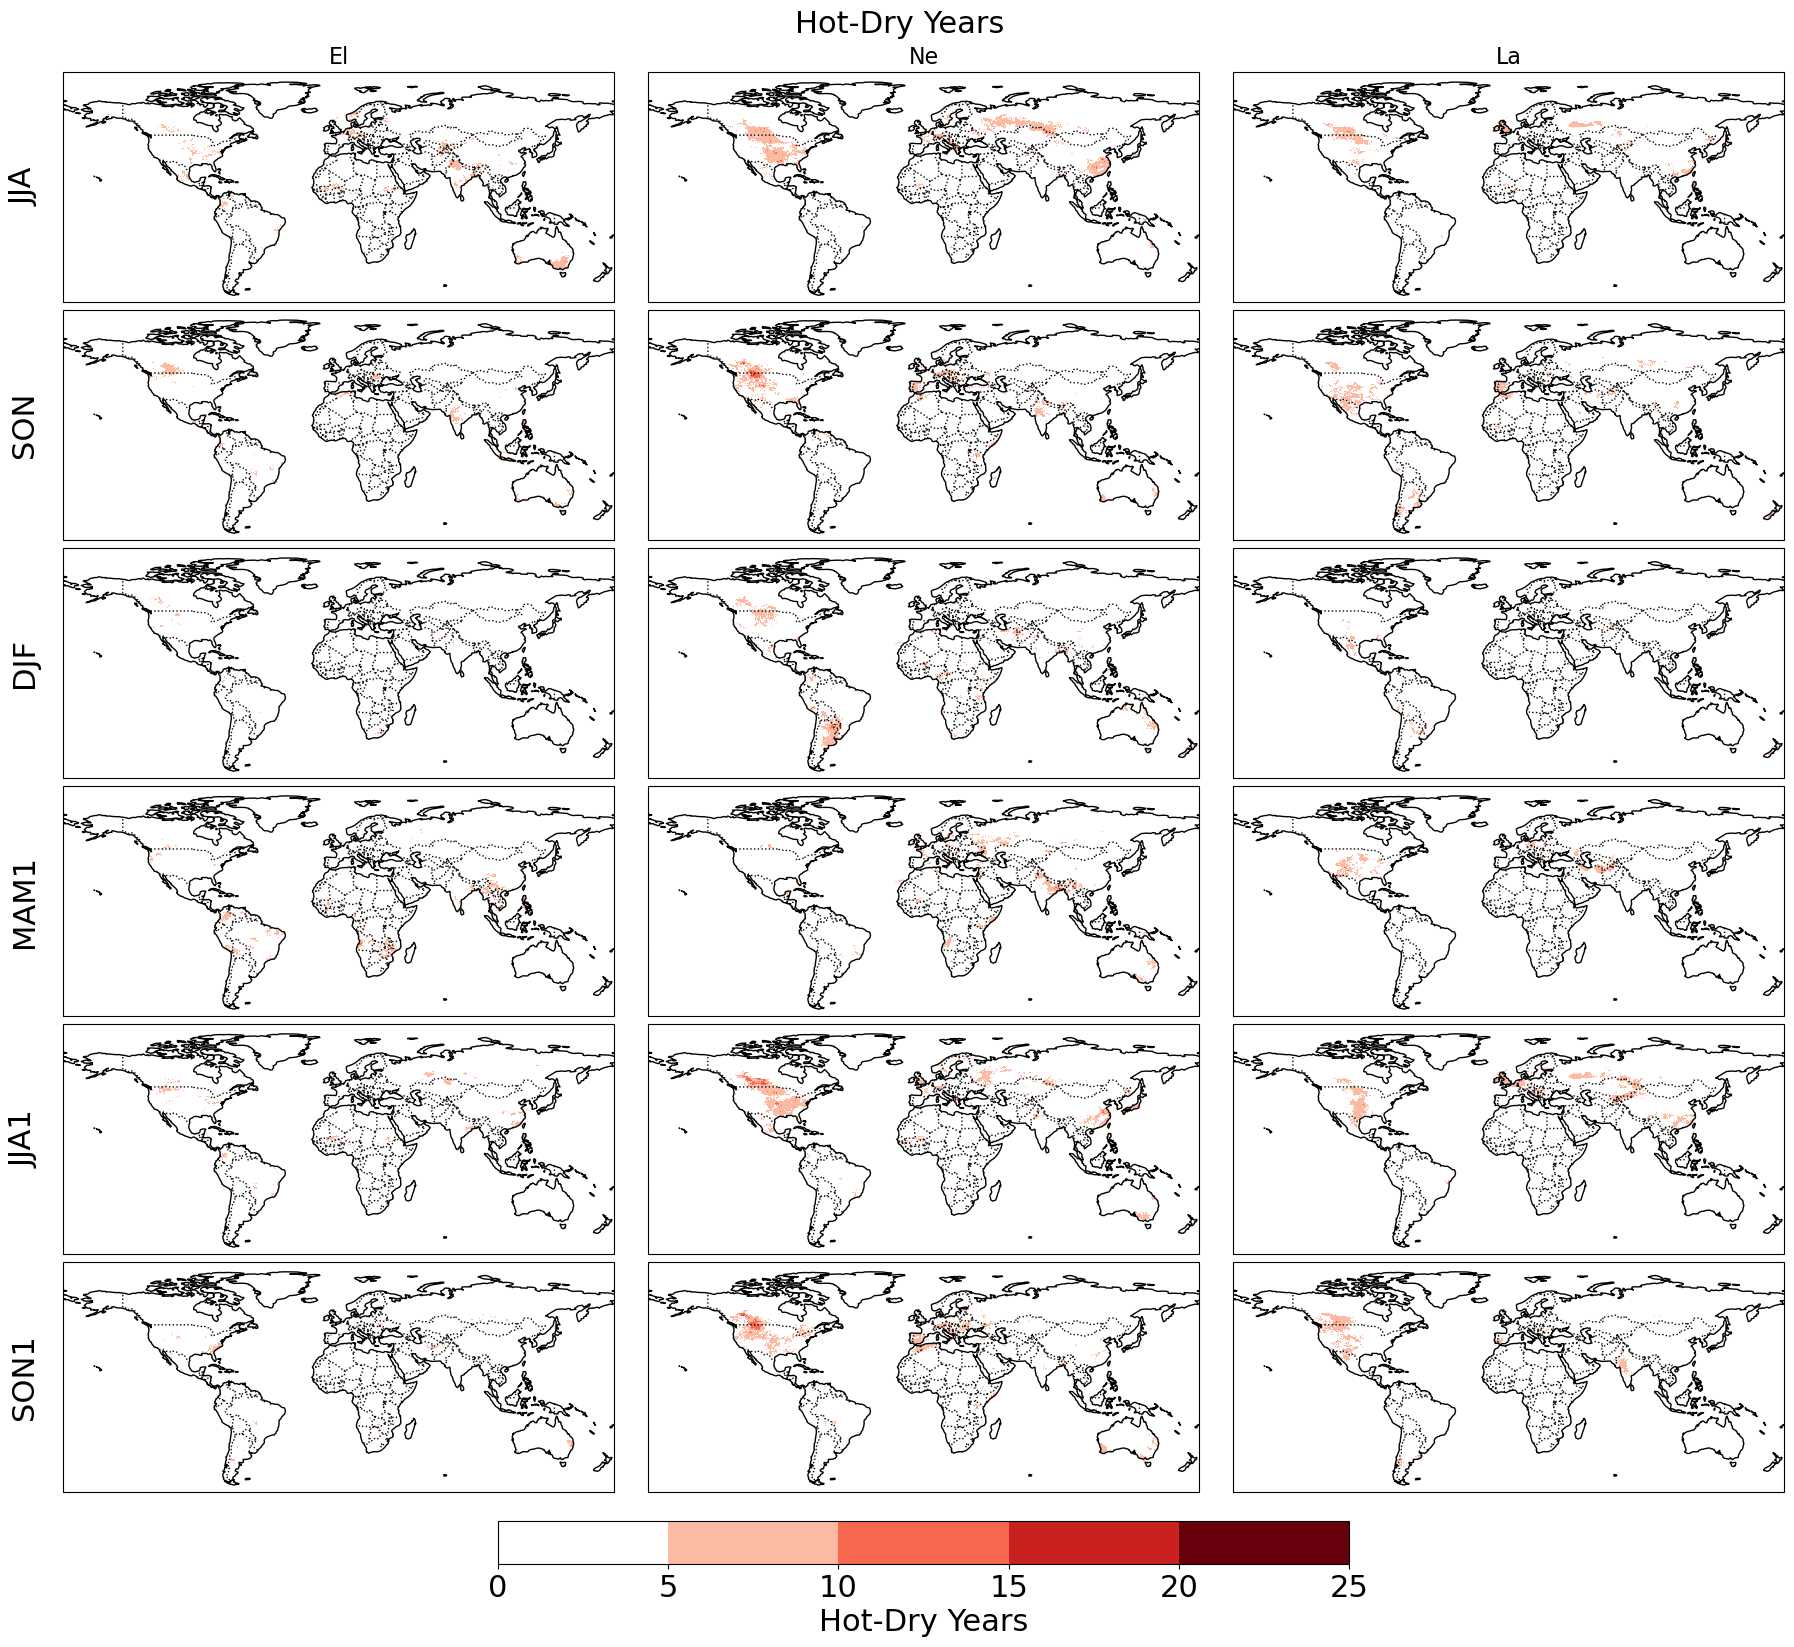

In [12]:
# Define discrete levels for the color scale and corresponding colors
levels = [0, 5, 10, 15, 20, 25]
colors = ["white"] + plt.cm.Reds(np.linspace(0.2, 1, len(levels) - 1)).tolist()
cmap = mcolors.LinearSegmentedColormap.from_list("WhiteToReds", colors, N=len(levels) - 1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=len(levels) - 1)

# Initialize figure and axes for a panel plot
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 16), 
                         subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)

# Define conditions and seasons
conditions = ['el', 'ne', 'la']
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Loop through seasons and conditions to plot each panel
for i, season in enumerate(seasons):
    for j, condition in enumerate(conditions):
        ax = axes[i, j]
        
        # Select the data for hot-dry percent years
        data = hot_dry_counts[condition][season]
        
        # Plot the data with the custom colormap
        im = data.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False, transform=ccrs.PlateCarree())
        
        # Add coastlines and borders
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        
        # Set the geographic extent
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        
        # Add titles and labels
        if i == 0:
            ax.set_title(condition.capitalize(), fontsize=16)
        if j == 0:
            ax.text(-0.07, 0.5, season.upper(), va='center', ha='center', 
                    rotation=90, fontsize=22, transform=ax.transAxes)

# Add a colorbar to the figure
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', 
                    fraction=0.03, pad=0.02, ticks=levels)

# **Increase font size for colorbar**
cbar.set_label('Hot-Dry Years', fontsize=22)  # Larger label font size
cbar.ax.tick_params(labelsize=22)  # Larger tick label size

# Show the plot
plt.suptitle('Hot-Dry Years', fontsize=22, y=1.02)
plt.show()

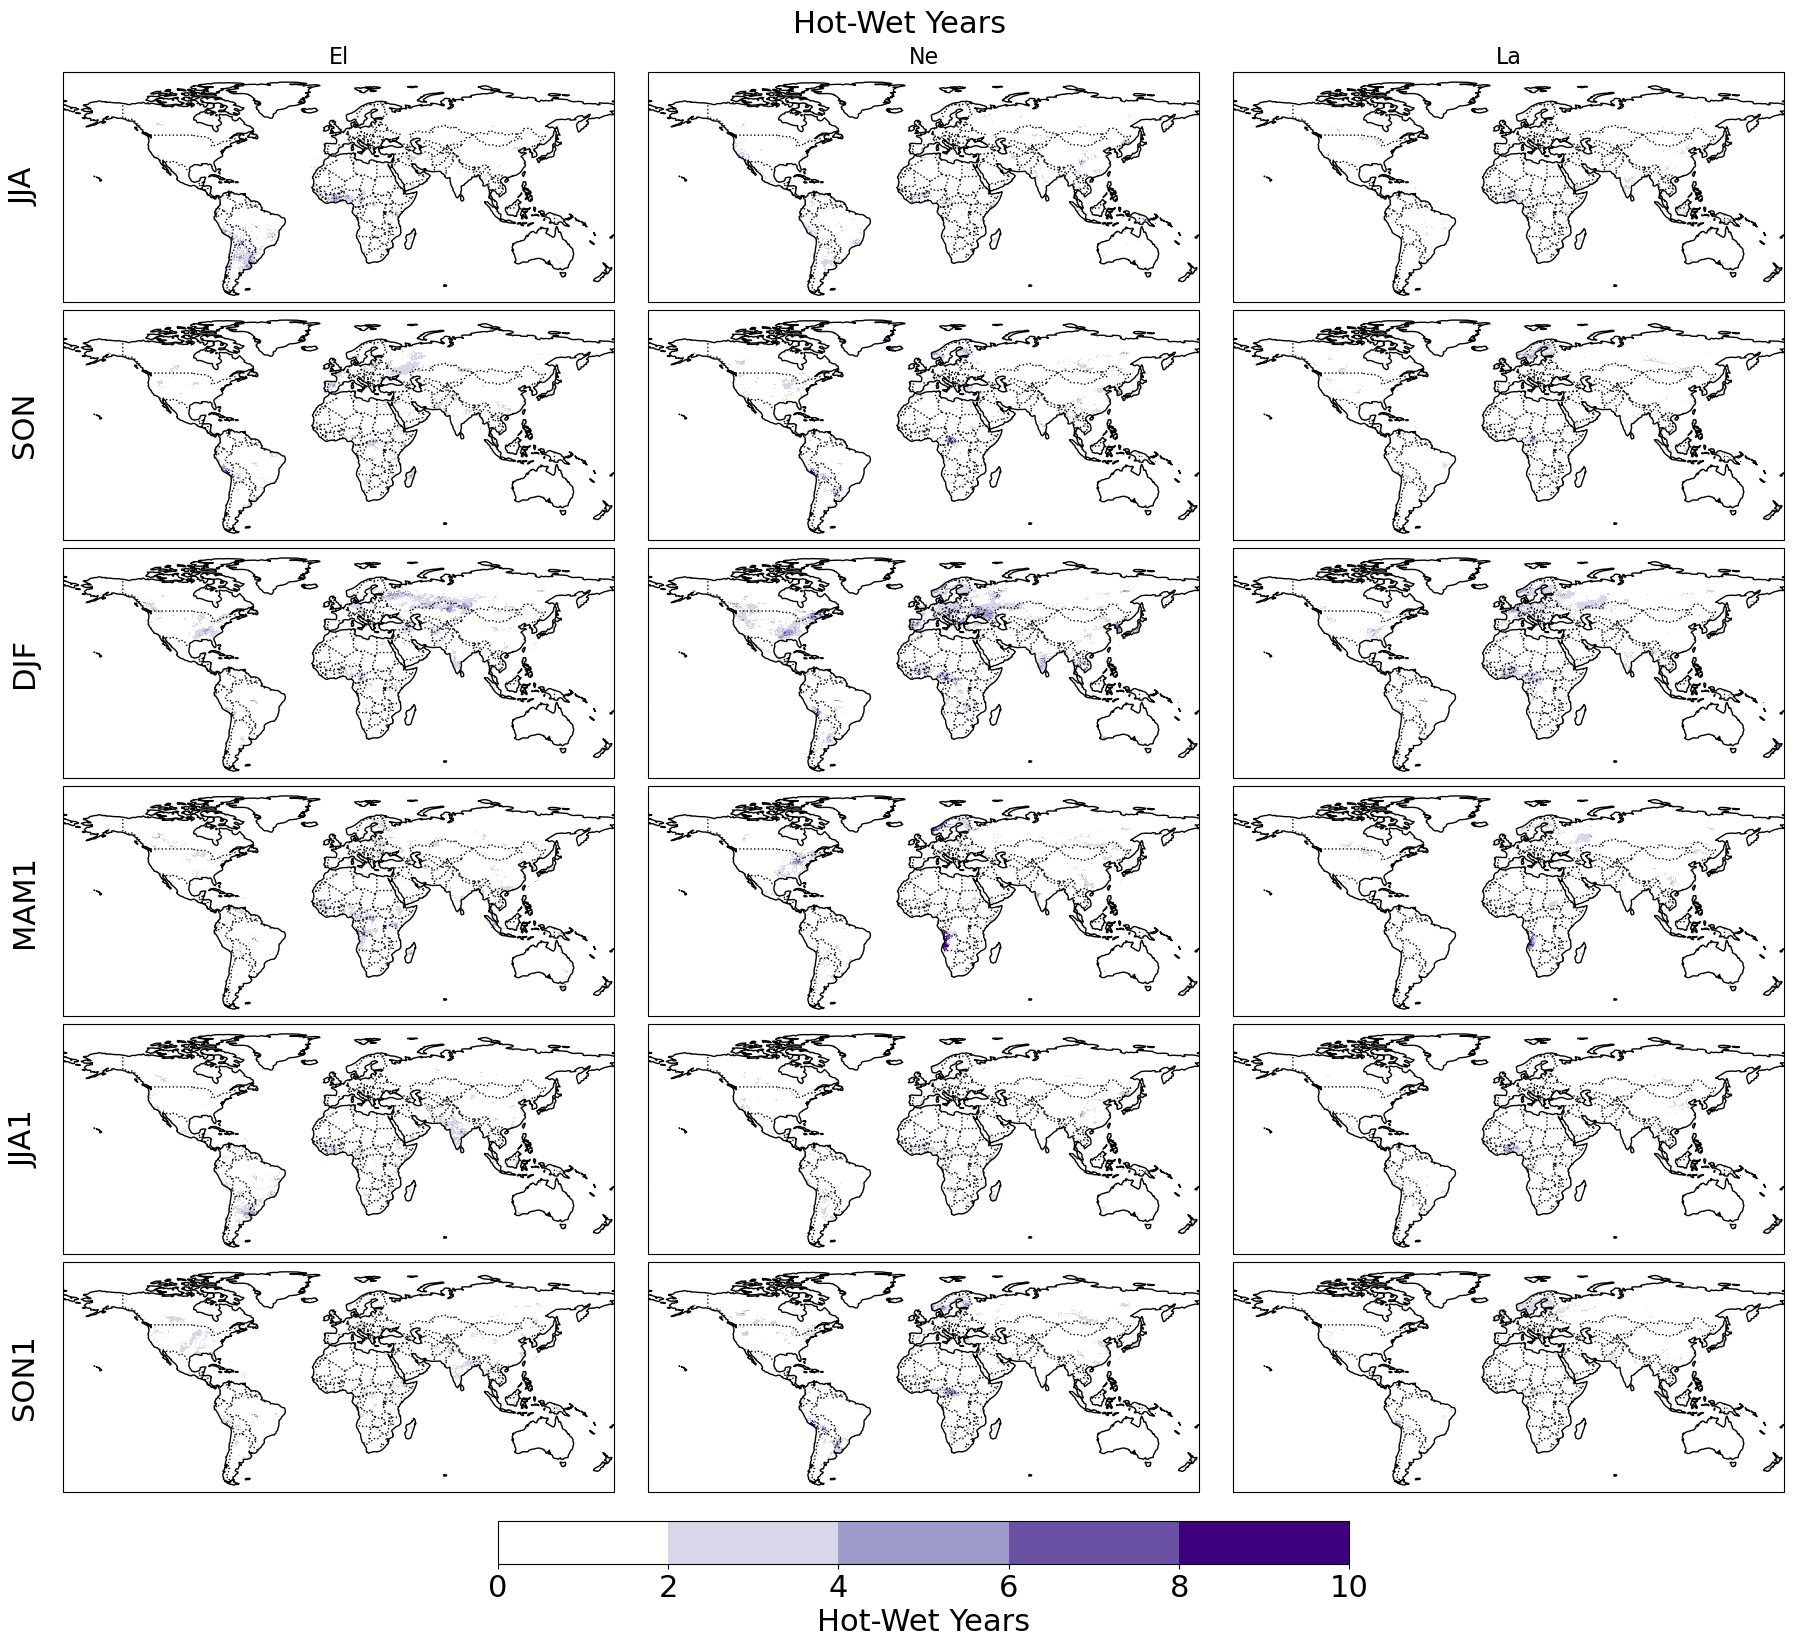

In [13]:
# Define discrete levels for the color scale and corresponding colors
levels = [0, 2, 4, 6, 8, 10]
colors = ["white"] + plt.cm.Purples(np.linspace(0.2, 1, len(levels) - 1)).tolist()
cmap = mcolors.LinearSegmentedColormap.from_list("WhiteToPurples", colors, N=len(levels) - 1)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=len(levels) - 1)

# Initialize figure and axes for a panel plot
fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(18, 16), 
                         subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)

# Define conditions and seasons
conditions = ['el', 'ne', 'la']
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Loop through seasons and conditions to plot each panel
for i, season in enumerate(seasons):
    for j, condition in enumerate(conditions):
        ax = axes[i, j]
        
        # Select the data for hot-dry percent years
        data = hot_wet_counts[condition][season]
        
        # Plot the data with the custom colormap
        im = data.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False, transform=ccrs.PlateCarree())
        
        # Add coastlines and borders
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        
        # Set the geographic extent
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        
        # Add titles and labels
        if i == 0:
            ax.set_title(condition.capitalize(), fontsize=16)
        if j == 0:
            ax.text(-0.07, 0.5, season.upper(), va='center', ha='center', 
                    rotation=90, fontsize=22, transform=ax.transAxes)

# Add a colorbar to the figure
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), orientation='horizontal', 
                    fraction=0.03, pad=0.02, ticks=levels)

# **Increase font size for colorbar**
cbar.set_label('Hot-Wet Years', fontsize=22)  # Larger label font size
cbar.ax.tick_params(labelsize=22)  # Larger tick label size

# Show the plot
plt.suptitle('Hot-Wet Years', fontsize=22, y=1.02)
plt.show()

In [14]:
# Prepare empty dicts
diff_hot_dry_el_ne = {}
diff_hot_dry_la_ne = {}
diff_hot_wet_el_ne = {}
diff_hot_wet_la_ne = {}

# Loop over each season
for season in seasons:
    # Hot-dry: El Niño minus Neutral
    diff_hot_dry_el_ne[season] = (
        hot_dry_counts['el'][season]
        - hot_dry_counts['ne'][season]
    )
    # Hot-dry: La Niña minus Neutral
    diff_hot_dry_la_ne[season] = (
        hot_dry_counts['la'][season]
        - hot_dry_counts['ne'][season]
    )
    # Hot-wet: El Niño minus Neutral
    diff_hot_wet_el_ne[season] = (
        hot_wet_counts['el'][season]
        - hot_wet_counts['ne'][season]
    )
    # Hot-wet: La Niña minus Neutral
    diff_hot_wet_la_ne[season] = (
        hot_wet_counts['la'][season]
        - hot_wet_counts['ne'][season]
    )

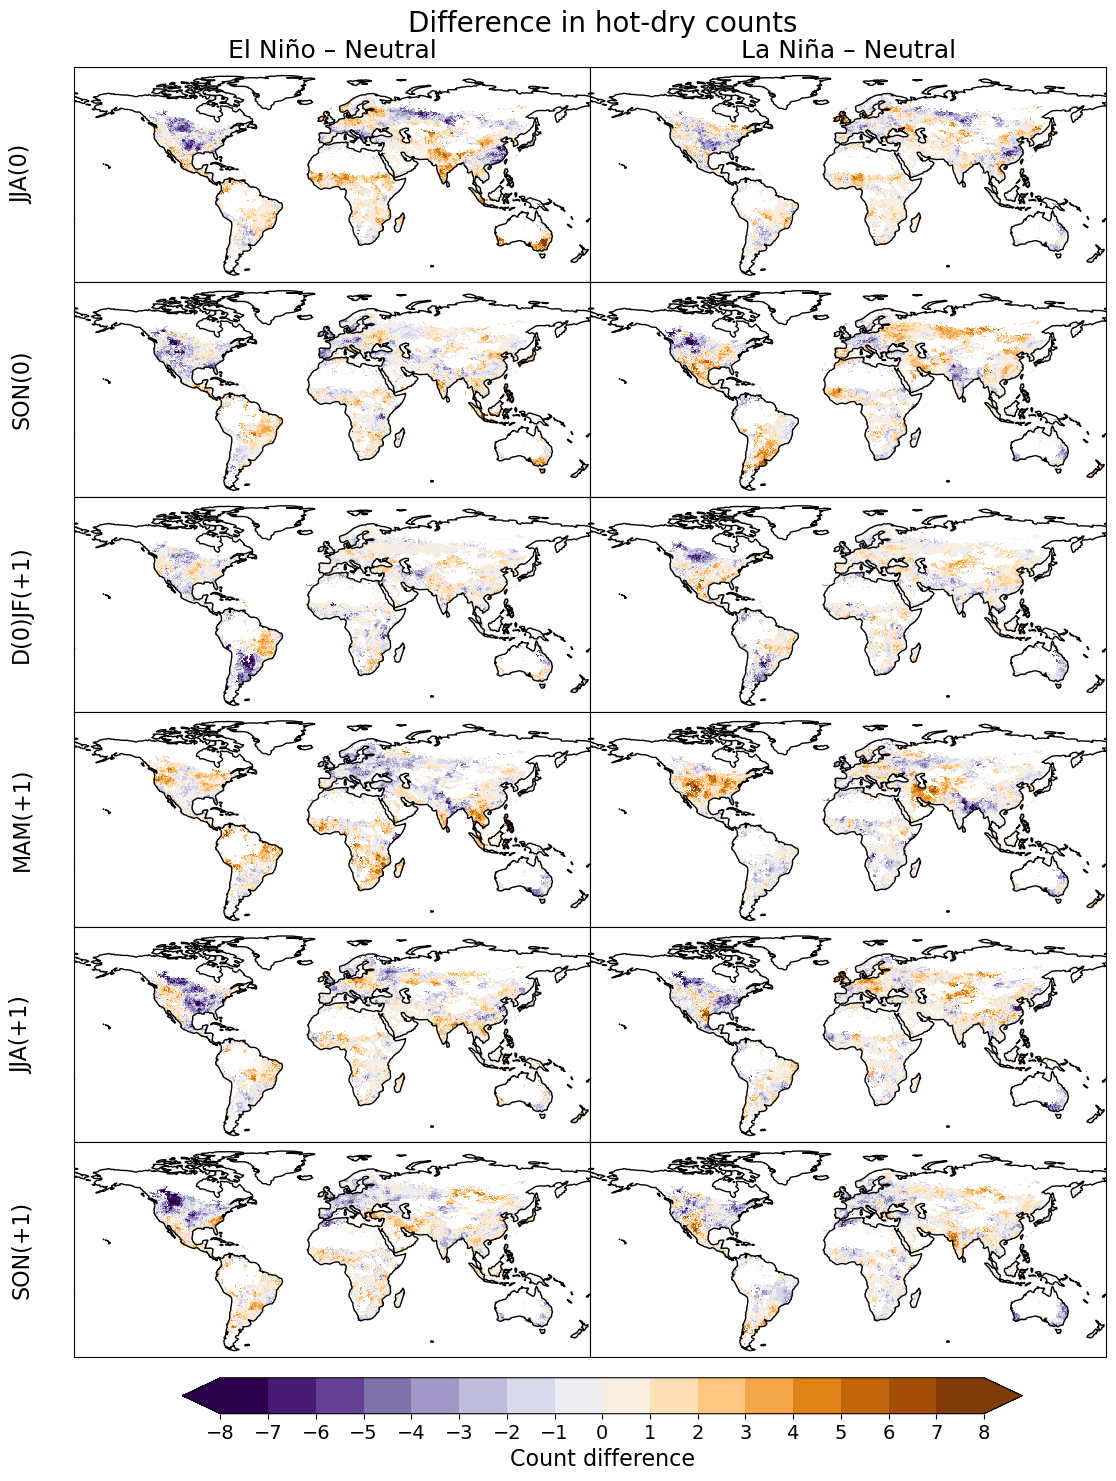

In [15]:
# Your seasons in the order you want them plotted
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Custom labels for each season
season_labels = {
    "jja":  "JJA(0)",
    "son":  "SON(0)",
    "djf":  "D(0)JF(+1)",
    "mam1": "MAM(+1)",
    "jja1": "JJA(+1)",
    "son1": "SON(+1)"
}

# 1) Discrete bins and normalization
bounds = [-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]
cmap   = plt.get_cmap('PuOr_r')
norm   = mcolors.BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

# 2) Create figure and GeoAxes grid
fig, axes = plt.subplots(
    nrows=len(seasons), ncols=2,
    figsize=(12, 3 * len(seasons)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# 3) Super‐title and column titles
fig.suptitle('Difference in hot-dry counts', fontsize=20, y=0.89)
axes[0, 0].set_title('El Niño – Neutral', fontsize=18)
axes[0, 1].set_title('La Niña – Neutral', fontsize=18)

# 4) Plot each panel
for i, season in enumerate(seasons):
    # Vertical season label next to left panel
    ax0 = axes[i, 0]
    ax0.text(
        -0.08, 0.5,                    # slightly inside the left margin
        season_labels[season],         # custom label
        transform=ax0.transAxes,
        va='center', ha='right',
        rotation=90, fontsize=16
    )
    
    # Two columns: El Niño–Neutral and La Niña–Neutral
    for j, diff_dict in enumerate([diff_hot_dry_el_ne, diff_hot_dry_la_ne]):
        ax = axes[i, j]
        da = diff_dict[season]
        
        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da.values,
            cmap=cmap, norm=norm, shading='auto',
            transform=ccrs.PlateCarree()
        )
        ax.coastlines()
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax.tick_params(labelsize=14)

# 5) Single horizontal discrete colorbar beneath maps
cax = fig.add_axes([0.15, 0.11, 0.7, 0.02])  # [left, bottom, width, height]
cb = fig.colorbar(
    mesh, cax=cax, orientation='horizontal',
    boundaries=bounds, ticks=bounds, spacing='uniform',
    extend='both', label='Count difference'
)
cb.ax.tick_params(labelsize=14)
cb.ax.xaxis.label.set_size(16)

# 6) Tidy up spacing so panels and colorbar touch
fig.subplots_adjust(
    left=0.06,    # space for season labels
    right=0.92,
    top=0.90,
    bottom=0.10,
    hspace=-0.41,   # no vertical gap between rows
    wspace=0.0    # no horizontal gap between columns
)

plt.show()

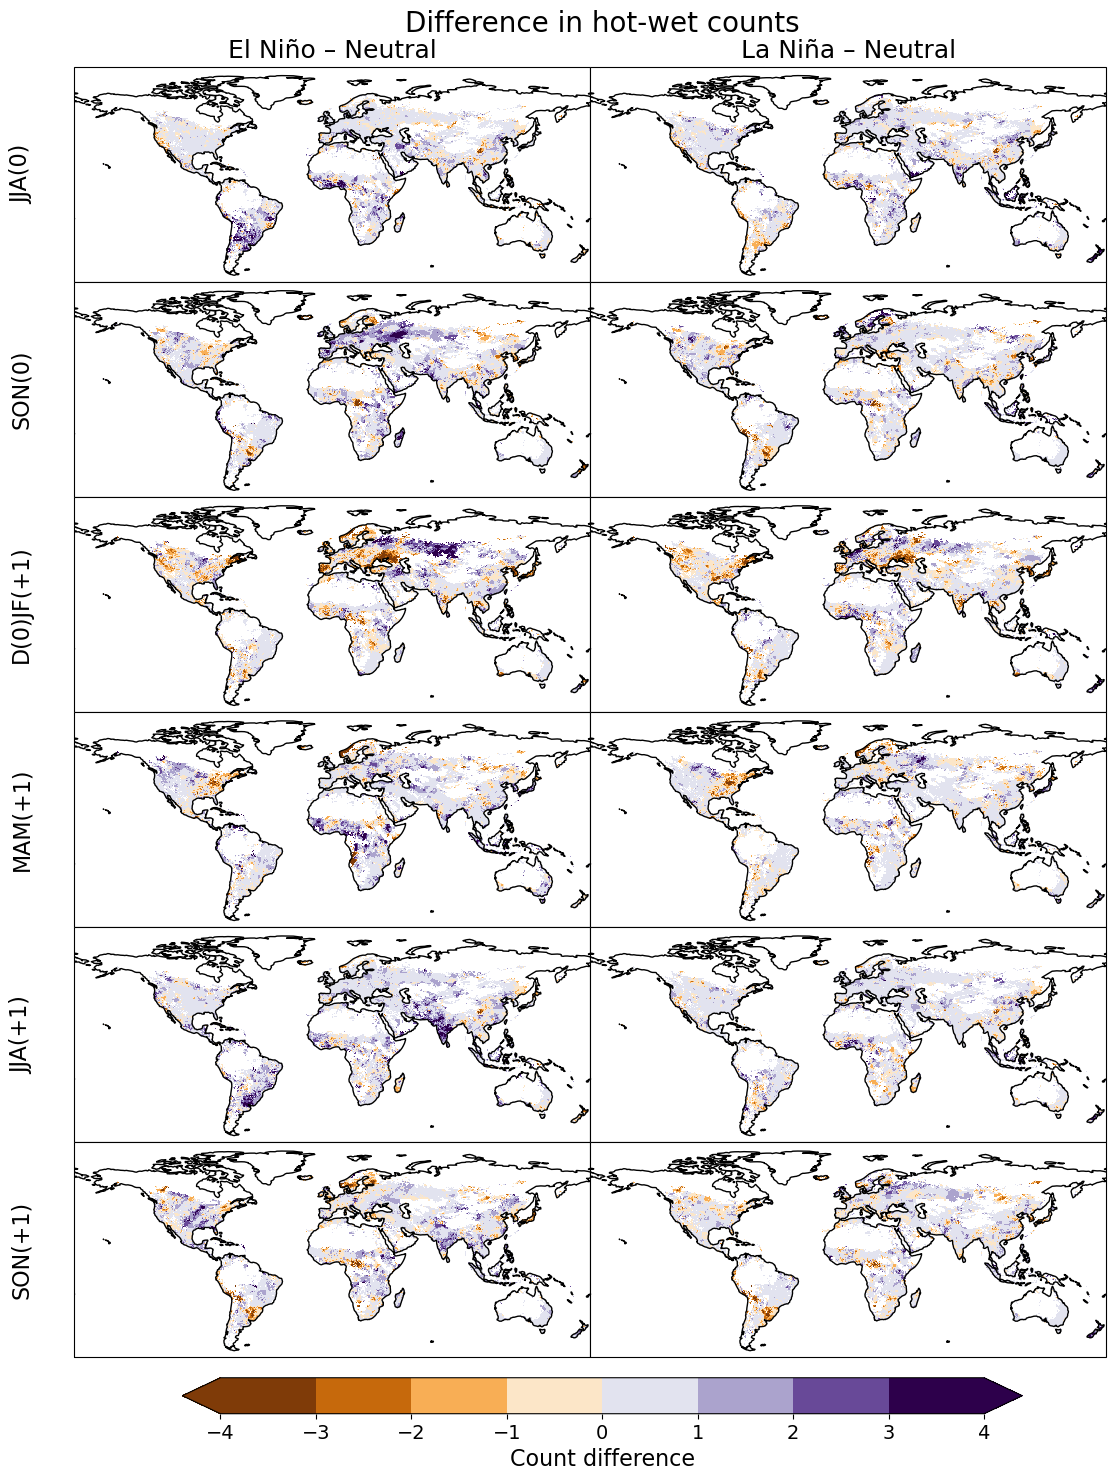

In [16]:
# Your seasons in the order you want them plotted
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Custom labels for each season
season_labels = {
    "jja":  "JJA(0)",
    "son":  "SON(0)",
    "djf":  "D(0)JF(+1)",
    "mam1": "MAM(+1)",
    "jja1": "JJA(+1)",
    "son1": "SON(+1)"
}

# 1) Discrete bins and normalization
bounds = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
cmap   = plt.get_cmap('PuOr')
norm   = mcolors.BoundaryNorm(bounds, ncolors=cmap.N, clip=True)

# 2) Create figure and GeoAxes grid
fig, axes = plt.subplots(
    nrows=len(seasons), ncols=2,
    figsize=(12, 3 * len(seasons)),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# 3) Super‐title and column titles
fig.suptitle('Difference in hot-wet counts', fontsize=20, y=0.89)
axes[0, 0].set_title('El Niño – Neutral', fontsize=18)
axes[0, 1].set_title('La Niña – Neutral', fontsize=18)

# 4) Plot each panel
for i, season in enumerate(seasons):
    # Vertical season label next to left panel
    ax0 = axes[i, 0]
    ax0.text(
        -0.08, 0.5,                    # slightly inside the left margin
        season_labels[season],         # custom label
        transform=ax0.transAxes,
        va='center', ha='right',
        rotation=90, fontsize=16
    )
    
    # Two columns: El Niño–Neutral and La Niña–Neutral
    for j, diff_dict in enumerate([diff_hot_wet_el_ne, diff_hot_wet_la_ne]):
        ax = axes[i, j]
        da = diff_dict[season]
        
        mesh = ax.pcolormesh(
            da['lon'], da['lat'], da.values,
            cmap=cmap, norm=norm, shading='auto',
            transform=ccrs.PlateCarree()
        )
        ax.coastlines()
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax.tick_params(labelsize=14)

# 5) Single horizontal discrete colorbar beneath maps
cax = fig.add_axes([0.15, 0.11, 0.7, 0.02])  # [left, bottom, width, height]
cb = fig.colorbar(
    mesh, cax=cax, orientation='horizontal',
    boundaries=bounds, ticks=bounds, spacing='uniform',
    extend='both', label='Count difference'
)
cb.ax.tick_params(labelsize=14)
cb.ax.xaxis.label.set_size(16)

# 6) Tidy up spacing so panels and colorbar touch
fig.subplots_adjust(
    left=0.06,    # space for season labels
    right=0.92,
    top=0.90,
    bottom=0.10,
    hspace=-0.41,   # no vertical gap between rows
    wspace=0.0    # no horizontal gap between columns
)

plt.show()

In [17]:
print((hot_dry_counts['el']['jja'] > 0).sum().item())
print((hot_dry_counts['la']['jja'] > 0).sum().item())
print((hot_dry_counts['ne']['jja'] > 0).sum().item())

24059
22040
23090


In [18]:
hot_dry_counts['el']['jja']
hot_dry_counts['la']['jja']
hot_dry_counts['ne']['jja']

<xarray.DataArray (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

In [19]:
# Define seasons
seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# Group all conditions into a dictionary
datasets = {
    "el": {"tmx": std_tmx_anom_el, "pre": std_pre_anom_el},
    "la": {"tmx": std_tmx_anom_la, "pre": std_pre_anom_la},
    "ne": {"tmx": std_tmx_anom_ne, "pre": std_pre_anom_ne},
}

# Initialize a dictionary to store results
hot_dry_counts = {condition: {} for condition in datasets.keys()}
hot_wet_counts = {condition: {} for condition in datasets.keys()}

# Total number of years for each ENSO phase (constant values)
total_years = {
    "el": len(std_tmx_anom_el[0]["year"]),
    "la": len(std_tmx_anom_la[0]["year"]),
    "ne": len(std_tmx_anom_ne[0]["year"]),
}

# Loop through each condition and season to calculate conditions
for condition, data in datasets.items():
    for i, season in enumerate(seasons):
        # Count hot-dry and hot-wet occurrences per grid cell
        hot_dry_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] < -1)  # Hot and dry
        hot_wet_counts[condition][season] = (data["tmx"][i] > 1) & (data["pre"][i] > 1) # Hot and wet

        # Convert boolean mask to count occurrences per grid cell
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season]
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season]
        
        # Apply cropland mask
        hot_dry_counts[condition][season] = hot_dry_counts[condition][season].where(cropland_0p5['Band1'] > 0)
        hot_wet_counts[condition][season] = hot_wet_counts[condition][season].where(cropland_0p5['Band1'] > 0)

In [20]:
# hot_dry_counts['el']['jja'][:,219,511]
# hot_dry_counts['ne']['jja'][:,219,511]

In [21]:
# Define bootstrap parameters
n_bootstrap = 1000
alpha = 0.1  # Significance threshold

# Define the specific grid cell (Change these indices as needed)
lat_idx, lon_idx = 219, 523  # Example grid cell indices

# Extract data for the selected grid cell
el_series = hot_dry_counts['el']['jja'][:, lat_idx, lon_idx].values
ne_series = hot_dry_counts['ne']['jja'][:, lat_idx, lon_idx].values

# Function to bootstrap and calculate p-value
def bootstrap_p_value(series1, series2, n_bootstrap=1000):
    observed_diff = np.nanmean(series1) - np.nanmean(series2)
    
    combined = np.concatenate([series1, series2])
    bootstrap_diffs = []
    
    for _ in range(n_bootstrap):
        np.random.shuffle(combined)  # Shuffle combined data
        sample1 = np.random.choice(combined, size=len(series1), replace=True)
        sample2 = np.random.choice(combined, size=len(series2), replace=True)
        bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))
    
    # Compute p-value as the proportion of bootstrap samples greater than observed
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
    return p_value

# Check if the grid cell has valid (non-NaN) values
if not (np.isnan(el_series).all() or np.isnan(ne_series).all()):
    # Compute bootstrap p-value
    p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)

    # Determine significance
    is_significant = p_val < alpha

    # Print results
    print(f"Bootstrap P-value: {p_val:.5f}")
    print(f"Significant Difference (p < {alpha}): {is_significant}")
else:
    print("Grid cell contains only NaN values, skipping bootstrap test.")

Bootstrap P-value: 0.01600
Significant Difference (p < 0.1): True


In [22]:
# # params
# n_bootstrap = 10000
# alpha = 0.10  # two-sided
# rng = np.random.default_rng(42)

# def bootstrap_p_value(a, b, n_bootstrap=n_bootstrap, rng=None):
#     # Vectorized bootstrap: same logic, much faster
#     a = a[np.isfinite(a)]
#     b = b[np.isfinite(b)]
#     if a.size == 0 or b.size == 0:
#         return np.nan

#     observed = np.nanmean(a) - np.nanmean(b)
#     pooled = np.concatenate([a, b]).astype(np.float64, copy=False)
#     na, nb = a.size, b.size

#     if rng is None:
#         rng = np.random.default_rng()

#     # Draw all resamples at once (indices), then take means in one shot
#     idx1 = rng.integers(0, pooled.size, size=(n_bootstrap, na))
#     idx2 = rng.integers(0, pooled.size, size=(n_bootstrap, nb))

#     s1_means = pooled[idx1].mean(axis=1)
#     s2_means = pooled[idx2].mean(axis=1)
#     diffs = s1_means - s2_means

#     p_value = np.mean(np.abs(diffs) >= abs(observed))
#     return p_value

# # --- in your loop, precompute valid cells to skip NaN-only ones early ---
# lat_vals = hot_dry_counts['el']['jja'].lat.values
# lon_vals = hot_dry_counts['el']['jja'].lon.values
# significant_grid = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

# start_time = time.time()
# print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

# # Collect candidate cells once to avoid repeated .any() checks
# candidates = []
# for i in range(len(lat_vals)):
#     el_block = hot_dry_counts['el']['jja'][:, i, :].values
#     ne_block = hot_dry_counts['ne']['jja'][:, i, :].values
#     valid_j = np.logical_and(np.isfinite(el_block).any(axis=0), np.isfinite(ne_block).any(axis=0))
#     for j in np.flatnonzero(valid_j):
#         candidates.append((i, j))

# for i, j in candidates:
#     el_series = hot_dry_counts['el']['jja'][:, i, j].values
#     ne_series = hot_dry_counts['ne']['jja'][:, i, j].values
#     p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap=n_bootstrap, rng=rng)
#     if np.isfinite(p_val) and p_val < alpha:
#         significant_grid[i, j] = True

# significant_xarray = xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])

# end_time = time.time()
# print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
# print(f"Total Execution Time: {end_time - start_time:.2f} seconds")
# print(significant_xarray)

In [23]:
# (significant_xarray>0).sum().item()

In [24]:
# # params (as you already have)
# n_bootstrap = 10000
# alpha = 0.10  # two-sided
# rng = np.random.default_rng(42)
# seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# def bootstrap_p_value(a, b, n_bootstrap=n_bootstrap, rng=None):
#     a = a[np.isfinite(a)]
#     b = b[np.isfinite(b)]
#     if a.size == 0 or b.size == 0:
#         return np.nan

#     observed = np.nanmean(a) - np.nanmean(b)
#     pooled = np.concatenate([a, b]).astype(np.float64, copy=False)
#     na, nb = a.size, b.size

#     if rng is None:
#         rng = np.random.default_rng()

#     idx1 = rng.integers(0, pooled.size, size=(n_bootstrap, na))
#     idx2 = rng.integers(0, pooled.size, size=(n_bootstrap, nb))
#     diffs = pooled[idx1].mean(axis=1) - pooled[idx2].mean(axis=1)

#     return np.mean(np.abs(diffs) >= abs(observed))

# start_time = time.time()
# print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

# sig_maps = []
# for s in seasons:
#     print(f"Processing season: {s}")
#     lat_vals = hot_dry_counts['el'][s].lat.values
#     lon_vals = hot_dry_counts['el'][s].lon.values
#     significant_grid = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

#     # precompute candidates (cells with any finite data for both phases)
#     candidates = []
#     el_block = hot_dry_counts['el'][s].values  # shape: time x lat x lon
#     ne_block = hot_dry_counts['ne'][s].values
#     # any finite along time for each (lat,lon)
#     el_any = np.isfinite(el_block).any(axis=0)
#     ne_any = np.isfinite(ne_block).any(axis=0)
#     valid = np.logical_and(el_any, ne_any)  # require both to have data

#     valid_indices = np.argwhere(valid)
#     for i, j in valid_indices:
#         el_series = el_block[:, i, j]
#         ne_series = ne_block[:, i, j]
#         p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap=n_bootstrap, rng=rng)
#         if np.isfinite(p_val) and p_val < alpha:
#             significant_grid[i, j] = True

#     sig_maps.append(
#         xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])
#     )

# # stack into one DataArray with a season dim
# significant_xarrays = xr.concat(sig_maps, dim=xr.Variable("season", seasons))
# # optional: name it
# significant_xarrays.name = "significant"

# end_time = time.time()
# print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
# print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # quick counts per season
# for s, da in zip(seasons, sig_maps):
#     print(s, (da > 0).sum().item())

# print(significant_xarrays)

In [25]:
# (significant_xarrays[0]>0).sum().item()

In [26]:
# significant_xarrays[0].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_jja.nc")
# significant_xarrays[1].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_son.nc")
# significant_xarrays[2].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_djf.nc")
# significant_xarrays[3].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_mam1.nc")
# significant_xarrays[4].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_jja1.nc")
# significant_xarrays[5].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_son1.nc")

In [27]:
# # params (as you already have)
# n_bootstrap = 10000
# alpha = 0.10  # two-sided
# rng = np.random.default_rng(42)
# seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# def bootstrap_p_value(a, b, n_bootstrap=n_bootstrap, rng=None):
#     a = a[np.isfinite(a)]
#     b = b[np.isfinite(b)]
#     if a.size == 0 or b.size == 0:
#         return np.nan

#     observed = np.nanmean(a) - np.nanmean(b)
#     pooled = np.concatenate([a, b]).astype(np.float64, copy=False)
#     na, nb = a.size, b.size

#     if rng is None:
#         rng = np.random.default_rng()

#     idx1 = rng.integers(0, pooled.size, size=(n_bootstrap, na))
#     idx2 = rng.integers(0, pooled.size, size=(n_bootstrap, nb))
#     diffs = pooled[idx1].mean(axis=1) - pooled[idx2].mean(axis=1)

#     return np.mean(np.abs(diffs) >= abs(observed))

# start_time = time.time()
# print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

# sig_maps = []
# for s in seasons:
#     print(f"Processing season: {s}")
#     lat_vals = hot_dry_counts['la'][s].lat.values
#     lon_vals = hot_dry_counts['la'][s].lon.values
#     significant_grid = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)

#     # precompute candidates (cells with any finite data for both phases)
#     candidates = []
#     la_block = hot_dry_counts['la'][s].values  # shape: time x lat x lon
#     ne_block = hot_dry_counts['ne'][s].values
#     # any finite along time for each (lat,lon)
#     la_any = np.isfinite(la_block).any(axis=0)
#     ne_any = np.isfinite(ne_block).any(axis=0)
#     valid = np.logical_and(la_any, ne_any)  # require both to have data

#     valid_indices = np.argwhere(valid)
#     for i, j in valid_indices:
#         la_series = la_block[:, i, j]
#         ne_series = ne_block[:, i, j]
#         p_val = bootstrap_p_value(la_series, ne_series, n_bootstrap=n_bootstrap, rng=rng)
#         if np.isfinite(p_val) and p_val < alpha:
#             significant_grid[i, j] = True

#     sig_maps.append(
#         xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])
#     )

# # stack into one DataArray with a season dim
# significant_xarrays1 = xr.concat(sig_maps, dim=xr.Variable("season", seasons))
# # optional: name it
# significant_xarrays1.name = "significant"

# end_time = time.time()
# print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
# print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # quick counts per season
# for s, da in zip(seasons, sig_maps):
#     print(s, (da > 0).sum().item())

# print(significant_xarrays1)

In [28]:
# (significant_xarrays1[0]>0).sum().item()

In [29]:
# significant_xarrays1[0].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_jja.nc")
# significant_xarrays1[1].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_son.nc")
# significant_xarrays1[2].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_djf.nc")
# significant_xarrays1[3].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_mam1.nc")
# significant_xarrays1[4].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_jja1.nc")
# significant_xarrays1[5].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_son1.nc")

In [30]:
#use the above by commenting out

In [31]:
# # Define bootstrap parameters
# n_bootstrap = 100
# alpha = 0.1  # Significance threshold

# # Get lat, lon values
# lat_vals = hot_dry_counts['el']['jja'].lat.values
# lon_vals = hot_dry_counts['el']['jja'].lon.values

# # Initialize array to store significance results
# significant_grid = np.full((len(lat_vals), len(lon_vals)), False)

# # Function to bootstrap and calculate p-value
# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
    
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []
    
#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)  # Shuffle combined data
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))
    
#     # Compute p-value as the proportion of bootstrap samples greater than observed
#     p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
#     return p_value

# # Start timing
# start_time = time.time()
# print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

# # Loop over all grid cells
# for i in range(len(lat_vals)):
#     for j in range(len(lon_vals)):
#         el_series = hot_dry_counts['el']['jja'][:, i, j].values
#         ne_series = hot_dry_counts['ne']['jja'][:, i, j].values
        
#         # Ensure there are valid (non-NaN) values
#         if np.isnan(el_series).all() or np.isnan(ne_series).all():
#             continue
        
#         # Compute p-value
#         p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)
        
#         # Mark significant grid cells (p < alpha)
#         if p_val < alpha:
#             significant_grid[i, j] = True

# # Convert significant grid array to xarray DataArray
# significant_xarray = xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])

# # End timing
# end_time = time.time()
# print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
# print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # Display significant grid cells
# print(significant_xarray)

In [32]:
# (significant_xarray>0).sum().item()

In [33]:
# # Define bootstrap parameters
# n_bootstrap = 1000
# alpha = 0.1  # Significance threshold

# # Define seasons
# seasons = ["jja", "son", "djf", "mam1", "jja1", "son1"]

# # Dictionary to store significance results for each season
# significant_xarrays = {}

# # Function to bootstrap and calculate p-value
# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     # Ensure the series are 1D arrays
#     series1 = np.atleast_1d(series1)
#     series2 = np.atleast_1d(series2)
    
#     # Skip if there's not enough data
#     if series1.size == 0 or series2.size == 0:
#         return 1.0  # Return high p-value (not significant)
    
#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
    
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []
    
#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)  # Shuffle combined data
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))
    
#     # Compute p-value as the proportion of bootstrap samples greater than observed
#     p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
#     return p_value

In [34]:
# # Loop over all grid cells for each season
# for season in seasons:
#     print(f"Processing season: {season}")

#     # Get the dataset for the season
#     el_data = hot_dry_counts['el'][season]
#     ne_data = hot_dry_counts['ne'][season]

#     # Get lat, lon values
#     lat_vals = el_data.lat.values
#     lon_vals = el_data.lon.values

#     # Initialize array to store significance results
#     significant_grid = np.full((len(lat_vals), len(lon_vals)), False)
#     print(el_data)

#     # Start timing
#     start_time = time.time()
#     print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

#     # Loop over all grid cells
#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):
#             # Extract time series per grid cell using the "time" dimension
#             if "year" in el_data.dims:
#                 el_series = el_data[:, i, j].values  # Use all time values
#                 ne_series = ne_data[:, i, j].values
#             else:
#                 el_series = np.atleast_1d(el_data[i, j].values)
#                 ne_series = np.atleast_1d(ne_data[i, j].values)

#             # Ensure there are valid (non-NaN) values
#             if np.isnan(el_series).all() or np.isnan(ne_series).all():
#                 continue

#             # Compute p-value via bootstrap resampling
#             p_val = bootstrap_p_value(el_series, ne_series, n_bootstrap)

#             # Mark significant grid cells if p-value is less than the significance threshold
#             if p_val < alpha:
#                 significant_grid[i, j] = True

#     # Convert significant grid array to xarray DataArray and store it
#     significant_xarrays[season] = xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])

#     # End timing
#     end_time = time.time()
#     print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
#     print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # Display results
# for season, sig_data in significant_xarrays.items():
#     print(f"\nSignificant grid cells for {season}:")
#     print(sig_data)

In [35]:
# (significant_xarrays['jja']>0).sum().item()

In [36]:
# significant_xarrays['jja'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_jja.nc")
# significant_xarrays['son'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_son.nc")
# significant_xarrays['djf'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_djf.nc")
# significant_xarrays['mam1'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_mam1.nc")
# significant_xarrays['jja1'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_jja1.nc")
# significant_xarrays['son1'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_son1.nc")

In [37]:
# # Dictionary to store significance results for each season
# significant_xarrays1 = {}

# # Loop over all grid cells for each season
# for season in seasons:
#     print(f"Processing season: {season}")

#     # Get the dataset for the season
#     la_data = hot_dry_counts['la'][season]
#     ne_data = hot_dry_counts['ne'][season]

#     # Get lat, lon values
#     lat_vals = la_data.lat.values
#     lon_vals = la_data.lon.values

#     # Initialize array to store significance results
#     significant_grid = np.full((len(lat_vals), len(lon_vals)), False)
#     print(la_data)

#     # Start timing
#     start_time = time.time()
#     print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

#     # Loop over all grid cells
#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):
#             # Extract time series per grid cell using the "time" dimension
#             if "year" in la_data.dims:
#                 la_series = la_data[:, i, j].values  # Use all time values
#                 ne_series = ne_data[:, i, j].values
#             else:
#                 la_series = np.atleast_1d(la_data[i, j].values)
#                 ne_series = np.atleast_1d(ne_data[i, j].values)

#             # Ensure there are valid (non-NaN) values
#             if np.isnan(la_series).all() or np.isnan(ne_series).all():
#                 continue

#             # Compute p-value via bootstrap resampling
#             p_val = bootstrap_p_value(la_series, ne_series, n_bootstrap)

#             # Mark significant grid cells if p-value is less than the significance threshold
#             if p_val < alpha:
#                 significant_grid[i, j] = True

#     # Convert significant grid array to xarray DataArray and store it
#     significant_xarrays1[season] = xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])

#     # End timing
#     end_time = time.time()
#     print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
#     print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # Display results
# for season, sig_data in significant_xarrays.items():
#     print(f"\nSignificant grid cells for {season}:")
#     print(sig_data)

In [38]:
# (significant_xarrays1['jja']>0).sum().item()

In [39]:
# significant_xarrays1['jja'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_jja.nc")
# significant_xarrays1['son'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_son.nc")
# significant_xarrays1['djf'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_djf.nc")
# significant_xarrays1['mam1'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_mam1.nc")
# significant_xarrays1['jja1'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_jja1.nc")
# significant_xarrays1['son1'].to_netcdf("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/significant_son1.nc")

In [40]:
# Base path to the NetCDF files
base_path = '/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/'
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# Build file paths and load data
file_paths = {season: os.path.join(base_path, f"significant_{season}.nc") for season in seasons}
significant_xarrays = {season: xr.open_dataset(fp).to_array().squeeze() for season, fp in file_paths.items()}
significant_xarrays

{'jja': <xarray.DataArray (lat: 360, lon: 720)>
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])
 Coordinates:
   * lat       (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
   * lon       (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
     season    object ...
     variable  <U11 'significant',
 'son': <xarray.DataArray (lat: 360, lon: 720)>
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, F

In [41]:
# Base path to the NetCDF files
base_path = '/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/La_Ne/'
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# Build file paths and load data
file_paths = {season: os.path.join(base_path, f"significant_{season}.nc") for season in seasons}
significant_xarrays1 = {season: xr.open_dataset(fp).to_array().squeeze() for season, fp in file_paths.items()}
significant_xarrays1

{'jja': <xarray.DataArray (lat: 360, lon: 720)>
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]])
 Coordinates:
   * lat       (lat) float32 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
   * lon       (lon) float32 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
     season    object ...
     variable  <U11 'significant',
 'son': <xarray.DataArray (lat: 360, lon: 720)>
 array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, F

In [42]:
# # Example code to import bootstrap resampling significance
# a = xr.open_dataset("/home/madhulika.gurazada/paper2/Data/Bootstrap_resampling/Hot_Dry/El_Ne/significant_mam.nc")
# a1 = a.to_array()
# (a1.values>0).sum().item()

In [43]:
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']

In [44]:
# Create an empty xarray dataset to store the joint probability
prob_el_nino_hot_dry_seasons = {}
prob_el_nino_hot_wet_seasons = {}
prob_la_nina_hot_dry_seasons = {}
prob_la_nina_hot_wet_seasons = {}
prob_neutral_hot_dry_seasons = {}
prob_neutral_hot_wet_seasons = {}

for i, season in enumerate(seasons):
    prob_el_nino_hot_dry = ((std_tmx_anom_el[i] > 1) & (std_pre_anom_el[i] < -1)).mean(dim='year')
    prob_el_nino_hot_dry_seasons[f'{season}'] = prob_el_nino_hot_dry.where(cropland_0p5['Band1'] > 0)
    
    prob_el_nino_hot_wet = ((std_tmx_anom_el[i] > 1) & (std_pre_anom_el[i] > 1)).mean(dim='year')
    prob_el_nino_hot_wet_seasons[f'{season}'] = prob_el_nino_hot_wet.where(cropland_0p5['Band1'] > 0)
    
    prob_la_nina_hot_dry = ((std_tmx_anom_la[i] > 1) & (std_pre_anom_la[i] < -1)).mean(dim='year')
    prob_la_nina_hot_dry_seasons[f'{season}'] = prob_la_nina_hot_dry.where(cropland_0p5['Band1'] > 0)
    
    prob_la_nina_hot_wet = ((std_tmx_anom_la[i] > 1) & (std_pre_anom_la[i] > 1)).mean(dim='year')
    prob_la_nina_hot_wet_seasons[f'{season}'] = prob_la_nina_hot_wet.where(cropland_0p5['Band1'] > 0)
    
    prob_neutral_hot_dry = ((std_tmx_anom_ne[i] > 1) & (std_pre_anom_ne[i] < -1)).mean(dim='year')
    prob_neutral_hot_dry_seasons[f'{season}'] = prob_neutral_hot_dry.where(cropland_0p5['Band1'] > 0)
    
    prob_neutral_hot_wet = ((std_tmx_anom_ne[i] > 1) & (std_pre_anom_ne[i] > 1)).mean(dim='year')
    prob_neutral_hot_wet_seasons[f'{season}'] = prob_neutral_hot_wet.where(cropland_0p5['Band1'] > 0)

In [45]:
# Initialize a dictionary to store the differences
prob_el_nino_minus_neutral_hot_dry_seasons = {}
prob_la_nina_minus_neutral_hot_dry_seasons = {}
prob_el_nino_minus_neutral_hot_wet_seasons = {}
prob_la_nina_minus_neutral_hot_wet_seasons = {}

# Loop through the seasons
for season in seasons:
    # Subtract the corresponding Xarray data arrays for El Niño and Neutral
    prob_el_nino_neutral_hot_dry = prob_el_nino_hot_dry_seasons[season] - prob_neutral_hot_dry_seasons[season]
    prob_la_nina_neutral_hot_dry = prob_la_nina_hot_dry_seasons[season] - prob_neutral_hot_dry_seasons[season]
    
    prob_el_nino_neutral_hot_wet = prob_el_nino_hot_wet_seasons[season] - prob_neutral_hot_wet_seasons[season]
    prob_la_nina_neutral_hot_wet = prob_la_nina_hot_wet_seasons[season] - prob_neutral_hot_wet_seasons[season]
    
    # Store the result in the dictionary
    prob_el_nino_minus_neutral_hot_dry_seasons[season] = prob_el_nino_neutral_hot_dry 
    prob_la_nina_minus_neutral_hot_dry_seasons[season] = prob_la_nina_neutral_hot_dry 
    
    prob_el_nino_minus_neutral_hot_wet_seasons[season] = prob_el_nino_neutral_hot_wet 
    prob_la_nina_minus_neutral_hot_wet_seasons[season] = prob_la_nina_neutral_hot_wet 

In [46]:
sig_in_el_ne = {
    season: (significant_xarrays[season] == 1) & (prob_el_nino_minus_neutral_hot_dry_seasons[season.upper()] > 0)
    for season in ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
}

sig_de_el_ne = {
    season: (significant_xarrays[season] == 1) & (prob_el_nino_minus_neutral_hot_dry_seasons[season.upper()] < 0)
    for season in ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
}

sig_in_la_ne = {
    season: (significant_xarrays1[season] == 1) & (prob_la_nina_minus_neutral_hot_dry_seasons[season.upper()] > 0)
    for season in ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
}

sig_de_la_ne = {
    season: (significant_xarrays1[season] == 1) & (prob_la_nina_minus_neutral_hot_dry_seasons[season.upper()] < 0)
    for season in ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
}

In [47]:
abc

NameError: name 'abc' is not defined

In [ ]:
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# Custom color map for BrBG with a white midpoint
# Sample colors from 'BrBG'
puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 10))
# Adjust colors to have white between -0.5 and 0.5
puor_rcolors[4:6] = [1, 1, 1, 1]  
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
levels = np.linspace(-0.1, 0.1, 11)

# Create the figure with 2 columns and 5 rows, shared colorbar at the bottom
fig = plt.figure(figsize=(15, 20))
gs = fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# Plot each season for El Niño - Neutral and La Niña - Neutral
for i, (season, title) in enumerate(zip(seasons, titles)):
    # El Niño - Neutral on the left
    ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    im1 = ax1.pcolormesh(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, prob_el_nino_minus_neutral_hot_dry_seasons[season], cmap=cmap,
                         transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
    ax1.set_global()
    ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax1.text(-203, -2, titles[i], fontsize=22, ha='left', rotation='vertical')
    ax1.add_feature(cfeature.LAND, facecolor='#dddddd')

    # La Niña - Neutral on the right
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    im2 = ax2.pcolormesh(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, prob_la_nina_minus_neutral_hot_dry_seasons[season], cmap=cmap,
                         transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
    ax2.set_global()
    ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax2.add_feature(cfeature.LAND, facecolor='#dddddd')

# Add a common colorbar at the bottom spanning both columns
cbar_ax = fig.add_subplot(gs[-1, :2])  # Span both columns
cbar = plt.colorbar(im1, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# Add common titles
fig.suptitle('Change in Frequency of Hot–Dry Events', fontsize=24, x=0.45, y=0.94)
fig.text(0.16, 0.91, 'El Niño - Neutral', fontsize=22, rotation='horizontal', va='center')
fig.text(0.60, 0.91, 'La Niña - Neutral', fontsize=22, rotation='horizontal', va='center')

# Adjust layout to create space for the colorbar
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)

# Show the plot
plt.show()

In [ ]:
# Titles for selected seasons
seasons = ['JJA', 'JJA1']
titles = ['JJA(0)', 'JJA(+1)']

# Create the figure with 2 columns and 2 rows, shared colorbar at the bottom
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 3, height_ratios=[6, 6, 1], width_ratios=[1, 1, 0.17], wspace=-0.2, hspace=0)

# Plot each selected season for El Niño - Neutral and La Niña - Neutral
for i, (season, title) in enumerate(zip(seasons, titles)):
    # El Niño - Neutral on the left
    ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    im1 = ax1.pcolormesh(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, prob_el_nino_minus_neutral_hot_dry_seasons[season], cmap=cmap,
                         transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
    ax1.set_global()
    ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax1.text(-203, -2, titles[i], fontsize=22, ha='left', rotation='vertical')
    ax1.add_feature(cfeature.LAND, facecolor='#dddddd')

    # La Niña - Neutral on the right
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    im2 = ax2.pcolormesh(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, prob_la_nina_minus_neutral_hot_dry_seasons[season], cmap=cmap,
                         transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
    ax2.set_global()
    ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax2.add_feature(cfeature.LAND, facecolor='#dddddd')

# Add a common colorbar at the bottom spanning both columns
cbar_ax = fig.add_subplot(gs[-1, :])  # Span both columns
cbar = plt.colorbar(im1, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both', aspect=100)
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# Add common titles
fig.suptitle('Change in Frequency of Hot-Dry Events', fontsize=22, x=0.6, y=0.94)
fig.text(0.3, 0.89, 'El Niño - Neutral', fontsize=20, rotation='horizontal', va='center')
fig.text(0.68, 0.89, 'La Niña - Neutral', fontsize=20, rotation='horizontal', va='center')

# Adjust layout to create space for the colorbar
fig.subplots_adjust(top=0.88, bottom=0.5, left=0.2, right=0.97)

# Show the plot
plt.show()

In [ ]:
# Create a figure and a 2x4 grid of subplots with a shared colorbar at the bottom
fig = plt.figure(figsize=(30, 15))  # Adjust the figure size
gs = fig.add_gridspec(2, 2, height_ratios=[6, 0.4], width_ratios=[5, 0], wspace=0, hspace=0)  # Adjust the width for the colorbar
# Create individual subplots in the top row
axs = [fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())]

season = 'JJA'

# Sample colors from 'BrBG'
puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 10))
# Adjust colors to have white between -0.5 and 0.5
puor_rcolors[4] = [1, 1, 1, 1]  # Set the tenth color to white
puor_rcolors[5] = [1, 1, 1, 1]  # Set the tenth color to white

# Create a custom diverging colormap
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
levels = np.linspace(-0.1, 0.1, 11)

# Plot the probability of hot and dry events in the specified season
ax = axs[0]
im = ax.pcolormesh(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, prob_el_nino_minus_neutral_hot_dry_seasons[season], cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
# Adjust the map extent
ax.set_global()
ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
# Add coastlines
ax.coastlines(resolution='10m')
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='black')
# Add equator line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.text(1.03, 0, '0°', color='black', ha='right', va='center', transform=ax.get_yaxis_transform(), fontsize=30)
# Set plot title
#ax.set_title(f'{season}', fontsize=18)
ax.add_feature(cfeature.LAND, facecolor='#dddddd')
# Add a common colorbar below the subplots in the bottom row
cbar_ax = fig.add_subplot(gs[1, 0])  # Span the subplot
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(30)
cbar.ax.tick_params(labelsize=30)

# Add a common title
fig.suptitle('Change in Frequency of Hot-Dry Events (JJA)', fontsize=46, x=0.5, y=0.90)

#fig.text(0.37, 0.19, 'CRU Monthly Time series 0.5x0.5°', fontsize=36, rotation='horizontal', va='center')
fig.text(0.1, 0.53, 'El Niño - Neutral', fontsize=44, rotation='vertical', va='center')

# Adjust the layout t

#fig.subplots_adjust(top=1.2, bottom=0.9)

# Show the plot
plt.show()

In [ ]:
# 1. Load relevant data
season = 'jja'  # lowercase key to match your significant_xarrays
prob_data = prob_el_nino_minus_neutral_hot_dry_seasons[season.upper()]  # xarray DataArray
significant_mask = significant_xarrays[season]
cropland_mask = cropland_0p5['Band1'] > 0  # boolean mask for croplands

# 2. Create the final mask: croplands that are significant
final_mask = (cropland_mask) & (significant_mask == 1)

# 3. Mask all other areas in prob_data
masked_prob_data = prob_data.where(final_mask)  # keeps only significant cropland cells

# 4. Create base plot
fig = plt.figure(figsize=(30, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[6, 0.4], width_ratios=[5, 0], wspace=0, hspace=0)
ax = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

# 5. Plot non-croplands as gray
ax.add_feature(cfeature.LAND, facecolor='#dddddd')  # background

# 6. Plot cropland but non-significant as white
cropland_non_sig = prob_data.where((cropland_mask) & (significant_mask != 1))
ax.pcolormesh(prob_data.lon, prob_data.lat, cropland_non_sig, cmap=mcolors.ListedColormap(['white']),
              transform=ccrs.PlateCarree(), shading='auto')

# 7. Plot significant cropland differences with color
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
cmap.set_bad('none')  # already handled above
levels = np.linspace(-0.1, 0.1, 11)

im = ax.pcolormesh(prob_data.lon, prob_data.lat, masked_prob_data, cmap=cmap,
                   transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1, shading='auto')

# 8. Add coastlines, borders, and other layout
ax.set_global()
ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
ax.coastlines(resolution='10m', linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.text(1.03, 0, '0°', color='black', ha='right', va='center', transform=ax.get_yaxis_transform(), fontsize=30)

# 9. Colorbar
cbar_ax = fig.add_subplot(gs[1, 0])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels,
                    label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(30)
cbar.ax.tick_params(labelsize=30)

# 10. Titles
fig.suptitle('Change in Frequency of Hot-Dry Events (JJA)', fontsize=46, x=0.5, y=0.90)
fig.text(0.1, 0.53, 'El Niño - Neutral', fontsize=44, rotation='vertical', va='center')

plt.show()

In [ ]:
# Titles for selected seasons
seasons = ['JJA', 'JJA1']
titles = ['JJA(0)', 'JJA(+1)']

# Create the figure with 2 columns and 2 rows, shared colorbar at the bottom
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(3, 3, height_ratios=[6, 6, 1], width_ratios=[1, 1, 0.17], wspace=-0.2, hspace=0)

for i, (season, title) in enumerate(zip(seasons, titles)):
    for j, (phase, sig_dict) in enumerate(zip(['el_nino', 'la_nina'], [significant_xarrays, significant_xarrays1])):
        
        # Axis
        ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())

        # Probability data
        if phase == 'el_nino':
            prob_data = prob_el_nino_minus_neutral_hot_dry_seasons[season]
        else:
            prob_data = prob_la_nina_minus_neutral_hot_dry_seasons[season]

        # Masks
        sig_mask = sig_dict[season.lower()]
        cropland_mask = cropland_0p5['Band1'] > 0
        final_mask = (cropland_mask) & (sig_mask == 1)
        masked_prob_data = prob_data.where(final_mask)

        # Base layer: non-croplands (gray)
        ax.add_feature(cfeature.LAND, facecolor='#dddddd')

        # Croplands but non-significant: white
        cropland_non_sig = prob_data.where((cropland_mask) & (sig_mask != 1))
        ax.pcolormesh(prob_data.lon, prob_data.lat, cropland_non_sig,
                      cmap=mcolors.ListedColormap(['white']),
                      transform=ccrs.PlateCarree(), shading='auto')

        # Significant croplands: colored
        im = ax.pcolormesh(prob_data.lon, prob_data.lat, masked_prob_data, cmap=cmap,
                           transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1, shading='auto')

        # Map layout
        ax.set_global()
        ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

        # Add subplot labels
        if j == 0:
            ax.text(-203, -2, titles[i], fontsize=22, ha='left', rotation='vertical')

# Shared colorbar at the bottom
cbar_ax = fig.add_subplot(gs[-1, :])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels,
                    label='Δ Frequency', extend='both', aspect=100)
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# Titles
fig.suptitle('Change in Frequency of Hot-Dry Events', fontsize=22, x=0.6, y=0.94)
fig.text(0.3, 0.89, 'El Niño - Neutral', fontsize=20, va='center')
fig.text(0.68, 0.89, 'La Niña - Neutral', fontsize=20, va='center')

# Adjust layout
fig.subplots_adjust(top=0.88, bottom=0.5, left=0.2, right=0.97)

# Show the plot
plt.show()

In [ ]:
# Create a figure and a 2x4 grid of subplots with a shared colorbar at the bottom
fig = plt.figure(figsize=(30, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[6, 0.4], width_ratios=[5, 0], wspace=0, hspace=0)

# Create individual subplot
ax = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

season = 'JJA'

# Define custom colormap
puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 10))
puor_rcolors[4:6] = [[1, 1, 1, 1]]  # Set middle colors to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
levels = np.linspace(-0.1, 0.1, 11)

# Get probability data
prob_data = prob_el_nino_minus_neutral_hot_dry_seasons[season]

# Define significance mask (ensuring it applies only over croplands)
significant_mask = np.where(significant_xarrays['jja'] == 1, 1, np.nan)  # Only significant grid cells remain


# Plot the probability of hot and dry events (cropland mask is already applied)
im = ax.pcolormesh(prob_data.lon, prob_data.lat, prob_data, cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)

# Overlay hatching only on significant cropland areas
ax.contourf(prob_data.lon, prob_data.lat, significant_mask, levels=[0.5, 1.5], colors='none',
            hatches=["**"], transform=ccrs.PlateCarree(), alpha=0)  # 'xx' for visible hatching

# Adjust the map extent
ax.set_global()
ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())

# Add coastlines and borders
ax.coastlines(resolution='10m', linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='#dddddd')

# Add equator line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.text(1.03, 0, '0°', color='black', ha='right', va='center', transform=ax.get_yaxis_transform(), fontsize=30)

# Add a common colorbar below the subplots in the bottom row
cbar_ax = fig.add_subplot(gs[1, 0])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(30)
cbar.ax.tick_params(labelsize=30)

# Add a common title
fig.suptitle('Change in Frequency of Hot-Dry Events (JJA)', fontsize=46, x=0.5, y=0.90)
fig.text(0.1, 0.53, 'El Niño - Neutral', fontsize=44, rotation='vertical', va='center')

# Show the plot
plt.show()

In [ ]:
# Create a figure and a 2x4 grid of subplots with a shared colorbar at the bottom
fig = plt.figure(figsize=(30, 15))
gs = fig.add_gridspec(2, 2, height_ratios=[6, 0.4], width_ratios=[5, 0], wspace=0, hspace=0)

# Create individual subplot
ax = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())

season = 'JJA'

# Define custom colormap
puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 10))
puor_rcolors[4:6] = [[1, 1, 1, 1]]  # Set middle colors to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
levels = np.linspace(-0.1, 0.1, 11)

# Get probability data
prob_data = prob_el_nino_minus_neutral_hot_dry_seasons[season]

# Define significance mask (ensuring it applies only over croplands)
significant_mask = np.where(significant_xarrays['jja'] == 1, 1, 0)  # Only significant grid cells remain

# Plot the probability of hot and dry events
im = ax.pcolormesh(prob_data.lon, prob_data.lat, prob_data, cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)

# Overlay hatching only on significant cropland areas
ax.contourf(prob_data.lon, prob_data.lat, significant_mask, levels=[0.5, 1.5], colors='none',
            hatches=["**"], transform=ccrs.PlateCarree(), alpha=0, zorder=6)  # Hatching

# Add **bright red** outline around significant areas
contour = ax.contour(prob_data.lon, prob_data.lat, significant_mask, levels=[0.5, 1.5], colors='red',
                     linewidths=3, transform=ccrs.PlateCarree(), alpha=1, zorder=7)  # Red contour outline

# Adjust the map extent
ax.set_global()
ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())

# Add coastlines and borders
ax.coastlines(resolution='10m', linewidth=1.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.LAND, facecolor='#dddddd')

# Add equator line
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.text(1.03, 0, '0°', color='black', ha='right', va='center', transform=ax.get_yaxis_transform(), fontsize=30)

# Add a common colorbar below the subplots in the bottom row
cbar_ax = fig.add_subplot(gs[1, 0])
cbar = plt.colorbar(im, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(30)
cbar.ax.tick_params(labelsize=30)

# Add a common title
fig.suptitle('Change in Frequency of Hot-Dry Events (JJA)', fontsize=46, x=0.5, y=0.90)
fig.text(0.1, 0.53, 'El Niño - Neutral', fontsize=44, rotation='vertical', va='center')

# Show the plot
plt.show()

In [ ]:
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']
seasons_lower = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# Custom color map for PuOr with a white midpoint
puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 10))
# Adjust colors to have white between -0.5 and 0.5
puor_rcolors[4:6] = [1, 1, 1, 1]  
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
levels = np.linspace(-0.1, 0.1, 11)

# Create the figure with 2 columns and 6 rows, shared colorbar at the bottom
fig = plt.figure(figsize=(15, 20))
gs = fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# Plot each season for El Niño - Neutral and La Niña - Neutral
for i, (season, season_lower, title) in enumerate(zip(seasons, seasons_lower, titles)):

    # El Niño - Neutral on the left
    ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    im1 = ax1.pcolormesh(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                         prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                         prob_el_nino_minus_neutral_hot_dry_seasons[season], 
                         cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
    
    # Add hatching for significant grid cells
    ax1.contourf(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                 significant_xarrays[season_lower], 
                 levels=[0.5, 1], colors='none', hatches=['**'], transform=ccrs.PlateCarree())

    ax1.set_global()
    ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax1.text(-203, -2, title, fontsize=22, ha='left', rotation='vertical')
    ax1.add_feature(cfeature.LAND, facecolor='#dddddd')

    # La Niña - Neutral on the right
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    im2 = ax2.pcolormesh(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                         prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                         prob_la_nina_minus_neutral_hot_dry_seasons[season], 
                         cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)

    # Add hatching for significant grid cells
    ax2.contourf(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                 significant_xarrays1[season_lower], 
                 levels=[0.5, 1], colors='none', hatches=['**'], transform=ccrs.PlateCarree())

    ax2.set_global()
    ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax2.add_feature(cfeature.LAND, facecolor='#dddddd')

# Add a common colorbar at the bottom spanning both columns
cbar_ax = fig.add_subplot(gs[-1, :2])  # Span both columns
cbar = plt.colorbar(im1, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# Add common titles
fig.suptitle('Change in Frequency of Hot-Dry Events', fontsize=24, x=0.45, y=0.94)
fig.text(0.16, 0.91, 'El Niño - Neutral', fontsize=22, rotation='horizontal', va='center')
fig.text(0.60, 0.91, 'La Niña - Neutral', fontsize=22, rotation='horizontal', va='center')

# Adjust layout to create space for the colorbar
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)

# Show the plot
plt.show()

In [ ]:
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']
seasons_lower = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# Custom color map for PuOr with a white midpoint
puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 10))
puor_rcolors[4:6] = [[1, 1, 1, 1]]  # Set middle colors to white
cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=10)
levels = np.linspace(-0.1, 0.1, 11)

# Create the figure with 2 columns and 6 rows, shared colorbar at the bottom
fig = plt.figure(figsize=(15, 20))
gs = fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# Plot each season for El Niño - Neutral and La Niña - Neutral
for i, (season, season_lower, title) in enumerate(zip(seasons, seasons_lower, titles)):

    # El Niño - Neutral on the left
    ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    im1 = ax1.pcolormesh(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                         prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                         prob_el_nino_minus_neutral_hot_dry_seasons[season], 
                         cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)
    
    # Add hatching for significant grid cells
    ax1.contourf(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_in_el_ne[season_lower], 
                 levels=[0.5, 1.5], colors='red', hatches=['**'], transform=ccrs.PlateCarree(), zorder=6)
    
    ax1.contourf(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_de_el_ne[season_lower], 
                 levels=[0.5, 1.5], colors='blue', hatches=['**'], transform=ccrs.PlateCarree(), zorder=6)

    # Highlight significant grid cells in **bright red**
    ax1.contourf(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_in_el_ne[season_lower], 
                 levels=[0.5, 1.5], colors=['red'], alpha=0.3, transform=ccrs.PlateCarree(), zorder=6)
    
    ax1.contourf(prob_el_nino_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_el_nino_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_de_el_ne[season_lower], 
                 levels=[0.5, 1.5], colors=['blue'], alpha=0.3, transform=ccrs.PlateCarree(), zorder=6)


    ax1.set_global()
    ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax1.coastlines()
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax1.text(-203, -2, title, fontsize=22, ha='left', rotation='vertical')
    ax1.add_feature(cfeature.LAND, facecolor='#dddddd')

    # La Niña - Neutral on the right
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    im2 = ax2.pcolormesh(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                         prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                         prob_la_nina_minus_neutral_hot_dry_seasons[season], 
                         cmap=cmap, transform=ccrs.PlateCarree(), vmin=-0.1, vmax=0.1)

    # Add hatching for significant grid cells
    ax2.contourf(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_in_la_ne[season_lower], 
                 levels=[0.5, 1.5], colors='red', hatches=['**'], transform=ccrs.PlateCarree(), zorder=6)
    
    ax2.contourf(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_de_la_ne[season_lower], 
                 levels=[0.5, 1.5], colors='blue', hatches=['**'], transform=ccrs.PlateCarree(), zorder=6)

    # Highlight significant grid cells in **bright red**
    ax2.contourf(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_in_la_ne[season_lower], 
                 levels=[0.5, 1.5], colors=['red'], alpha=0.3, transform=ccrs.PlateCarree(), zorder=6)
    
    ax2.contourf(prob_la_nina_minus_neutral_hot_dry_seasons[season].lon, 
                 prob_la_nina_minus_neutral_hot_dry_seasons[season].lat, 
                 sig_de_la_ne[season_lower], 
                 levels=[0.5, 1.5], colors=['blue'], alpha=0.3, transform=ccrs.PlateCarree(), zorder=6)


    ax2.set_global()
    ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax2.coastlines()
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax2.add_feature(cfeature.LAND, facecolor='#dddddd')

# Add a common colorbar at the bottom spanning both columns
cbar_ax = fig.add_subplot(gs[-1, :2])  # Span both columns
cbar = plt.colorbar(im1, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Frequency', extend='both')
cbar.ax.xaxis.label.set_size(17)
cbar.ax.tick_params(labelsize=14)

# Add common titles
fig.suptitle('Change in Frequency of Hot-Dry Events', fontsize=24, x=0.45, y=0.94)
fig.text(0.16, 0.91, 'El Niño - Neutral', fontsize=22, rotation='horizontal', va='center')
fig.text(0.60, 0.91, 'La Niña - Neutral', fontsize=22, rotation='horizontal', va='center')

# Adjust layout to create space for the colorbar
fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)

# Show the plot
plt.show()

In [50]:
total_cropland = cropland_0p5

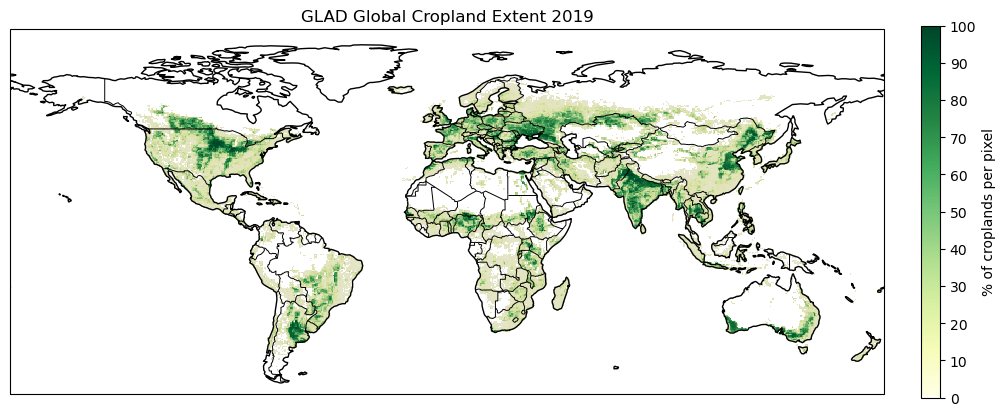

In [51]:
# Mask the crop area data to exclude negative values (oceans)
masked_total_cropland = total_cropland['Band1'].where(total_cropland['Band1'] >= 0)

# Define latitude and longitude bounds
lat_min, lat_max = -60, 90
lon_min, lon_max = -182, 180

# Subset the wheat dataset based on the defined bounds
subset_total_cropland = masked_total_cropland.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))

# Set up the plot with Cartopy projection
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())  # PlateCarree for lat/lon grid

cmap = plt.cm.YlGn
cmap = mcolors.ListedColormap(['white'] + [cmap(i) for i in range(1, cmap.N)])
# Create a mask for NaN values (non-crop areas)
nan_mask = subset_total_cropland.isnull()

# Plot the subset data with a colormap
plot = ax.pcolormesh(
    subset_total_cropland['lon'], subset_total_cropland['lat'], subset_total_cropland,
    cmap=cmap, shading='auto', vmin=0, vmax=100) 
    
# Overlay the NaN (non-crop) regions with a gray color
ax.pcolormesh(
    subset_total_cropland['lon'], subset_total_cropland['lat'], nan_mask,
    cmap='gray', shading='auto', alpha=0.1
)
# Add coastlines
ax.coastlines(resolution='110m', color='black', linewidth=1)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.7)

# Add colorbar, with aspect ratio set to match the height of the map
cbar = plt.colorbar(plot, ax=ax, label="% of croplands per pixel", fraction=0.02, pad=0.04)
cbar.set_ticks([0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])  # Set specific ticks if needed

# Set the title and labels
ax.set_title("GLAD Global Cropland Extent 2019")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# Add gridlines
ax.grid(visible=True, linestyle="--", linewidth=0.5, alpha=0.7)

# Show the plot
plt.show()

In [52]:
# Fractional cropland (0–100%) → convert to 0–1
cropland_fraction = total_cropland['Band1'].where(total_cropland['Band1'] > 0) / 100.0

# Convert degrees to radians for latitude
lat_rad = np.deg2rad(cropland_fraction['lat'])

# Earth's radius (km)
R = 6371

# Grid cell area (lat-dependent, same for all longitudes)
dlat = dlon = np.deg2rad(0.5)  # resolution in radians
grid_area_1d = (R**2) * dlat * dlon * np.cos(lat_rad)

# Expand to 2D to match shape of cropland_fraction
grid_area_2d = xr.DataArray(
    np.repeat(grid_area_1d.values[:, np.newaxis], len(cropland_fraction['lon']), axis=1),
    coords=[cropland_fraction['lat'], cropland_fraction['lon']],
    dims=['lat', 'lon']
)

# make grid area in hectares instead of km²
grid_area_2d_ha = grid_area_2d * 100

# Compute cropland area per cell and sum
total_cropland_km2 = (cropland_fraction * grid_area_2d).sum(skipna=True).item()

print(f"Total Cropland Area (km²): {total_cropland_km2:.2f}")

total_cropland_ha = (cropland_fraction * grid_area_2d_ha).sum(skipna=True).item()

print(f"Total Cropland Area: {total_cropland_ha:,.0f} ha")

Total Cropland Area (km²): 17102392.00
Total Cropland Area: 1,710,239,104 ha


In [53]:
cropland_area_ha = (cropland_fraction * grid_area_2d_ha)

In [ ]:
# Dictionary to store results
prob_el_nino_minus_neutral_hot_dry_area_ha = {}

# Seasons list
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

for season in seasons:
    prob_data = prob_el_nino_minus_neutral_hot_dry_seasons[season.upper()]
    sig_mask = significant_xarrays[season]

    # Condition: Positive anomaly AND significance AND cropland
    condition = (prob_data > 0) & (sig_mask == 1)

    # Area = sum over (fractional cropland * grid_area) for matching grid cells
    masked_cropland = total_cropland['Band1'].where(condition)/100
    seasonal_area_ha = (masked_cropland * grid_area_2d_ha).sum().item()

    # Store result
    prob_el_nino_minus_neutral_hot_dry_area_ha[season] = seasonal_area_ha

# Print results
for season, area in prob_el_nino_minus_neutral_hot_dry_area_ha.items():
    print(f"{season.upper()}: {area:.2f} ha of cropland with significant positive anomalies")

In [ ]:
# Dictionary to store results
prob_el_nino_minus_neutral_hot_dry_area_ha = {}

# Seasons list
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

for season in seasons:
    prob_data = prob_el_nino_minus_neutral_hot_dry_seasons[season.upper()]
    sig_mask = significant_xarrays[season]

    # Condition: Positive anomaly AND significance AND cropland
    condition = (prob_data < 0) & (sig_mask == 1)

    # Area = sum over (fractional cropland * grid_area) for matching grid cells
    masked_cropland = total_cropland['Band1'].where(condition)/100
    seasonal_area_ha = (masked_cropland * grid_area_2d_ha).sum().item()

    # Store result
    prob_el_nino_minus_neutral_hot_dry_area_ha[season] = seasonal_area_ha

# Print results
for season, area in prob_el_nino_minus_neutral_hot_dry_area_ha.items():
    print(f"{season.upper()}: {area:.2f} ha of cropland with significant negative anomalies")

In [ ]:
# Dictionary to store results
prob_la_nina_minus_neutral_hot_dry_area_ha = {}

# Seasons list
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

for season in seasons:
    prob_data = prob_la_nina_minus_neutral_hot_dry_seasons[season.upper()]
    sig_mask = significant_xarrays1[season]

    # Condition: Positive anomaly AND significance AND cropland
    condition = (prob_data > 0) & (sig_mask == 1)

    # Area = sum over (fractional cropland * grid_area) for matching grid cells
    masked_cropland = total_cropland['Band1'].where(condition)/100
    seasonal_area_ha = (masked_cropland * grid_area_2d_ha).sum().item()

    # Store result
    prob_la_nina_minus_neutral_hot_dry_area_ha[season] = seasonal_area_ha

# Print results
for season, area in prob_la_nina_minus_neutral_hot_dry_area_ha.items():
    print(f"{season.upper()}: {area:.2f} ha of cropland with significant positive anomalies")

In [ ]:
# Dictionary to store results
prob_la_nina_minus_neutral_hot_dry_area_ha = {}

# Seasons list
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

for season in seasons:
    prob_data = prob_la_nina_minus_neutral_hot_dry_seasons[season.upper()]
    sig_mask = significant_xarrays1[season]

    # Condition: Positive anomaly AND significance AND cropland
    condition = (prob_data < 0) & (sig_mask == 1)

    # Area = sum over (fractional cropland * grid_area) for matching grid cells
    masked_cropland = total_cropland['Band1'].where(condition)/100
    seasonal_area_ha = (masked_cropland * grid_area_2d_ha).sum().item()

    # Store result
    prob_la_nina_minus_neutral_hot_dry_area_ha[season] = seasonal_area_ha

# Print results
for season, area in prob_la_nina_minus_neutral_hot_dry_area_ha.items():
    print(f"{season.upper()}: {area:.2f} ha of cropland with significant negative anomalies")

In [ ]:
# params
n_bootstrap = 1000
alpha = 0.10
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
base_seed = 42  # used to build deterministic per-cell seeds

import zlib

def cell_rng(season: str, i: int, j: int, base_seed: int = 42):
    """Deterministic RNG per (season, i, j) using SeedSequence (robust across platforms)."""
    sh = zlib.crc32(season.encode("utf-8")) & 0xFFFFFFFF  # stable 32-bit
    ss = np.random.SeedSequence([int(base_seed), int(sh), int(i), int(j)])
    return np.random.default_rng(ss)

def bootstrap_p_value(series1, series2, n_bootstrap=1000, rng=None):
    """
    Vectorized pooled bootstrap (two-sided) on mean difference.
    Drops NaNs first; returns (p_value, observed_diff).
    """
    s1 = np.asarray(series1, dtype=float)
    s2 = np.asarray(series2, dtype=float)
    s1 = s1[np.isfinite(s1)]
    s2 = s2[np.isfinite(s2)]
    if s1.size == 0 or s2.size == 0:
        return np.nan, np.nan

    observed = s1.mean() - s2.mean()
    pooled = np.concatenate([s1, s2])
    na, nb = s1.size, s2.size

    if rng is None:
        rng = np.random.default_rng()

    # Draw all resamples at once via indices; compute diffs vectorized
    idx1 = rng.integers(0, pooled.size, size=(n_bootstrap, na))
    idx2 = rng.integers(0, pooled.size, size=(n_bootstrap, nb))
    diffs = pooled[idx1].mean(axis=1) - pooled[idx2].mean(axis=1)

    p_val = np.mean(np.abs(diffs) >= abs(observed))
    return p_val, observed

# Storage
significant_xarrays = {}
pval_xarrays = {}
diff_xarrays = {}

# Process all seasons
total_t0 = time.time()
print(f"Run start: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(total_t0))}")

for season in seasons:
    print(f"\nProcessing season: {season}")
    t0 = time.time()

    el_data = hot_dry_counts['el'][season]
    ne_data = hot_dry_counts['ne'][season]

    lat_vals = el_data.lat.values
    lon_vals = ne_data.lon.values

    # Prepare 3D blocks for fast slicing
    if "year" in el_data.dims:
        # expected shape: (time, lat, lon)
        el_block = el_data.values
        ne_block = ne_data.values
        # valid where both phases have any finite value over time
        el_any = np.isfinite(el_block).any(axis=0)
        ne_any = np.isfinite(ne_block).any(axis=0)
        valid = el_any & ne_any
    else:
        # 2D case (lat, lon)
        el_block = el_data.values
        ne_block = ne_data.values
        valid = np.isfinite(el_block) & np.isfinite(ne_block)

    significant_grid = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)
    pval_grid = np.full((len(lat_vals), len(lon_vals)), np.nan, dtype=float)
    diff_grid  = np.full((len(lat_vals), len(lon_vals)), np.nan, dtype=float)

    # Iterate only over valid cells
    for i, j in np.argwhere(valid):
        if "year" in el_data.dims:
            el_series = el_block[:, i, j]
            ne_series = ne_block[:, i, j]
        else:
            el_series = np.atleast_1d(el_block[i, j])
            ne_series = np.atleast_1d(ne_block[i, j])

        # Per-cell deterministic RNG (stable & parallel-safe)
        rng_cell = cell_rng(season, i, j, base_seed=base_seed)
        p_val, observed_diff = bootstrap_p_value(el_series, ne_series, n_bootstrap=n_bootstrap, rng=rng_cell)

        pval_grid[i, j] = p_val
        diff_grid[i, j] = observed_diff
        if np.isfinite(p_val) and p_val < alpha:
            significant_grid[i, j] = True

    # Wrap into xarray
    significant_xarrays[season] = xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])
    pval_xarrays[season] = xr.DataArray(pval_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])
    diff_xarrays[season] = xr.DataArray(diff_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])

    t1 = time.time()
    print(f"Season end: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t1))}")
    print(f"Elapsed (season {season}): {t1 - t0:.2f} s | significant count: {(significant_grid>0).sum()}")

total_t1 = time.time()
print(f"\nRun end: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(total_t1))}")
print(f"Total elapsed: {total_t1 - total_t0:.2f} s")

# Example quick check
print("\nExample: Raw p-values for 'jja'")
print(pval_xarrays['jja'])

In [ ]:
# params
n_bootstrap = 1000
alpha = 0.10
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
base_seed = 42  # used to build deterministic per-cell seeds

import zlib

def cell_rng(season: str, i: int, j: int, base_seed: int = 42):
    """Deterministic RNG per (season, i, j) using SeedSequence (robust across platforms)."""
    sh = zlib.crc32(season.encode("utf-8")) & 0xFFFFFFFF  # stable 32-bit
    ss = np.random.SeedSequence([int(base_seed), int(sh), int(i), int(j)])
    return np.random.default_rng(ss)

def bootstrap_p_value(series1, series2, n_bootstrap=1000, rng=None):
    """
    Vectorized pooled bootstrap (two-sided) on mean difference.
    Drops NaNs first; returns (p_value, observed_diff).
    """
    s1 = np.asarray(series1, dtype=float)
    s2 = np.asarray(series2, dtype=float)
    s1 = s1[np.isfinite(s1)]
    s2 = s2[np.isfinite(s2)]
    if s1.size == 0 or s2.size == 0:
        return np.nan, np.nan

    observed = s1.mean() - s2.mean()
    pooled = np.concatenate([s1, s2])
    na, nb = s1.size, s2.size

    if rng is None:
        rng = np.random.default_rng()

    # Draw all resamples at once via indices; compute diffs vectorized
    idx1 = rng.integers(0, pooled.size, size=(n_bootstrap, na))
    idx2 = rng.integers(0, pooled.size, size=(n_bootstrap, nb))
    diffs = pooled[idx1].mean(axis=1) - pooled[idx2].mean(axis=1)

    p_val = np.mean(np.abs(diffs) >= abs(observed))
    return p_val, observed

# Storage
significant_xarrays1 = {}
pval_xarrays1 = {}
diff_xarrays1 = {}

# Process all seasons
total_t0 = time.time()
print(f"Run start: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(total_t0))}")

for season in seasons:
    print(f"\nProcessing season: {season}")
    t0 = time.time()

    la_data = hot_dry_counts['la'][season]
    ne_data = hot_dry_counts['ne'][season]

    lat_vals = la_data.lat.values
    lon_vals = ne_data.lon.values

    # Prepare 3D blocks for fast slicing
    if "year" in la_data.dims:
        # expected shape: (time, lat, lon)
        la_block = la_data.values
        ne_block = ne_data.values
        # valid where both phases have any finite value over time
        la_any = np.isfinite(la_block).any(axis=0)
        ne_any = np.isfinite(ne_block).any(axis=0)
        valid = la_any & ne_any
    else:
        # 2D case (lat, lon)
        la_block = la_data.values
        ne_block = ne_data.values
        valid = np.isfinite(la_block) & np.isfinite(ne_block)

    significant_grid = np.zeros((len(lat_vals), len(lon_vals)), dtype=bool)
    pval_grid = np.full((len(lat_vals), len(lon_vals)), np.nan, dtype=float)
    diff_grid  = np.full((len(lat_vals), len(lon_vals)), np.nan, dtype=float)

    # Iterate only over valid cells
    for i, j in np.argwhere(valid):
        if "year" in la_data.dims:
            la_series = la_block[:, i, j]
            ne_series = ne_block[:, i, j]
        else:
            la_series = np.atleast_1d(la_block[i, j])
            ne_series = np.atleast_1d(ne_block[i, j])

        # Per-cell deterministic RNG (stable & parallel-safe)
        rng_cell = cell_rng(season, i, j, base_seed=base_seed)
        p_val, observed_diff = bootstrap_p_value(la_series, ne_series, n_bootstrap=n_bootstrap, rng=rng_cell)

        pval_grid[i, j] = p_val
        diff_grid[i, j] = observed_diff
        if np.isfinite(p_val) and p_val < alpha:
            significant_grid[i, j] = True

    # Wrap into xarray
    significant_xarrays1[season] = xr.DataArray(significant_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])
    pval_xarrays1[season] = xr.DataArray(pval_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])
    diff_xarrays1[season] = xr.DataArray(diff_grid, coords=[lat_vals, lon_vals], dims=["lat", "lon"])

    t1 = time.time()
    print(f"Season end: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t1))}")
    print(f"Elapsed (season {season}): {t1 - t0:.2f} s | significant count: {(significant_grid>0).sum()}")

total_t1 = time.time()
print(f"\nRun end: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(total_t1))}")
print(f"Total elapsed: {total_t1 - total_t0:.2f} s")

# Example quick check
print("\nExample: Raw p-values for 'jja'")
print(pval_xarrays1['jja'])

In [ ]:
# # Define bootstrap parameters
# n_bootstrap = 1000
# alpha = 0.1  # Significance threshold

# # Define seasons
# seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# # Dictionaries to store results
# significant_xarrays = {}
# pval_xarrays = {}
# diff_xarrays = {}

# # Bootstrap function
# def bootstrap_p_value(series1, series2, n_bootstrap):
#     series1 = np.atleast_1d(series1)
#     series2 = np.atleast_1d(series2)

#     if series1.size == 0 or series2.size == 0:
#         return 1.0  # Not enough data → high p-value

#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []

#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))

#     p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
#     return p_value, observed_diff

# # Loop over seasons
# for season in seasons:
#     print(f"Processing season: {season}")

#     # Extract datasets
#     el_data = hot_dry_counts['el'][season]
#     ne_data = hot_dry_counts['ne'][season]

#     # Grid info
#     lat_vals = el_data.lat.values
#     lon_vals = el_data.lon.values

#     # Initialize output arrays
#     significant_grid = np.full((len(lat_vals), len(lon_vals)), False)
#     pval_grid = np.full((len(lat_vals), len(lon_vals)), np.nan)
#     diff_grid = np.full((len(lat_vals), len(lon_vals)), np.nan)  # <--- NEW

#     # Start timing
#     start_time = time.time()
#     print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):

#             # Extract series by position
#             if "year" in el_data.dims:
#                 el_series = el_data[:, i, j].values
#                 ne_series = ne_data[:, i, j].values
#             else:
#                 el_series = np.atleast_1d(el_data[i, j].values)
#                 ne_series = np.atleast_1d(ne_data[i, j].values)

#             if np.isnan(el_series).all() or np.isnan(ne_series).all():
#                 continue

#             # Compute bootstrap p-value
#             p_val, observed_diff = bootstrap_p_value(el_series, ne_series, n_bootstrap)

#             # Store raw p-value
#             pval_grid[i, j] = p_val
#             diff_grid[i, j] = observed_diff  # <--- NEW

#             # Store significance mask
#             if p_val < alpha:
#                 significant_grid[i, j] = True

#     # Save results for the season
#     significant_xarrays[season] = xr.DataArray(
#         significant_grid,
#         coords=[lat_vals, lon_vals],
#         dims=["lat", "lon"]
#     )

#     pval_xarrays[season] = xr.DataArray(
#         pval_grid,
#         coords=[lat_vals, lon_vals],
#         dims=["lat", "lon"]
#     )
    
#     diff_xarrays[season] = xr.DataArray(
#     diff_grid,
#     coords=[lat_vals, lon_vals],
#     dims=["lat", "lon"]
#     )

#     # Timing info
#     end_time = time.time()
#     print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
#     print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # Optional: check one season’s raw p-values
# print("\nExample: Raw p-values for 'jja'")
# print(pval_xarrays['jja'])

In [ ]:
# # Define bootstrap parameters
# n_bootstrap = 1000
# alpha = 0.1  # Significance threshold

# # Define seasons
# seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# # Dictionaries to store results
# significant_xarrays1 = {}
# pval_xarrays1 = {}
# diff_xarrays1 = {}

# # Bootstrap function
# def bootstrap_p_value(series1, series2, n_bootstrap):
#     series1 = np.atleast_1d(series1)
#     series2 = np.atleast_1d(series2)

#     if series1.size == 0 or series2.size == 0:
#         return 1.0  # Not enough data → high p-value

#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []

#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))

#     p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))
#     return p_value, observed_diff

# # Loop over seasons
# for season in seasons:
#     print(f"Processing season: {season}")

#     # Extract datasets
#     la_data = hot_dry_counts['la'][season]
#     ne_data = hot_dry_counts['ne'][season]

#     # Grid info
#     lat_vals = la_data.lat.values
#     lon_vals = la_data.lon.values

#     # Initialize output arrays
#     significant_grid = np.full((len(lat_vals), len(lon_vals)), False)
#     pval_grid = np.full((len(lat_vals), len(lon_vals)), np.nan)
#     diff_grid = np.full((len(lat_vals), len(lon_vals)), np.nan)  # <--- NEW

#     # Start timing
#     start_time = time.time()
#     print(f"Start Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(start_time))}")

#     for i in range(len(lat_vals)):
#         for j in range(len(lon_vals)):

#             # Extract series by position
#             if "year" in la_data.dims:
#                 la_series = la_data[:, i, j].values
#                 ne_series = ne_data[:, i, j].values
#             else:
#                 la_series = np.atleast_1d(la_data[i, j].values)
#                 ne_series = np.atleast_1d(ne_data[i, j].values)

#             if np.isnan(la_series).all() or np.isnan(ne_series).all():
#                 continue

#             # Compute bootstrap p-value
#             p_val, observed_diff = bootstrap_p_value(la_series, ne_series, n_bootstrap)

#             # Store raw p-value
#             pval_grid[i, j] = p_val
#             diff_grid[i, j] = observed_diff  # <--- NEW

#             # Store significance mask
#             if p_val < alpha:
#                 significant_grid[i, j] = True

#     # Save results for the season
#     significant_xarrays1[season] = xr.DataArray(
#         significant_grid,
#         coords=[lat_vals, lon_vals],
#         dims=["lat", "lon"]
#     )

#     pval_xarrays1[season] = xr.DataArray(
#         pval_grid,
#         coords=[lat_vals, lon_vals],
#         dims=["lat", "lon"]
#     )
    
#     diff_xarrays1[season] = xr.DataArray(
#     diff_grid,
#     coords=[lat_vals, lon_vals],
#     dims=["lat", "lon"]
#     )

#     # Timing info
#     end_time = time.time()
#     print(f"End Time: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(end_time))}")
#     print(f"Total Execution Time: {end_time - start_time:.2f} seconds")

# # Optional: check one season’s raw p-values
# print("\nExample: Raw p-values for 'jja'")
# print(pval_xarrays1['jja'])

In [ ]:
# # Constants
# alpha = 0.1
# n_resamples = 1000
# season = "jja"

# # Step 1: Observed significance counts
# obs_diff = diff_xarrays[season]
# obs_pval = pval_xarrays[season]

# obs_increase = ((obs_diff > 0) & (obs_pval < alpha)).sum().item()
# obs_decrease = ((obs_diff < 0) & (obs_pval < alpha)).sum().item()

# # Step 2: Prepare El Niño and Neutral data
# el = hot_dry_counts["el"][season]
# ne = hot_dry_counts["ne"][season]

# n_el = el.sizes["year"]
# n_ne = ne.sizes["year"]

# # Reassign unique dummy labels to avoid alignment conflict
# el = el.assign_coords(year=np.arange(n_el))
# ne = ne.assign_coords(year=np.arange(n_el, n_el + n_ne))
# combined = xr.concat([el, ne], dim="year")

# # Bootstrap function
# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     series1 = np.ravel(series1)
#     series2 = np.ravel(series2)

#     if series1.size == 0 or series2.size == 0:
#         return 1.0

#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []

#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))

#     return np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

# # Step 3: Resample
# resampled_increase = []
# resampled_decrease = []

# # Convert cropland mask to boolean mask
# cropland_mask_bool = cropland_mask.values
# # Get shape of grid
# lat_dim, lon_dim = cropland_mask_bool.shape

# for _ in range(n_resamples):
#     start = time.time()
#     perm = np.random.permutation(n_el + n_ne)
#     s1 = combined.isel(year=perm[:n_el])
#     s2 = combined.isel(year=perm[n_el:])

#     inc_count = 0
#     dec_count = 0

#     for i in range(lat_dim):
#         for j in range(lon_dim):
#             if not cropland_mask_bool[i, j]:
#                 continue

#             series1 = s1[:, i, j].values
#             series2 = s2[:, i, j].values

#             if np.isnan(series1).all() or np.isnan(series2).all():
#                 continue

#             pval = bootstrap_p_value(series1, series2, n_bootstrap=1000)
#             diff = np.nanmean(series1) - np.nanmean(series2)

#             if pval < alpha and diff > 0:
#                 inc_count += 1
#             elif pval < alpha and diff < 0:
#                 dec_count += 1
#             end = time.time()
            
#     resampled_increase.append(inc_count)
#     resampled_decrease.append(dec_count)

In [ ]:
# # Step 4: Plot
# sns.set(style="whitegrid")
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# # Boxplot for increases
# sns.boxplot(data=resampled_increase, ax=axes[0])
# axes[0].set_title("JJA –   Significant Increases")
# axes[0].set_ylabel("Significant Grid Cell Count")
# axes[0].plot(0, obs_increase, marker='*', color='orange', markersize=12)

# # Boxplot for decreases
# sns.boxplot(data=resampled_decrease, ax=axes[1])
# axes[1].set_title("JJA – Significant Decreases")
# axes[1].plot(0, obs_decrease, marker='*', color='orange', markersize=12)

# plt.suptitle("Field Significance Test – El Niño vs Neutral (JJA)", fontsize=16)
# plt.tight_layout()
# plt.show()

In [ ]:
# ---------- Params ----------
alpha = 0.10
n_resamples = 1000            # permutations
n_bootstrap_cell = 1000       # bootstrap draws per cell to get q_boot
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
rng = np.random.default_rng(42)

# ---------- Helpers ----------
def nanmean_no_warn(a, axis):
    cnt = np.isfinite(a).sum(axis=axis)
    tot = np.nansum(a, axis=axis)
    out = np.full_like(tot, np.nan, dtype=float)
    np.divide(tot, cnt, out=out, where=cnt > 0)
    return out

def _ensure_3d_year_lat_lon(da: xr.DataArray) -> xr.DataArray:
    if 'year' not in da.dims:
        da = da.expand_dims({'year': [0]})
    return da.transpose('year', 'lat', 'lon')

def _align_mask(mask, lat, lon):
    if isinstance(mask, xr.DataArray):
        mask_da = mask.reindex(lat=lat, lon=lon, method=None)
        return np.asarray(mask_da.fillna(False).values, dtype=bool)
    return np.asarray(mask, dtype=bool)

# ---------- Step 1: observed significant increases/decreases ----------
observed_increase = {}
observed_decrease = {}

for season in seasons:
    diff = diff_xarrays[season]     # xr.DataArray (lat, lon)
    pval = pval_xarrays[season]     # xr.DataArray (lat, lon)
    mask = _align_mask(cropland_mask, diff.lat.values, diff.lon.values)

    inc = ((diff > 0) & (pval < alpha) & mask).sum().item()
    dec = ((diff < 0) & (pval < alpha) & mask).sum().item()
    observed_increase[season] = inc
    observed_decrease[season] = dec

# ---------- Step 2 (HYBRID): field null using q_boot + streamed perms ----------
resample_increase = {s: [] for s in seasons}
resample_decrease = {s: [] for s in seasons}

perms_cache = {}  # reuse permutations for identical (n_el, n_ne)

t0_all = time.time()
print(f"Run start: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t0_all))}")

for season in seasons:
    print(f"\nSeason: {season}")
    t0 = time.time()

    # Data
    el_da = _ensure_3d_year_lat_lon(hot_dry_counts['el'][season])
    ne_da = _ensure_3d_year_lat_lon(hot_dry_counts['ne'][season])
    lat_vals = el_da.lat.values
    lon_vals = el_da.lon.values

    # Valid mask (cropland & has any finite data)
    mask = _align_mask(cropland_mask, lat_vals, lon_vals)
    el_vals = el_da.values.astype(np.float32, copy=False)  # (n_el, lat, lon)
    ne_vals = ne_da.values.astype(np.float32, copy=False)  # (n_ne, lat, lon)
    valid_data = np.isfinite(el_vals).any(axis=0) & np.isfinite(ne_vals).any(axis=0)
    valid = mask & valid_data
    if not valid.any():
        print("No valid cells; skipping.")
        continue

    # Stack time & sizes
    n_el = el_vals.shape[0]
    n_ne = ne_vals.shape[0]
    T = n_el + n_ne
    combined = np.concatenate([el_vals, ne_vals], axis=0)  # (T, lat, lon)

    # ---- Precompute per-cell bootstrap thresholds q_boot (1 - alpha) ----
    boot_idx1 = rng.integers(0, T, size=(n_bootstrap_cell, n_el))
    boot_idx2 = rng.integers(0, T, size=(n_bootstrap_cell, n_ne))
    q_boot = np.full(valid.shape, np.nan, dtype=np.float32)

    ii, jj = np.where(valid)
    for i, j in zip(ii, jj):
        s1_means = combined[boot_idx1, i, j].mean(axis=1)
        s2_means = combined[boot_idx2, i, j].mean(axis=1)
        abs_diffs = np.abs(s1_means - s2_means)
        q_boot[i, j] = np.quantile(abs_diffs, 1.0 - alpha)

    # ---- Stream permutations; compare |diff_map| to q_boot (no inner bootstrap) ----
    key = (int(n_el), int(n_ne))
    if key not in perms_cache:
        perms_cache[key] = np.array([rng.permutation(T) for _ in range(n_resamples)], dtype=np.int32)
    perms = perms_cache[key]

    for r in range(n_resamples):
        idx = perms[r]
        g1 = combined[idx[:n_el], :, :]
        g2 = combined[idx[n_el:], :, :]
        diff_map = nanmean_no_warn(g1, axis=0) - nanmean_no_warn(g2, axis=0)

        inc = ((diff_map >  q_boot) & valid).sum()
        dec = ((diff_map < -q_boot) & valid).sum()
        resample_increase[season].append(int(inc))
        resample_decrease[season].append(int(dec))

    t1 = time.time()
    print(f"Elapsed: {t1 - t0:.2f}s | valid cells: {valid.sum()} | "
          f"obs_inc: {observed_increase[season]} | obs_dec: {observed_decrease[season]}")

# ---------- Empirical field-level p-values ----------
for season in seasons:
    inc_null = np.asarray(resample_increase[season])
    dec_null = np.asarray(resample_decrease[season])
    if inc_null.size:
        p_inc = (np.sum(inc_null >= observed_increase[season]) + 1) / (n_resamples + 1)
        p_dec = (np.sum(dec_null >= observed_decrease[season]) + 1) / (n_resamples + 1)
        print(f"{season}: field p_inc={p_inc:.3f}, p_dec={p_dec:.3f}")

t1_all = time.time()
print(f"\nRun end: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t1_all))}")
print(f"Total elapsed: {t1_all - t0_all:.2f}s")

In [ ]:
# # Constants
# alpha = 0.1
# n_resamples = 1000
# seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# # Step 1: Get observed significant increases and decreases (masked for cropland)
# observed_increase = {}
# observed_decrease = {}

# for season in seasons:
#     diff = diff_xarrays[season]
#     pval = pval_xarrays[season]
    
#     inc = ((diff > 0) & (pval < alpha) & cropland_mask).sum().item()
#     dec = ((diff < 0) & (pval < alpha) & cropland_mask).sum().item()
    
#     observed_increase[season] = inc
#     observed_decrease[season] = dec

# # Step 2: Resample
# resample_increase = {s: [] for s in seasons}
# resample_decrease = {s: [] for s in seasons}

# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     series1 = np.ravel(series1)
#     series2 = np.ravel(series2)
#     if series1.size == 0 or series2.size == 0:
#         return 1.0
#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []
#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)
#         s1 = np.random.choice(combined, size=len(series1), replace=True)
#         s2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(s1) - np.nanmean(s2))
#     return np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

# for season in seasons:
#     el = hot_dry_counts["el"][season]
#     ne = hot_dry_counts["ne"][season]
#     n_el, n_ne = el.sizes["year"], ne.sizes["year"]

#     el = el.assign_coords(year=np.arange(n_el))
#     ne = ne.assign_coords(year=np.arange(n_el, n_el + n_ne))
#     combined = xr.concat([el, ne], dim="year")
#     lat_dim, lon_dim = cropland_mask.shape

#     for _ in range(n_resamples):
#         perm = np.random.permutation(n_el + n_ne)
#         s1 = combined.isel(year=perm[:n_el])
#         s2 = combined.isel(year=perm[n_el:])
        
#         inc_count = 0
#         dec_count = 0

#         for i in range(lat_dim):
#             for j in range(lon_dim):
#                 if not cropland_mask.values[i, j]:
#                     continue
#                 series1 = s1[:, i, j].values
#                 series2 = s2[:, i, j].values
#                 if np.isnan(series1).all() or np.isnan(series2).all():
#                     continue
#                 pval = bootstrap_p_value(series1, series2, n_bootstrap=1000)
#                 diff = np.nanmean(series1) - np.nanmean(series2)
#                 if pval < alpha and diff > 0:
#                     inc_count += 1
#                 elif pval < alpha and diff < 0:
#                     dec_count += 1

#         resample_increase[season].append(inc_count)
#         resample_decrease[season].append(dec_count)

In [ ]:
# Define once and reuse
flierprops = dict(
    marker="o",            # e.g., 'o', 'D', 's', '^', 'x', '*'
    markersize=3,          # size of outlier markers
    markerfacecolor="none",
    markeredgecolor="0.3",
    markeredgewidth=0.8,
    alpha=0.9,
)

# Step 3: Plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# Boxplot for increases
sns.boxplot(data=[resample_increase[s] for s in seasons], whis=(10, 90), ax=axes[0], flierprops=flierprops, fliersize=2)
axes[0].set_title("Significant Increases", fontsize=15)
axes[0].set_ylabel("Significant Grid Cell Count", fontsize=15)
axes[0].set_xticklabels(custom_labels, fontsize=15)
for i, s in enumerate(seasons):
    axes[0].plot(i, observed_increase[s], marker='*', color='orange', markersize=12)

# Boxplot for decreases
sns.boxplot(data=[resample_decrease[s] for s in seasons], whis=(10, 90), ax=axes[1], flierprops=flierprops, fliersize=2)
axes[1].set_title("Significant Decreases", fontsize=15)
axes[1].set_xticklabels(custom_labels, fontsize=15)
for i, s in enumerate(seasons):
    axes[1].plot(i, observed_decrease[s], marker='*', color='orange', markersize=12)

# Shared y-axis label
fig.text(-0.01, 0.5, "El Niño vs Neutral", va='center', rotation='vertical', fontsize=16)

# Title
plt.suptitle("Field Significance of HD event frequency", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
# ---------- Params ----------
alpha = 0.10
n_resamples = 1000            # permutations
n_bootstrap_cell = 1000       # bootstrap draws per cell to get q_boot
seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']
rng = np.random.default_rng(42)

# ---------- Helpers ----------
def nanmean_no_warn(a, axis):
    cnt = np.isfinite(a).sum(axis=axis)
    tot = np.nansum(a, axis=axis)
    out = np.full_like(tot, np.nan, dtype=float)
    np.divide(tot, cnt, out=out, where=cnt > 0)
    return out

def _ensure_3d_year_lat_lon(da: xr.DataArray) -> xr.DataArray:
    if 'year' not in da.dims:
        da = da.expand_dims({'year': [0]})
    return da.transpose('year', 'lat', 'lon')

def _align_mask(mask, lat, lon):
    if isinstance(mask, xr.DataArray):
        mask_da = mask.reindex(lat=lat, lon=lon, method=None)
        return np.asarray(mask_da.fillna(False).values, dtype=bool)
    return np.asarray(mask, dtype=bool)

# ---------- Step 1: observed significant increases/decreases ----------
observed_increase1 = {}
observed_decrease1 = {}

for season in seasons:
    diff = diff_xarrays1[season]     # xr.DataArray (lat, lon)
    pval = pval_xarrays1[season]     # xr.DataArray (lat, lon)
    mask = _align_mask(cropland_mask, diff.lat.values, diff.lon.values)

    inc = ((diff > 0) & (pval < alpha) & mask).sum().item()
    dec = ((diff < 0) & (pval < alpha) & mask).sum().item()
    observed_increase1[season] = inc
    observed_decrease1[season] = dec

# ---------- Step 2 (HYBRID): field null using q_boot + streamed perms ----------
resample_increase1 = {s: [] for s in seasons}
resample_decrease1 = {s: [] for s in seasons}

perms_cache = {}  # reuse permutations for identical (n_el, n_ne)

t0_all = time.time()
print(f"Run start: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t0_all))}")

for season in seasons:
    print(f"\nSeason: {season}")
    t0 = time.time()

    # Data
    la_da = _ensure_3d_year_lat_lon(hot_dry_counts['la'][season])
    ne_da = _ensure_3d_year_lat_lon(hot_dry_counts['ne'][season])
    lat_vals = la_da.lat.values
    lon_vals = la_da.lon.values

    # Valid mask (cropland & has any finite data)
    mask = _align_mask(cropland_mask, lat_vals, lon_vals)
    la_vals = la_da.values.astype(np.float32, copy=False)  # (n_el, lat, lon)
    ne_vals = ne_da.values.astype(np.float32, copy=False)  # (n_ne, lat, lon)
    valid_data = np.isfinite(la_vals).any(axis=0) & np.isfinite(ne_vals).any(axis=0)
    valid = mask & valid_data
    if not valid.any():
        print("No valid cells; skipping.")
        continue

    # Stack time & sizes
    n_la = la_vals.shape[0]
    n_ne = ne_vals.shape[0]
    T = n_la + n_ne
    combined = np.concatenate([la_vals, ne_vals], axis=0)  # (T, lat, lon)

    # ---- Precompute per-cell bootstrap thresholds q_boot (1 - alpha) ----
    boot_idx1 = rng.integers(0, T, size=(n_bootstrap_cell, n_la))
    boot_idx2 = rng.integers(0, T, size=(n_bootstrap_cell, n_ne))
    q_boot = np.full(valid.shape, np.nan, dtype=np.float32)

    ii, jj = np.where(valid)
    for i, j in zip(ii, jj):
        s1_means = combined[boot_idx1, i, j].mean(axis=1)
        s2_means = combined[boot_idx2, i, j].mean(axis=1)
        abs_diffs = np.abs(s1_means - s2_means)
        q_boot[i, j] = np.quantile(abs_diffs, 1.0 - alpha)

    # ---- Stream permutations; compare |diff_map| to q_boot (no inner bootstrap) ----
    key = (int(n_la), int(n_ne))
    if key not in perms_cache:
        perms_cache[key] = np.array([rng.permutation(T) for _ in range(n_resamples)], dtype=np.int32)
    perms = perms_cache[key]

    for r in range(n_resamples):
        idx = perms[r]
        g1 = combined[idx[:n_la], :, :]
        g2 = combined[idx[n_la:], :, :]
        diff_map = nanmean_no_warn(g1, axis=0) - nanmean_no_warn(g2, axis=0)

        inc = ((diff_map >  q_boot) & valid).sum()
        dec = ((diff_map < -q_boot) & valid).sum()
        resample_increase1[season].append(int(inc))
        resample_decrease1[season].append(int(dec))

    t1 = time.time()
    print(f"Elapsed: {t1 - t0:.2f}s | valid cells: {valid.sum()} | "
          f"obs_inc: {observed_increase1[season]} | obs_dec: {observed_decrease1[season]}")

# ---------- Empirical field-level p-values ----------
for season in seasons:
    inc_null = np.asarray(resample_increase1[season])
    dec_null = np.asarray(resample_decrease1[season])
    if inc_null.size:
        p_inc = (np.sum(inc_null >= observed_increase1[season]) + 1) / (n_resamples + 1)
        p_dec = (np.sum(dec_null >= observed_decrease1[season]) + 1) / (n_resamples + 1)
        print(f"{season}: field p_inc={p_inc:.3f}, p_dec={p_dec:.3f}")

t1_all = time.time()
print(f"\nRun end: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t1_all))}")
print(f"Total elapsed: {t1_all - t0_all:.2f}s")

In [ ]:
# # Constants
# alpha = 0.1
# n_resamples = 1000
# season = "jja"

# # Step 1: Observed significance counts
# obs_diff = diff_xarrays1[season]
# obs_pval = pval_xarrays1[season]

# obs_increase = ((obs_diff > 0) & (obs_pval < alpha)).sum().item()
# obs_decrease = ((obs_diff < 0) & (obs_pval < alpha)).sum().item()

# # Step 2: Prepare El Niño and Neutral data
# la = hot_dry_counts["la"][season]
# ne = hot_dry_counts["ne"][season]

# n_la = la.sizes["year"]
# n_ne = ne.sizes["year"]

# # Reassign unique dummy labels to avoid alignment conflict
# la = la.assign_coords(year=np.arange(n_la))
# ne = ne.assign_coords(year=np.arange(n_la, n_la + n_ne))
# combined = xr.concat([la, ne], dim="year")

# # Bootstrap function
# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     series1 = np.ravel(series1)
#     series2 = np.ravel(series2)

#     if series1.size == 0 or series2.size == 0:
#         return 1.0

#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []

#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)
#         sample1 = np.random.choice(combined, size=len(series1), replace=True)
#         sample2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(sample1) - np.nanmean(sample2))

#     return np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

# # Step 3: Resample
# resampled_increase1 = []
# resampled_decrease1 = []

# # Convert cropland mask to boolean mask
# cropland_mask_bool = cropland_mask.values
# # Get shape of grid
# lat_dim, lon_dim = cropland_mask_bool.shape

# for _ in range(n_resamples):
#     start = time.time()
#     perm = np.random.permutation(n_la + n_ne)
#     s1 = combined.isel(year=perm[:n_la])
#     s2 = combined.isel(year=perm[n_la:])

#     inc_count = 0
#     dec_count = 0

#     for i in range(lat_dim):
#         for j in range(lon_dim):
#             if not cropland_mask_bool[i, j]:
#                 continue

#             series1 = s1[:, i, j].values
#             series2 = s2[:, i, j].values

#             if np.isnan(series1).all() or np.isnan(series2).all():
#                 continue

#             pval = bootstrap_p_value(series1, series2, n_bootstrap=1000)
#             diff = np.nanmean(series1) - np.nanmean(series2)

#             if pval < alpha and diff > 0:
#                 inc_count += 1
#             elif pval < alpha and diff < 0:
#                 dec_count += 1
#             end = time.time()
            
#     resampled_increase1.append(inc_count)
#     resampled_decrease1.append(dec_count)

In [ ]:
# # Step 4: Plot
# sns.set(style="whitegrid")
# fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

# # Boxplot for increases
# sns.boxplot(data=resampled_increase1, ax=axes[0])
# axes[0].set_title("JJA – Significant Increases")
# axes[0].set_ylabel("Significant Grid Cell Count")
# axes[0].plot(0, obs_increase, marker='*', color='orange', markersize=12)

# # Boxplot for decreases
# sns.boxplot(data=resampled_decrease1, ax=axes[1])
# axes[1].set_title("JJA – Significant Decreases")
# axes[1].plot(0, obs_decrease, marker='*', color='orange', markersize=12)

# plt.suptitle("Field Significance Test – La Niña vs Neutral (JJA)", fontsize=16)
# plt.tight_layout()
# plt.show()

In [ ]:
# # Constants
# alpha = 0.1
# n_resamples = 1000
# seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# # Step 1: Get observed significant increases and decreases (masked for cropland)
# observed_increase1 = {}
# observed_decrease1 = {}

# for season in seasons:
#     diff = diff_xarrays1[season]
#     pval = pval_xarrays1[season]
    
#     inc = ((diff > 0) & (pval < alpha) & cropland_mask).sum().item()
#     dec = ((diff < 0) & (pval < alpha) & cropland_mask).sum().item()
    
#     observed_increase1[season] = inc
#     observed_decrease1[season] = dec

# # Step 2: Resample
# resample_increase1 = {s: [] for s in seasons}
# resample_decrease1 = {s: [] for s in seasons}

# def bootstrap_p_value(series1, series2, n_bootstrap=1000):
#     series1 = np.ravel(series1)
#     series2 = np.ravel(series2)
#     if series1.size == 0 or series2.size == 0:
#         return 1.0
#     observed_diff = np.nanmean(series1) - np.nanmean(series2)
#     combined = np.concatenate([series1, series2])
#     bootstrap_diffs = []
#     for _ in range(n_bootstrap):
#         np.random.shuffle(combined)
#         s1 = np.random.choice(combined, size=len(series1), replace=True)
#         s2 = np.random.choice(combined, size=len(series2), replace=True)
#         bootstrap_diffs.append(np.nanmean(s1) - np.nanmean(s2))
#     return np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

# for season in seasons:
#     la = hot_dry_counts["la"][season]
#     ne = hot_dry_counts["ne"][season]
#     n_la, n_ne = la.sizes["year"], ne.sizes["year"]

#     la = la.assign_coords(year=np.arange(n_la))
#     ne = ne.assign_coords(year=np.arange(n_la, n_la + n_ne))
#     combined = xr.concat([la, ne], dim="year")
#     lat_dim, lon_dim = cropland_mask.shape

#     for _ in range(n_resamples):
#         perm = np.random.permutation(n_la + n_ne)
#         s1 = combined.isel(year=perm[:n_la])
#         s2 = combined.isel(year=perm[n_la:])
        
#         inc_count = 0
#         dec_count = 0

#         for i in range(lat_dim):
#             for j in range(lon_dim):
#                 if not cropland_mask.values[i, j]:
#                     continue
#                 series1 = s1[:, i, j].values
#                 series2 = s2[:, i, j].values
#                 if np.isnan(series1).all() or np.isnan(series2).all():
#                     continue
#                 pval = bootstrap_p_value(series1, series2, n_bootstrap=1000)
#                 diff = np.nanmean(series1) - np.nanmean(series2)
#                 if pval < alpha and diff > 0:
#                     inc_count += 1
#                 elif pval < alpha and diff < 0:
#                     dec_count += 1

#         resample_increase1[season].append(inc_count)
#         resample_decrease1[season].append(dec_count)

In [ ]:
# Define once and reuse
flierprops = dict(
    marker="o",            # e.g., 'o', 'D', 's', '^', 'x', '*'
    markersize=3,          # size of outlier markers
    markerfacecolor="none",
    markeredgecolor="0.3",
    markeredgewidth=0.8,
    alpha=0.9,
)

# Step 3: Plot
sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
custom_labels = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# Boxplot for increases
sns.boxplot(data=[resample_increase1[s] for s in seasons], whis=(10, 90), ax=axes[0], flierprops=flierprops, fliersize=2)
# axes[0].set_title("Significant Increases", fontsize=15)
axes[0].set_ylabel("Significant Grid Cell Count", fontsize=15)
axes[0].set_xticklabels(custom_labels, fontsize=15)
for i, s in enumerate(seasons):
    axes[0].plot(i, observed_increase1[s], marker='*', color='orange', markersize=12)

# Boxplot for decreases
sns.boxplot(data=[resample_decrease1[s] for s in seasons], whis=(10, 90), ax=axes[1], flierprops=flierprops, fliersize=2)
# axes[1].set_title("Significant Decreases", fontsize=15)
axes[1].set_xticklabels(custom_labels, fontsize=15)
for i, s in enumerate(seasons):
    axes[1].plot(i, observed_decrease1[s], marker='*', color='orange', markersize=12)

# Shared y-axis label
fig.text(-0.01, 0.5, "La Niña vs Neutral", va='center', rotation='vertical', fontsize=16)

# Title
# plt.suptitle("Field Significance Test for HD Likelihood using 10×10 bootstrap-permutation resamples", fontsize=16)

plt.tight_layout()
plt.show()

In [ ]:
observed_counts = {}

for season in seasons:
    sig_mask = significant_xarrays[season]
    n_sig = sig_mask.sum().item()
    observed_counts[season] = n_sig
    print(f"{season.upper()}: {n_sig} significant cells")

In [ ]:
observed_counts = {}

for season in seasons:
    sig_mask = significant_xarrays1[season]
    n_sig = sig_mask.sum().item()
    observed_counts[season] = n_sig
    print(f"{season.upper()}: {n_sig} significant cells")

In [ ]:
significance_summary = {}

for season in seasons:
    pvals = pval_xarrays[season]
    diffs = diff_xarrays[season]
    
    # Conditions
    sig_mask = pvals < 0.1
    inc_mask = (diffs > 0) & sig_mask
    dec_mask = (diffs < 0) & sig_mask

    # Count cells
    inc_count = inc_mask.sum().item()
    dec_count = dec_mask.sum().item()
    total_sig = sig_mask.sum().item()

    significance_summary[season] = {
        "increasing": inc_count,
        "decreasing": dec_count,
        "total_significant": total_sig
    }

# Print the result
for season, counts in significance_summary.items():
    print(f"{season.upper()}: ↑ {counts['increasing']}, ↓ {counts['decreasing']}, total = {counts['total_significant']}")

In [ ]:
significance_summary = {}

for season in seasons:
    pvals = pval_xarrays1[season]
    diffs = diff_xarrays1[season]
    
    # Conditions
    sig_mask = pvals < 0.1
    inc_mask = (diffs > 0) & sig_mask
    dec_mask = (diffs < 0) & sig_mask

    # Count cells
    inc_count = inc_mask.sum().item()
    dec_count = dec_mask.sum().item()
    total_sig = sig_mask.sum().item()

    significance_summary[season] = {
        "increasing": inc_count,
        "decreasing": dec_count,
        "total_significant": total_sig
    }

# Print the result
for season, counts in significance_summary.items():
    print(f"{season.upper()}: ↑ {counts['increasing']}, ↓ {counts['decreasing']}, total = {counts['total_significant']}")

In [ ]:
abc

In [ ]:
def calculate_total_area(df, lat_col='lat', lon_col='lon', value_col='Band1'):
    unique_lats = df[lat_col].unique()
    unique_lons = df[lon_col].unique()
    unique_lats.sort()
    unique_lons.sort()

    earth_radius = 6371.0088  # Equatorial radius of the Earth in kilometers
    lat_dist = np.pi * earth_radius / 180.0  # Distance per degree of latitude

    # Calculate distance per grid spacing in the east-west direction
    dx = [0.5 * lat_dist * cos(radians(lat)) for lat in unique_lats]

    # Calculate distance per grid spacing in the north-south direction (latitude distance)
    dy = [0.5 * lat_dist for lon in unique_lons]

    # Convert to numpy arrays
    dx_array = np.array(dx).reshape(-1, 1)
    dy_array = np.array(dy).reshape(1, -1)

    # Calculate area for each grid
    area_array = dx_array * dy_array

    # Create an empty matrix to store Band1 values
    matrix_shape = (len(unique_lats), len(unique_lons))
    band1_matrix = np.zeros(matrix_shape)
    band1_matrix[:] = np.nan

    # Fill the matrix with corresponding Band1 values
    for index, row in df.iterrows():
        lat_index = np.where(unique_lats == row[lat_col])[0][0]
        lon_index = np.where(unique_lons == row[lon_col])[0][0]
        band1_matrix[lat_index, lon_index] = row[value_col] / 100

    # Mask the matrix with area_array to keep only grids with values
    area_mask = band1_matrix * area_array

    # Calculate the total area by summing all non-NaN values in the masked matrix
    total_area = np.nansum(area_mask)
    
    if total_area == 0.0:
        total_area = np.nan

    return total_area

In [48]:
eps = 1e-12  # small constant to avoid divide by zero

# Initialize dicts for risk ratios
rr_el_nino_hot_dry = {}
rr_la_nina_hot_dry = {}
rr_el_nino_hot_wet = {}
rr_la_nina_hot_wet = {}

for season in seasons:
    # --- Hot-Dry ---
    rr_el = prob_el_nino_hot_dry_seasons[season] / xr.where(prob_neutral_hot_dry_seasons[season] > eps,
                                                            prob_neutral_hot_dry_seasons[season], np.nan)
    rr_la = prob_la_nina_hot_dry_seasons[season] / xr.where(prob_neutral_hot_dry_seasons[season] > eps,
                                                            prob_neutral_hot_dry_seasons[season], np.nan)
    rr_el_nino_hot_dry[season] = rr_el
    rr_la_nina_hot_dry[season] = rr_la

    # --- Hot-Wet ---
    rr_el = prob_el_nino_hot_wet_seasons[season] / xr.where(prob_neutral_hot_wet_seasons[season] > eps,
                                                            prob_neutral_hot_wet_seasons[season], np.nan)
    rr_la = prob_la_nina_hot_wet_seasons[season] / xr.where(prob_neutral_hot_wet_seasons[season] > eps,
                                                            prob_neutral_hot_wet_seasons[season], np.nan)
    rr_el_nino_hot_wet[season] = rr_el
    rr_la_nina_hot_wet[season] = rr_la

min_ne = 0.001  

# Mask ratios where Neutral prob < min_ne
rr_el_nino_hot_dry_masked = {}
rr_la_nina_hot_dry_masked = {}
rr_el_nino_hot_wet_masked = {}
rr_la_nina_hot_wet_masked = {}

for season in seasons:
    ne_hd = prob_neutral_hot_dry_seasons[season]
    ne_hw = prob_neutral_hot_wet_seasons[season]
    
    rr_el_nino_hot_dry_masked[season] = rr_el_nino_hot_dry[season].where(ne_hd > min_ne)
    rr_la_nina_hot_dry_masked[season] = rr_la_nina_hot_dry[season].where(ne_hd > min_ne)
    
    rr_el_nino_hot_wet_masked[season] = rr_el_nino_hot_wet[season].where(ne_hw > min_ne)
    rr_la_nina_hot_wet_masked[season] = rr_la_nina_hot_wet[season].where(ne_hw > min_ne)

def log2_safe(rr_da, rr_min=1e-6):
    # mask rr <= rr_min to avoid -inf and divide-by-zero warnings
    rr_pos = xr.where(rr_da > rr_min, rr_da, np.nan)
    return xr.apply_ufunc(np.log2, rr_pos)

# Dict → Dict helper
def dict_log2_safe(rr_dict, seasons, rr_min=1e-6):
    return {s: log2_safe(rr_dict[s], rr_min) for s in seasons}

# Compute log2 RR safely
log2rr_el_nino_hot_dry = dict_log2_safe(rr_el_nino_hot_dry_masked, seasons)
log2rr_la_nina_hot_dry = dict_log2_safe(rr_la_nina_hot_dry_masked, seasons)
log2rr_el_nino_hot_wet = dict_log2_safe(rr_el_nino_hot_wet_masked, seasons)
log2rr_la_nina_hot_wet = dict_log2_safe(rr_la_nina_hot_wet_masked, seasons)

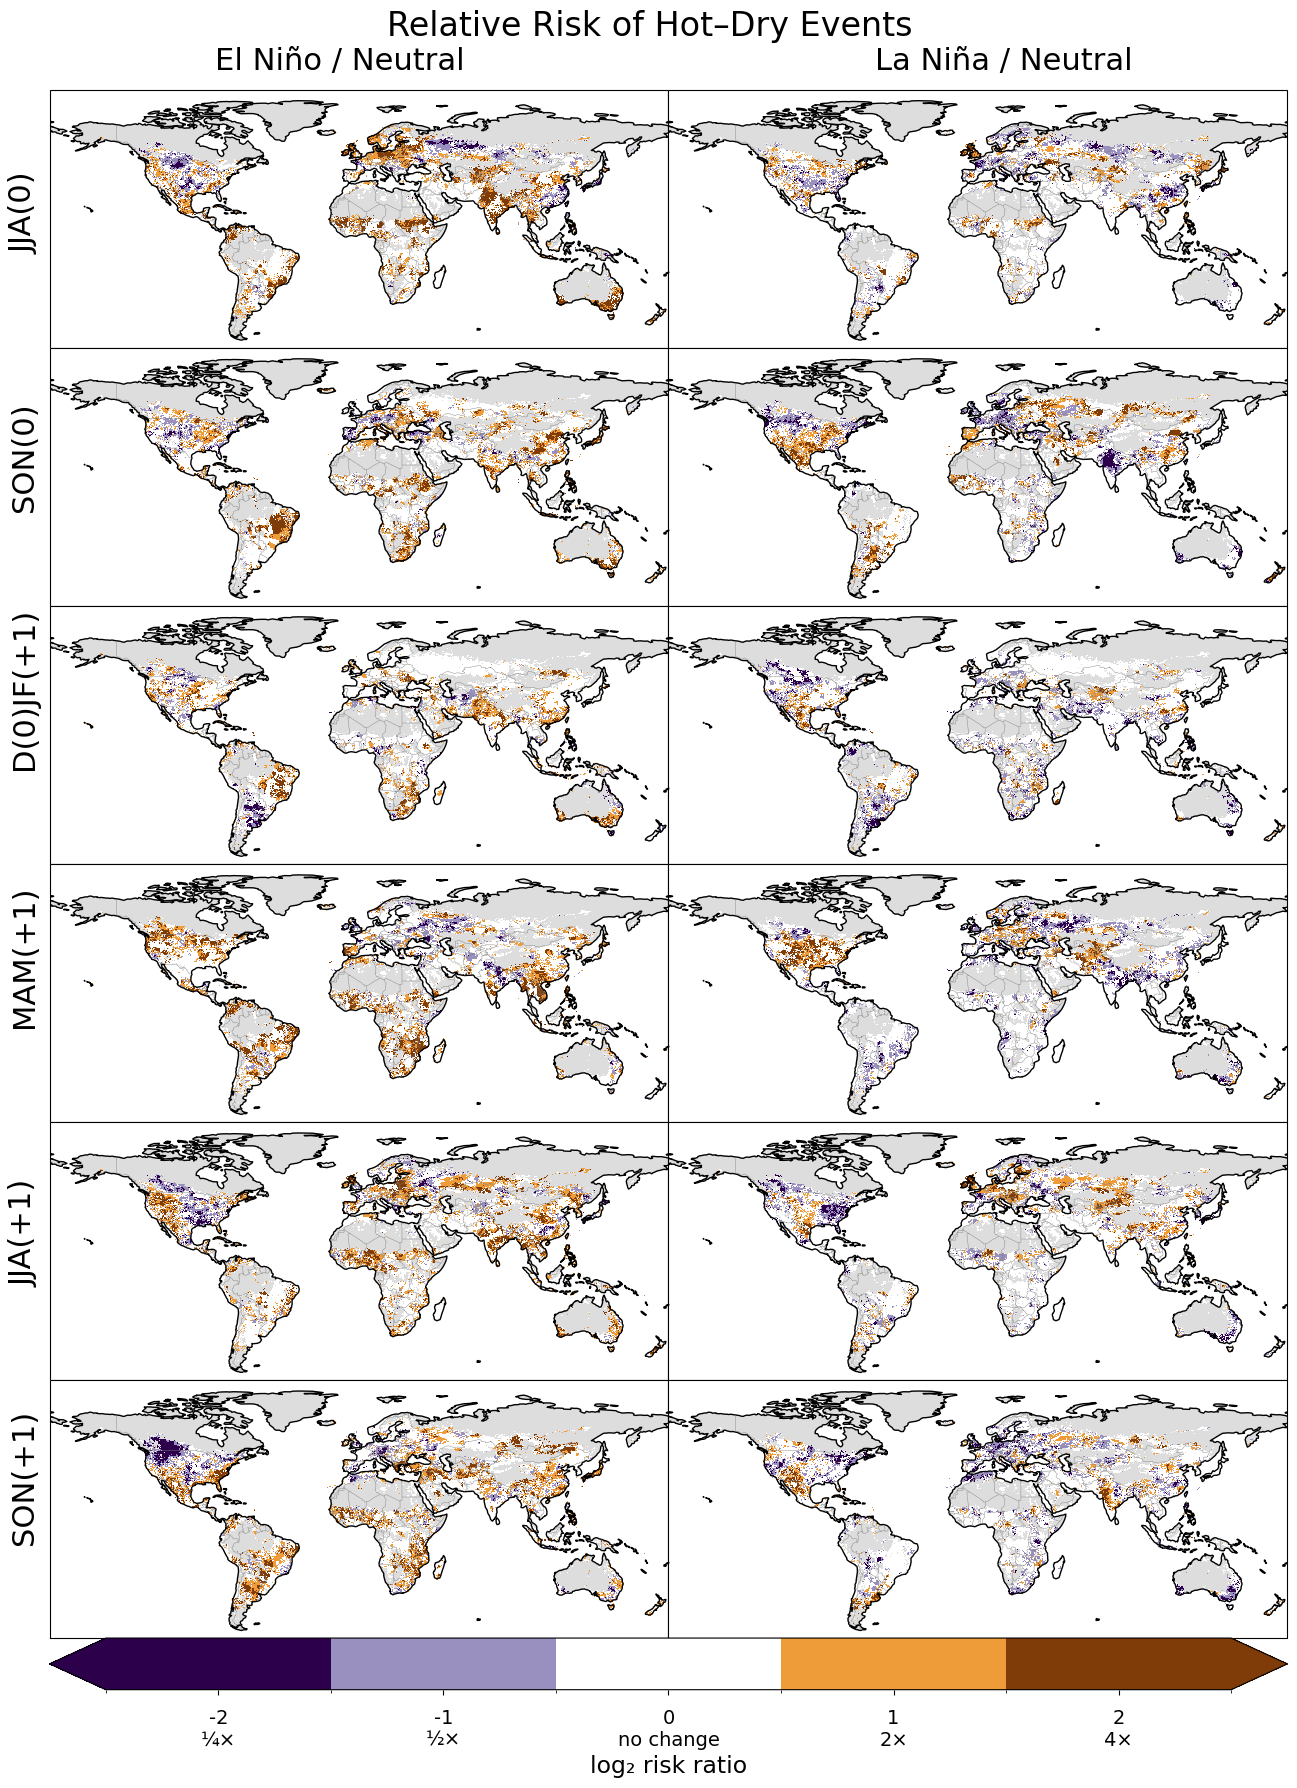

In [54]:
# ===== Imports =====
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ===== Config =====
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles  = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']
MIN_NE  = 0.001      # neutral prob floor (interpretability)
CAMPLOT = 'PuOr_r'     # requested cmap

# ===== log2 RR (no clipping) =====
def log2rr_prob(P_phase: xr.DataArray,
                P_neut: xr.DataArray,
                area: xr.DataArray | None = None,
                min_ne: float = MIN_NE,
                require_phase_pos: bool = True) -> xr.DataArray:
    """Return log2(P_phase / P_neut) with masking; no value clipping."""
    # If your grids are identical, align is optional; keep it for safety if you want.
    P_phase, P_neut = xr.align(P_phase, P_neut, join="inner")

    mask = np.isfinite(P_phase) & np.isfinite(P_neut) & (P_neut > min_ne)
    if require_phase_pos:
        mask = mask & (P_phase > 0)
    if area is not None:
        area = area.broadcast_like(P_phase)
        mask = mask & np.isfinite(area) & (area > 0)

    rr = xr.where(mask, P_phase / P_neut, np.nan)
    return xr.apply_ufunc(np.log2, rr)  # <-- no clip

def build_log2rr_seasonal(prob_phase: dict, prob_neutral: dict, area: xr.DataArray | None = None):
    return {s: log2rr_prob(prob_phase[s], prob_neutral[s], area=area) for s in prob_phase.keys()}

# ===== Plotter (discrete bins, no clipping; under/over arrows) =====
def plot_log2rr_pair_no_clip(
    log2_left: dict, log2_right: dict,
    seasons, titles, cropland_area_ha: xr.DataArray,
    suptitle='Relative Risk (log₂ Phase / Neutral)', cmap_name=CAMPLOT,
    # choose your *visual* limits via bins (data remain untouched)
    edges = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5])
):
    # Build discrete colormap with enough colors for extend='both'
    n_intervals = len(edges) - 1
    base        = plt.get_cmap(cmap_name)(np.linspace(0, 1, n_intervals))
    # set the bin containing 0 to white
    zero_idx    = int(np.clip(np.searchsorted(edges, 0.0) - 1, 0, n_intervals - 1))
    base[zero_idx] = (1, 1, 1, 1)

    # [UNDER, intervals..., OVER]
    colors = np.vstack([base[0], base, base[-1]])
    cmap   = mcolors.ListedColormap(colors, name=f'{cmap_name}_disc_noclip')
    cmap.set_bad((1, 1, 1, 0))
    norm   = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N, extend='both')

    # ticks at nice log2 values within range
    nominal_ticks = np.array([-2, -1, 0, 1, 2], dtype=float)
    tick_pos = nominal_ticks[(edges[0] <= nominal_ticks) & (nominal_ticks <= edges[-1])]
    tick_lbl = ['¼×' if t==-2 else '½×' if t==-1 else 'no change' if t==0 else '2×' if t==1 else '4×' for t in tick_pos]

    # cropland mask layer (white over land; non-cropland transparent)
    cropland_mask = (cropland_area_ha > 0)
    crops = xr.where(cropland_mask, 1.0, np.nan)
    cmap_crops = mcolors.ListedColormap([(1, 1, 1, 1)])
    cmap_crops.set_bad((1, 1, 1, 0))

    fig = plt.figure(figsize=(15, 20))
    gs = fig.add_gridspec(7, 3, height_ratios=[5,5,5,5,5,5,1],
                          width_ratios=[1,1,0.06], wspace=0, hspace=0)
    im_last = None

    for i, (S, ttl) in enumerate(zip(seasons, titles)):
        # LEFT
        ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax1.add_feature(cfeature.OCEAN, facecolor='white')
        ax1.add_feature(cfeature.LAND,  facecolor='#dddddd')
        ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
        ax1.text(-203, -2, ttl, fontsize=22, ha='left', rotation='vertical')

        ax1.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                       shading='auto', transform=ccrs.PlateCarree())
        daL = xr.where(cropland_mask, log2_left[S], np.nan)
        im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
                             shading='auto', transform=ccrs.PlateCarree())

        # RIGHT
        ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
        ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax2.add_feature(cfeature.OCEAN, facecolor='white')
        ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
        ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

        ax2.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                       shading='auto', transform=ccrs.PlateCarree())
        daR = xr.where(cropland_mask, log2_right[S], np.nan)
        im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
                             shading='auto', transform=ccrs.PlateCarree())
        im_last = im2

    # Colorbar
    cax = fig.add_subplot(gs[-1, :2])
    cbar = plt.colorbar(im_last, cax=cax, orientation='horizontal',
                        ticks=tick_pos, boundaries=edges, spacing='proportional', extend='both')
    cbar.set_label('log₂ risk ratio', fontsize=17)
    cbar.ax.tick_params(labelsize=14, pad=10)
    cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
    cbar.ax.set_xticklabels([f'{int(t)}\n{lbl}' for t, lbl in zip(tick_pos, tick_lbl)])

    fig.suptitle(suptitle, fontsize=24, x=0.45, y=0.94)
    fig.text(0.16, 0.91, 'El Niño / Neutral', fontsize=22)
    fig.text(0.60, 0.91, 'La Niña / Neutral', fontsize=22)
    fig.subplots_adjust(top=0.90, bottom=0.10, left=0.05, right=0.90)
    plt.show()

# ===== Build & Plot (example: Hot–Wet) =====
log2rr_el_hd = build_log2rr_seasonal(prob_el_nino_hot_dry_seasons, prob_neutral_hot_dry_seasons, area=cropland_area_ha)
log2rr_la_hd = build_log2rr_seasonal(prob_la_nina_hot_dry_seasons, prob_neutral_hot_dry_seasons, area=cropland_area_ha)

plot_log2rr_pair_no_clip(log2rr_el_hd, log2rr_la_hd, seasons, titles, cropland_area_ha,
                         suptitle='Relative Risk of Hot–Dry Events', cmap_name='PuOr_r',
                         edges=np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]))

In [59]:
# Choose threshold in log2 space:
#   any increase:            thr = 0.0
#   ≥ +10% increase:         thr = np.log2(1.10)
#   ≥ +50% increase:         thr = np.log2(1.50)
thr = 1.0   # change as needed

def area_fraction_increase(log2rr_dict, area_ha, seasons, thr=1.0):
    """Returns per-season and union fractions of cropland with increased risk."""
    # keep only positive cropland
    A = area_ha.where(area_ha > 0)

    # total cropland area (ha) over valid pixels
    A_total = A.sum(skipna=True)

    per_season_frac = {}
    per_season_area = {}

    # ensure alignment
    def _align(da): 
        return xr.align(da, A, join="inner")[0].broadcast_like(A)

    for s in seasons:
        L = _align(log2rr_dict[s])             # log2RR for this season
        mask = (L > thr) & np.isfinite(L) & np.isfinite(A)
        A_aff = A.where(mask).sum(skipna=True) # affected cropland area (ha)
        per_season_area[s] = float(A_aff)
        per_season_frac[s] = float((A_aff / A_total).item())

    # union across seasons: any season shows increase
    Ls = xr.concat([_align(log2rr_dict[s]) for s in seasons], dim="season")
    mask_any = (Ls > thr).any("season") & np.isfinite(A)
    A_aff_any = A.where(mask_any).sum(skipna=True)

    result = {
        "total_cropland_ha": float(A_total),
        "affected_cropland_ha_union": float(A_aff_any),
        "fraction_union": float((A_aff_any / A_total).item()),
        "per_season_area_ha": per_season_area,
        "per_season_fraction": per_season_frac,
        "threshold_log2": float(thr)
    }
    return result

# Example: El Niño vs Neutral for Hot–Dry (you already computed log2rr_el_hd)
res_el_hd = area_fraction_increase(log2rr_el_hd, cropland_area_ha, seasons, thr=1.0)

# If you also want La Niña vs Neutral:
res_la_hd = area_fraction_increase(log2rr_la_hd, cropland_area_ha, seasons, thr=1.0)

# Pretty print percentages
def pct(x): return f"{100*x:.1f}%"
print("El Niño HD — union fraction:", pct(res_el_hd["fraction_union"]))
for s in seasons:
    print(f"  {s}: {pct(res_el_hd['per_season_fraction'][s])}")

El Niño HD — union fraction: 58.4%
  JJA: 20.9%
  SON: 15.4%
  DJF: 9.8%
  MAM1: 14.5%
  JJA1: 16.7%
  SON1: 13.6%


In [61]:
print("\nLa Niña HD — union fraction:", pct(res_la_hd["fraction_union"]))
for s in seasons:
    print(f"  {s}: {pct(res_la_hd['per_season_fraction'][s])}")


La Niña HD — union fraction: 56.5%
  JJA: 13.3%
  SON: 19.0%
  DJF: 9.1%
  MAM1: 14.9%
  JJA1: 14.4%
  SON1: 12.5%


In [ ]:
# --- assumes: cropland_area_ha (lat, lon) with >0 on cropland ---

# Panels to show
seasons = ['JJA', 'JJA1']
titles  = ['JJA(0)', 'JJA(+1)']

# Column headings
left_col_title  = 'El Niño / Neutral'
right_col_title = 'La Niña / Neutral'

# Colormap: PuOr_r so PURPLE = increase, ORANGE = decrease
cmap_name = 'PuOr_r'

# Discrete bins in log2 space (~¼×, ½×, 1×, 2×, 4×)
edges    = np.array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5])
tick_pos = np.array([-2,   -1,    0,    1,    2 ])
tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']

# Build discrete diverging colormap and force the bin containing 0 to white
nbins = len(edges) - 1
base  = plt.get_cmap(cmap_name)(np.linspace(0, 1, nbins))
zero_idx = int(np.clip(np.searchsorted(edges, 0.0) - 1, 0, nbins - 1))  # bin that spans 0
base[zero_idx] = (1, 1, 1, 1)
# add UNDER/OVER colors so extend='both' works cleanly
colors = np.vstack([base[0], base, base[-1]])
cmap   = mcolors.ListedColormap(colors, name=f'{cmap_name}_disc')
norm   = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N, extend='both')

# ---- cropland display mask ----
cropland_mask = (cropland_area_ha > 0)
crops = xr.where(cropland_mask, 1.0, np.nan)                 # 1 on cropland, NaN elsewhere
cmap_crops = mcolors.ListedColormap([(1, 1, 1, 1)])          # cropland base = white
cmap_crops.set_bad((1, 1, 1, 0))                             # transparent off-cropland

# Figure & grid (tight gaps)
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(
    3, 3,
    height_ratios=[6, 6, 0.8],
    width_ratios=[1, 1, 0.12],
    wspace=-0.15, hspace=0.0
)

im_last = None
for i, (s, ttl) in enumerate(zip(seasons, titles)):
    # ---------- LEFT: El Niño / Neutral ----------
    ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax1.add_feature(cfeature.OCEAN, facecolor='white')       # ocean = white
    ax1.add_feature(cfeature.LAND,  facecolor='#dddddd')     # non-cropland land = grey
    ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax1.text(-203, -2, ttl, fontsize=18, ha='left', rotation='vertical')

    # cropland base (white over grey land)
    ax1.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                   shading='auto', transform=ccrs.PlateCarree())

    # plot data ONLY where cropland exists
    daL = xr.where(cropland_mask, log2rr_el_hd[s], np.nan)
    im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
                         transform=ccrs.PlateCarree(), shading='auto')

    # ---------- RIGHT: La Niña / Neutral ----------
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax2.add_feature(cfeature.OCEAN, facecolor='white')
    ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
    ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

    ax2.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                   shading='auto', transform=ccrs.PlateCarree())

    daR = xr.where(cropland_mask, log2rr_la_hd[s], np.nan)
    im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
                         transform=ccrs.PlateCarree(), shading='auto')
    im_last = im2  # for colorbar

# Column headers
fig.text(0.45, 0.90, left_col_title,  fontsize=18, ha='center')
fig.text(0.80, 0.90, right_col_title, fontsize=18, ha='center')

# Colorbar (bottom)
cbar_ax = fig.add_subplot(gs[-1, :])
cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal',
                    ticks=tick_pos, boundaries=edges, spacing='proportional',
                    extend='both')
cbar.set_label('log₂ risk ratio', fontsize=16)
cbar.ax.tick_params(labelsize=12, pad=6)
cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
cbar.ax.set_xticklabels([f'{v:.0f}\n{lab}' for v, lab in zip(tick_pos, tick_lbl)])

fig.suptitle('Relative Risk of Hot–Dry Events', fontsize=20, y=0.96, x=0.6)
fig.subplots_adjust(top=0.88, bottom=0.5, left=0.29, right=0.97)
plt.show()

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- assumes: cropland_area_ha (lat, lon) with >0 on cropland ---

# Panels to show
seasons = ['JJA']
titles  = ['JJA(0)']

# Column headings
left_col_title  = 'El Niño / Neutral'
right_col_title = 'La Niña / Neutral'

# Colormap: PuOr_r so PURPLE = increase, ORANGE = decrease
cmap_name = 'PuOr_r'

# Discrete bins in log2 space (~¼×, ½×, 1×, 2×, 4×)
edges    = np.array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5])
tick_pos = np.array([-2,   -1,    0,    1,    2 ])
tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']

# Build discrete diverging colormap and force the bin containing 0 to white
nbins = len(edges) - 1
base  = plt.get_cmap(cmap_name)(np.linspace(0, 1, nbins))
zero_idx = int(np.clip(np.searchsorted(edges, 0.0) - 1, 0, nbins - 1))  # bin that spans 0
base[zero_idx] = (1, 1, 1, 1)
# add UNDER/OVER colors so extend='both' works cleanly
colors = np.vstack([base[0], base, base[-1]])
cmap   = mcolors.ListedColormap(colors, name=f'{cmap_name}_disc')
norm   = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N, extend='both')

# ---- cropland display mask ----
cropland_mask = (cropland_area_ha > 0)
crops = xr.where(cropland_mask, 1.0, np.nan)                 # 1 on cropland, NaN elsewhere
cmap_crops = mcolors.ListedColormap([(1, 1, 1, 1)])          # cropland base = white
cmap_crops.set_bad((1, 1, 1, 0))                             # transparent off-cropland

# Figure & grid
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(
    3, 3,
    height_ratios=[6, 6, 0.8],    # bottom row unused
    width_ratios=[1, 1, 0.12],
    wspace=0.00, hspace=0.0
)

im_last = None
for i, (s, ttl) in enumerate(zip(seasons, titles)):
    # ---------- LEFT: El Niño / Neutral ----------
    ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
    ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax1.add_feature(cfeature.OCEAN, facecolor='white')
    ax1.add_feature(cfeature.LAND,  facecolor='#dddddd')
    ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
    ax1.text(-203, -2, ttl, fontsize=18, ha='left', rotation='vertical')

    # cropland base
    ax1.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                   shading='auto', transform=ccrs.PlateCarree())

    daL = xr.where(cropland_mask, log2rr_el_hd[s], np.nan)
    im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
                         transform=ccrs.PlateCarree(), shading='auto')

    # ---------- RIGHT: La Niña / Neutral ----------
    ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
    ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
    ax2.add_feature(cfeature.OCEAN, facecolor='white')
    ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
    ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

    ax2.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                   shading='auto', transform=ccrs.PlateCarree())

    daR = xr.where(cropland_mask, log2rr_la_hd[s], np.nan)
    im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
                         transform=ccrs.PlateCarree(), shading='auto')
    im_last = im2  # for colorbar

# Column headers
fig.text(0.30, 0.83, left_col_title,  fontsize=18, ha='center')
fig.text(0.70, 0.83, right_col_title, fontsize=18, ha='center')

# ---------- COLORBAR placed just under the JJA panels ----------
bboxL, bboxR = ax1.get_position(), ax2.get_position()
left, right = bboxL.x0, bboxR.x1
panel_bottom = min(bboxL.y0, bboxR.y0)

gap = 0   # vertical gap between panels and colorbar
h   = 0.038   # height of colorbar
y0  = panel_bottom - gap - h

cbar_ax = fig.add_axes([left, y0, right - left, h])
cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal',
                    ticks=tick_pos, boundaries=edges, spacing='proportional',
                    extend='both')
cbar.set_label('log₂ risk ratio', fontsize=16)
cbar.ax.tick_params(labelsize=12, pad=6)
cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
cbar.ax.set_xticklabels([f'{v:.0f}\n{lab}' for v, lab in zip(tick_pos, tick_lbl)])

# Minimal bottom margin so no extra white space below colorbar
fig.subplots_adjust(top=0.87, left=0.1, right=0.92, bottom=y0 - 0.37)

# Title
fig.suptitle('Relative Risk of Hot–Dry Events', fontsize=20, y=0.90, x=0.5)

plt.show()

In [ ]:
# # --- Inputs you already have ---
# # prob_el_nino_hot_dry_seasons[s]: xr.DataArray (lat, lon) with probability in [0,1]
# # prob_la_nina_hot_dry_seasons[s]: xr.DataArray (lat, lon)
# # prob_neutral_hot_dry_seasons[s] : xr.DataArray (lat, lon)
# # seasons = ['jja','son','djf','mam1','jja1','son1']

# def prob_ratio_masked(phase_probs: dict, neutral_probs: dict, seasons, min_ne=0.0):
#     """
#     Return dict of Phase/Neutral probability ratios per season.
#     Cells with Neutral prob <= min_ne are masked (set to NaN).
#     eps prevents division-by-zero in practice; with min_ne=0 the mask handles true zeros.
#     """
#     out = {}
#     for s in seasons:
#         P = phase_probs[s]
#         N = neutral_probs[s]
#         mask = (N > min_ne) & np.isfinite(P) & np.isfinite(N)
#         out[s] = xr.where(mask, (P) / (N), np.nan)
#     return out

# # --- Raw probability ratios (El/Neutral and La/Neutral) ---
# ratio_el_hd = prob_ratio_masked(prob_el_nino_hot_dry_seasons, prob_neutral_hot_dry_seasons, seasons, min_ne=0.0)
# ratio_la_hd = prob_ratio_masked(prob_la_nina_hot_dry_seasons, prob_neutral_hot_dry_seasons, seasons, min_ne=0.0)

In [ ]:
# import matplotlib.colors as mcolors

# def plot_ratio_pair(
#     ratio_left: dict,      # e.g., ratio_el_hd OR log2rr_el_hd (see flags below)
#     ratio_right: dict,     # e.g., ratio_la_hd OR log2rr_la_hd
#     seasons, titles,
#     suptitle='Relative change in Hot–Dry event probability',
#     left_hdr='El Niño / Neutral',
#     right_hdr='La Niña / Neutral',
#     mode='ratio'           # 'ratio' for Phase/Neutral, 'log2' for log₂(Phase/Neutral)
# ):
#     # Color scale & ticks
#     if mode == 'ratio':
#         vmin, vcenter, vmax = 0.25, 1.0, 4.0
#         norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
#         cmap = plt.get_cmap('PuOr_r')
#         tick_vals = [0.25, 0.5, 1, 2, 4]
#         tick_lbls = ['0.25×','0.5×','1×','2×','4×']
#         cbar_label = 'Probability ratio (Phase / Neutral)'
#     elif mode == 'log2':
#         vmin, vcenter, vmax = -2.0, 0.0, 2.0  # −2..2 → 0.25×..4×
#         norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
#         cmap = plt.get_cmap('PuOr_r')
#         tick_vals = [-2, -1, 0, 1, 2]
#         tick_lbls = ['¼×','½×','no change','2×','4×']
#         cbar_label = 'log₂(Phase / Neutral)'
#     else:
#         raise ValueError("mode must be 'ratio' or 'log2'")

#     fig = plt.figure(figsize=(15, 20))
#     gs = fig.add_gridspec(7, 3, height_ratios=[5,5,5,5,5,5,1],
#                           width_ratios=[1,1,0.06], wspace=0, hspace=0)
#     last_im = None

#     for i, (S, ttl) in enumerate(zip(seasons, titles)):
#         # Left
#         ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#         ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#         ax1.add_feature(cfeature.OCEAN, facecolor='white')
#         ax1.add_feature(cfeature.LAND,  facecolor='#dddddd')
#         ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#         ax1.text(-203, -2, ttl, fontsize=22, ha='left', rotation='vertical')

#         daL = ratio_left[S]
#         im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
#                              transform=ccrs.PlateCarree(), shading='auto')
#         last_im = im1

#         # Right
#         ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#         ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#         ax2.add_feature(cfeature.OCEAN, facecolor='white')
#         ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
#         ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

#         daR = ratio_right[S]
#         im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
#                              transform=ccrs.PlateCarree(), shading='auto')

#     # Colorbar
#     cax = fig.add_subplot(gs[-1, :2])
#     cbar = plt.colorbar(last_im, cax=cax, orientation='horizontal', extend='both')
#     cbar.set_ticks(tick_vals); cbar.set_ticklabels(tick_lbls)
#     cbar.set_label(cbar_label, fontsize=17)
#     cbar.ax.tick_params(labelsize=14)

#     # Titles
#     fig.suptitle(suptitle, fontsize=24, x=0.45, y=0.94)
#     fig.text(0.16, 0.91, left_hdr,  fontsize=22)
#     fig.text(0.60, 0.91, right_hdr, fontsize=22)

#     fig.subplots_adjust(top=0.90, bottom=0.10, left=0.05, right=0.90)
#     plt.show()


In [ ]:
# # For probability ratios (Phase / Neutral)
# plot_ratio_pair(ratio_el_hd, ratio_la_hd, seasons, titles,
#                 suptitle='Relative change in Hot–Dry event probability', mode='ratio')

In [ ]:
# def rel_change_masked(phase_probs: dict, neutral_probs: dict, seasons, min_ne=0.02):
#     """Return relative change (P - N)/N per season, masking tiny Neutral baselines."""
#     out = {}
#     for s in seasons:
#         P = phase_probs[s]
#         N = neutral_probs[s]
#         mask = np.isfinite(P) & np.isfinite(N) & (N > min_ne)
#         out[s] = xr.where(mask, ((P - N) / N)*100, np.nan)
#     return out

# # --- Raw probability ratios (El/Neutral and La/Neutral) ---
# rel_el_hd = rel_change_masked(prob_el_nino_hot_dry_seasons, prob_neutral_hot_dry_seasons, seasons, min_ne=0.02)
# rel_la_hd = rel_change_masked(prob_la_nina_hot_dry_seasons, prob_neutral_hot_dry_seasons, seasons, min_ne=0.02)

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
# import numpy as np
# import xarray as xr

# def plot_percent_change_pair(
#     change_left: dict,      
#     change_right: dict,     
#     seasons, titles,
#     suptitle='Relative change in Hot–Dry event probability (%)',
#     left_hdr='El Niño – Neutral/Neutral',
#     right_hdr='La Niña – Neutral/Neutral',
#     bins=None   # optional: specify custom bin edges
# ):
#     # ---- bins & colormaps ----
#     if bins is None:
#         bins = [0, 10, 20, 30, 40, 50, 75, 100, 150, 200]  # inclusive edges

#     # Discrete oranges for data
#     cmap = plt.get_cmap("Oranges", len(bins))   # >= number of bins is safe with extend
#     cmap.set_bad((1, 1, 1, 0))                  # masked (non-cropland) -> transparent
#     norm = mcolors.BoundaryNorm(bins, cmap.N, extend='max')

#     # Cropland base (white fill over land), masked elsewhere -> transparent
#     cmap_crops = mcolors.ListedColormap([(1, 1, 1, 1)])  # white
#     cmap_crops.set_bad((1, 1, 1, 0))

#     tick_vals = bins
#     tick_lbls = [f"{t}%" for t in bins]

#     fig = plt.figure(figsize=(15, 20))
#     gs = fig.add_gridspec(7, 3, height_ratios=[5,5,5,5,5,5,1],
#                           width_ratios=[1,1,0.06], wspace=0, hspace=0)
#     last_im = None

#     # Build cropland mask once (True where cropland exists)
#     cropland_mask_bool = (cropland_area_ha > 0)
#     crops = xr.where(cropland_mask_bool, 1.0, np.nan)  # for white cropland base

#     for i, (S, ttl) in enumerate(zip(seasons, titles)):
#         # ---------- LEFT ----------
#         ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#         ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#         ax1.add_feature(cfeature.OCEAN, facecolor='white')   # ocean white
#         ax1.add_feature(cfeature.LAND,  facecolor='#dddddd') # non-cropland land grey
#         ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#         ax1.text(-203, -2, ttl, fontsize=22, ha='left', rotation='vertical')

#         # cropland base (white)
#         ax1.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
#                        shading='auto', transform=ccrs.PlateCarree())

#         # data only on croplands
#         daL = xr.where(cropland_mask_bool, change_left[S], np.nan)
#         im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
#                              shading='auto', transform=ccrs.PlateCarree())
#         last_im = im1

#         # ---------- RIGHT ----------
#         ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#         ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#         ax2.add_feature(cfeature.OCEAN, facecolor='white')
#         ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
#         ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

#         ax2.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
#                        shading='auto', transform=ccrs.PlateCarree())

#         daR = xr.where(cropland_mask_bool, change_right[S], np.nan)
#         im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
#                              shading='auto', transform=ccrs.PlateCarree())

#     # Shared colorbar (discrete, extended on the right for > max bin)
#     cax = fig.add_subplot(gs[-1, :2])
#     cbar = plt.colorbar(last_im, cax=cax, orientation='horizontal', extend='max')
#     cbar.set_ticks(tick_vals); cbar.set_ticklabels(tick_lbls)
#     cbar.set_label('Relative change (%)', fontsize=17)
#     cbar.ax.tick_params(labelsize=14)

#     # Titles
#     fig.suptitle(suptitle, fontsize=24, x=0.45, y=0.94)
#     fig.text(0.14, 0.91, left_hdr,  fontsize=22)
#     fig.text(0.56, 0.91, right_hdr, fontsize=22)

#     fig.subplots_adjust(top=0.90, bottom=0.10, left=0.05, right=0.90)
#     plt.show()


In [ ]:
# plot_percent_change_pair(
#     rel_el_hd,    # dict of % changes for El Niño
#     rel_la_hd,    # dict of % changes for La Niña
#     seasons,
#     titles,
#     bins=[0, 10, 20, 30, 40, 50, 75, 100, 150, 200],  # custom discrete bins
#     suptitle='Relative change in risk of Hot–Dry events',
#     left_hdr='El Niño – Neutral / Neutral',
#     right_hdr='La Niña – Neutral / Neutral'  # adjust if your % changes go higher than 100
# )

In [ ]:
# import numpy as np
# import xarray as xr
# import pandas as pd

# # ---------- constants ----------
# MHA = 1e6
# EPS = 1e-9  # protects % change when Neutral ≈ 0
# seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
# # ---------- helpers ----------
# def expected_exposed_area_Mha_from_prob(prob_da: xr.DataArray,
#                                         area_ha: xr.DataArray,
#                                         zone_mask: xr.DataArray) -> float:
#     """
#     prob_da: per-cell probability (0..1) of event for a given phase+season
#     area_ha: cropland area per cell (ha)
#     zone_mask: boolean mask (True for cells to include)
#     """
#     # restrict to zone; multiply prob * area, sum, convert ha -> Mha
#     val = (prob_da.where(zone_mask) * area_ha.where(zone_mask)).sum(skipna=True)
#     return float(val) / MHA


# def expected_Mha_by_season(prob_dict: dict, area_ha: xr.DataArray,
#                            zone_mask: xr.DataArray, seasons) -> dict:
#     """Return {season: exposed area in Mha} for a phase."""
#     return {s: expected_exposed_area_Mha_from_prob(prob_dict[s], area_ha, zone_mask)
#             for s in seasons}


# def pct_change_vs_neutral_from_prob(phase_prob_dict: dict, neutral_prob_dict: dict,
#                                     area_ha: xr.DataArray, zone_mask: xr.DataArray,
#                                     seasons) -> dict:
#     """Return {season: % change of exposed Mha (Phase vs Neutral)}."""
#     out = {}
#     for s in seasons:
#         A_ne = expected_exposed_area_Mha_from_prob(neutral_prob_dict[s], area_ha, zone_mask)
#         A_ph = expected_exposed_area_Mha_from_prob(phase_prob_dict[s],    area_ha, zone_mask)
#         out[s] = 100.0 * (A_ph - A_ne) / (A_ne + EPS)
#     return out


# def top_season(df: pd.DataFrame, col: str, zone_label: str) -> pd.DataFrame:
#     d = df.loc[:, ["season", col]]
#     return d.iloc[[d[col].values.argmax()]].rename(columns={col: "max %"}).assign(zone=zone_label)


# # ============================
# # === EXAMPLE: HOT–WET (HW) ==
# # ============================
# # Inputs you already have:
# # - prob_el_nino_hot_wet_seasons: dict[str -> xr.DataArray] (per-season HW prob during El Niño)
# # - prob_la_nina_hot_wet_seasons: dict[str -> xr.DataArray] (per-season HW prob during La Niña)
# # - prob_neutral_hot_wet_seasons: dict[str -> xr.DataArray] (per-season HW prob during Neutral)
# # - cropland_area_ha: xr.DataArray
# # - seasons: list[str], e.g., ['JJA','SON','DJF','MAM1','JJA1','SON1']

# # 1) Define your zone (global cropland here; swap for regional masks if needed)
# global_mask = (cropland_area_ha > 0)

# el_Mha_hd = expected_Mha_by_season(prob_el_nino_hot_dry_seasons, cropland_area_ha, global_mask, seasons)
# la_Mha_hd = expected_Mha_by_season(prob_la_nina_hot_dry_seasons, cropland_area_ha, global_mask, seasons)
# ne_Mha_hd = expected_Mha_by_season(prob_neutral_hot_dry_seasons,  cropland_area_ha, global_mask, seasons)

# el_vs_ne_pct_hd = pct_change_vs_neutral_from_prob(
#     prob_el_nino_hot_dry_seasons, prob_neutral_hot_dry_seasons,
#     cropland_area_ha, global_mask, seasons
# )
# la_vs_ne_pct_hd = pct_change_vs_neutral_from_prob(
#     prob_la_nina_hot_dry_seasons, prob_neutral_hot_dry_seasons,
#     cropland_area_ha, global_mask, seasons
# )

# df_global_hd = pd.DataFrame([
#     {
#         "zone": "Global cropland",
#         "season": s,
#         "El_vs_Ne (%)": el_vs_ne_pct_hd[s],
#         "La_vs_Ne (%)": la_vs_ne_pct_hd[s],
#         "El (Mha)": el_Mha_hd[s],
#         "Ne (Mha)": ne_Mha_hd[s],
#         "La (Mha)": la_Mha_hd[s],
#     }
#     for s in seasons
# ]).sort_values(["zone", "season"])

# print("\n=== Hot–Dry: % change vs Neutral — Global cropland ===")
# print(df_global_hd)

# print("\n=== Peak season — El vs Neutral (global, HD) ===")
# print(top_season(df_global_hd, "El_vs_Ne (%)", "Global cropland"))

# print("\n=== Peak season — La vs Neutral (global, HD) ===")
# print(top_season(df_global_hd, "La_vs_Ne (%)", "Global cropland"))


In [ ]:
# from matplotlib.ticker import FixedLocator, StrMethodFormatter, FuncFormatter

# # -----------------------------
# # Risk = probability * area
# # -----------------------------
# def build_risk(prob_dict, area_ha, seasons):
#     return {s: (prob_dict[s] * area_ha) for s in seasons}

# risk_el_hd = build_risk(prob_el_nino_hot_dry_seasons, cropland_area_ha, seasons)
# risk_la_hd = build_risk(prob_la_nina_hot_dry_seasons, cropland_area_ha, seasons)
# risk_ne_hd = build_risk(prob_neutral_hot_dry_seasons, cropland_area_ha, seasons)

# # ---------------------------------------------
# # Symmetric % change (SPC)
# # ---------------------------------------------

# # Symmetric % change, masked where Neutral baseline is tiny
# def sym_percent_change_masked(A, B, base, cell_area_ha, frac_of_cell=0.005, min_ha=100.0):
#     """
#     SPC = 200*(A-B)/(A+B); mask cells where baseline 'base' is < max(frac_of_cell*cell_area_ha, min_ha).
#     'A' is ENSO-phase risk; 'B' is Neutral risk; 'base' should be Neutral risk (B).
#     """
#     denom = xr.where((A + B) > 0, A + B, np.nan)
#     spc = 200.0 * (A - B) / denom
#     min_base = xr.apply_ufunc(np.maximum, frac_of_cell * cell_area_ha, min_ha)
#     return spc.where(base >= min_base)

# risk_rel_el_hd = {
#     s: sym_percent_change_masked(risk_el_hd[s], risk_ne_hd[s], risk_ne_hd[s], grid_area_2d_ha)
#     for s in seasons
# }
# risk_rel_la_hd = {
#     s: sym_percent_change_masked(risk_la_hd[s], risk_ne_hd[s], risk_ne_hd[s], grid_area_2d_ha)
#     for s in seasons
# }

In [ ]:
# seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
# titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# # Custom color map for BrBG with a white midpoint
# # Sample colors from 'BrBG'
# puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 12))
# # Adjust colors to have white between -0.5 and 0.5
# puor_rcolors[5:7] = [1, 1, 1, 1]  
# cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=12)
# levels = np.linspace(-150, 150, 13)

# # Create the figure with 2 columns and 5 rows, shared colorbar at the bottom
# fig = plt.figure(figsize=(15, 20))
# gs = fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# # Plot each season for El Niño - Neutral and La Niña - Neutral
# for i, (season, title) in enumerate(zip(seasons, titles)):
#     # El Niño - Neutral on the left
#     ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#     im1 = ax1.pcolormesh(risk_rel_el_hd[season].lon, risk_rel_el_hd[season].lat, risk_rel_el_hd[season], cmap=cmap,
#                          transform=ccrs.PlateCarree(), vmin=-150, vmax=150)
#     ax1.set_global()
#     ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax1.coastlines()
#     ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#     ax1.text(-203, -2, titles[i], fontsize=22, ha='left', rotation='vertical')
#     ax1.add_feature(cfeature.LAND, facecolor='#dddddd')

#     # La Niña - Neutral on the right
#     ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#     im2 = ax2.pcolormesh(risk_rel_la_hd[season].lon, risk_rel_la_hd[season].lat, risk_rel_la_hd[season], cmap=cmap,
#                          transform=ccrs.PlateCarree(), vmin=-150, vmax=150)
#     ax2.set_global()
#     ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax2.coastlines()
#     ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#     ax2.add_feature(cfeature.LAND, facecolor='#dddddd')

# # Add a common colorbar at the bottom spanning both columns
# cbar_ax = fig.add_subplot(gs[-1, :2])  # Span both columns
# cbar = plt.colorbar(im1, cax=cbar_ax, orientation='horizontal', ticks=levels, label='Δ Risk (%)', extend='both')
# cbar.ax.xaxis.label.set_size(17)
# cbar.ax.tick_params(labelsize=14)

# # Add common titles
# fig.suptitle('Change in Risk of Hot–Dry Events', fontsize=24, x=0.45, y=0.94)
# fig.text(0.16, 0.91, 'El Niño - Neutral', fontsize=22, rotation='horizontal', va='center')
# fig.text(0.60, 0.91, 'La Niña - Neutral', fontsize=22, rotation='horizontal', va='center')

# # Adjust layout to create space for the colorbar
# fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)

# # Show the plot
# plt.show()

In [ ]:
# seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
# titles = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']

# # Custom color map for BrBG with a white midpoint
# # Sample colors from 'BrBG'
# puor_rcolors = plt.get_cmap('PuOr_r')(np.linspace(0, 1, 12))
# # Adjust colors to have white between -0.5 and 0.5
# puor_rcolors[5:7] = [1, 1, 1, 1]  
# cmap = mcolors.LinearSegmentedColormap.from_list('custom', puor_rcolors, N=12)
# levels = np.linspace(-150, 150, 13)

# # Create the figure with 2 columns and 5 rows, shared colorbar at the bottom
# fig = plt.figure(figsize=(15, 20))
# gs = fig.add_gridspec(7, 3, height_ratios=[5, 5, 5, 5, 5, 5, 1], width_ratios=[1, 1, 0.06], wspace=0, hspace=0)

# # Plot each season for El Niño - Neutral and La Niña - Neutral
# for i, (season, title) in enumerate(zip(seasons, titles)):
#     # El Niño - Neutral on the left
#     ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#     im1 = ax1.pcolormesh(risk_rel_el_hd[season].lon, risk_rel_el_hd[season].lat, risk_rel_el_hd[season], cmap=cmap,
#                          transform=ccrs.PlateCarree(), vmin=-150, vmax=150)
#     ax1.set_global()
#     ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax1.coastlines()
#     ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#     ax1.text(-203, -2, titles[i], fontsize=22, ha='left', rotation='vertical')
#     ax1.add_feature(cfeature.LAND, facecolor='#dddddd')

#     # La Niña - Neutral on the right
#     ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#     im2 = ax2.pcolormesh(risk_rel_la_hd[season].lon, risk_rel_la_hd[season].lat, risk_rel_la_hd[season], cmap=cmap,
#                          transform=ccrs.PlateCarree(), vmin=-150, vmax=150)
#     ax2.set_global()
#     ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax2.coastlines()
#     ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#     ax2.add_feature(cfeature.LAND, facecolor='#dddddd')

# # Add a common colorbar at the bottom spanning both columns
# # --- Colorbar (replace your current colorbar block with this) ---
# cbar_ax = fig.add_subplot(gs[-1, :2])  # Span both columns

# # Use BoundaryNorm-like tick spacing look by passing ticks explicitly; still fine with a continuous cmap
# cbar = plt.colorbar(
#     im1, cax=cbar_ax, orientation='horizontal',
#     ticks=levels, label='Δ Risk (%)', extend='both'
# )

# cbar.ax.xaxis.label.set_size(17)
# cbar.ax.tick_params(labelsize=14, pad=8)  # a bit more padding for two-line labels
# cbar.ax.xaxis.set_major_locator(FixedLocator(levels))

# # ---- Build two-line tick labels: "<SPC>\n×<ratio>" ----
# def spc_to_ratio(spc):
#     # SPC = 200*(A-B)/(A+B)  ->  ratio r = A/B = (200 + SPC)/(200 - SPC)
#     denom = 200.0 - spc
#     return np.nan if np.isclose(denom, 0.0) else (200.0 + spc) / denom

# def fmt_ratio(r):
#     if not np.isfinite(r):
#         return ''
#     # nice compact formatting
#     if r >= 10 or r < 0.1:
#         return f'{r:.0f}'
#     if r >= 3:
#         return f'{r:.1f}'
#     return f'{r:.2g}'

# tick_labels = []
# for t in levels:
#     # first line: the SPC tick (as integer)
#     spc_txt = f'{t:.0f}'
#     # second line: ×multiplier
#     r = spc_to_ratio(t)
#     r_txt = fmt_ratio(r)
#     tick_labels.append(spc_txt if r_txt == '' else f'{spc_txt}\n×{r_txt}')

# cbar.ax.set_xticklabels(tick_labels)

# # Add common titles
# fig.suptitle('Change in Risk of Hot–Dry Events', fontsize=24, x=0.45, y=0.94)
# fig.text(0.16, 0.91, 'El Niño - Neutral', fontsize=22, rotation='horizontal', va='center')
# fig.text(0.60, 0.91, 'La Niña - Neutral', fontsize=22, rotation='horizontal', va='center')

# # Adjust layout to create space for the colorbar
# fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)

# # Show the plot
# plt.show()

In [ ]:
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from matplotlib.ticker import FixedLocator
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# def log2_ratio(A: xr.DataArray, B: xr.DataArray, eps=1e-12, clip=(-3, 3)) -> xr.DataArray:
#     """
#     log2(A/B) with robust masking:
#       - mask non-finite A or B
#       - mask tiny B (<= eps)
#       - add eps to avoid log2(0)
#       - optional clip to keep plots bounded
#     """
#     cond = np.isfinite(A) & np.isfinite(B) & (B > eps)
#     ratio = xr.where(cond, (A + eps) / (B + eps), np.nan)
#     l2 = xr.apply_ufunc(np.log2, ratio)

#     if clip is not None:
#         lo, hi = clip
#         l2 = l2.clip(min=lo, max=hi)  # e.g., cap at ±8× on the plot

#     return l2

# # ---- Unclipped log2 ratio for histograms (mask tiny Neutral) ----
# def log2_ratio_no_clip(A, B, min_freq=0.05):
#     """Return log2(A/B) with masking for non-finite and tiny frequencies."""
#     cond = np.isfinite(A) & np.isfinite(B) & (A > min_freq) & (B > min_freq)
#     ratio = xr.where(cond, A / B, np.nan)
#     return xr.apply_ufunc(np.log2, ratio)


# # ---------- build risk (expected exposed area = probability * cropland area) ----------
# def build_risk(prob_dict, area_ha, seasons):
#     return {s: (prob_dict[s] * area_ha) for s in seasons}

# cropland_mask = xr.where(cropland_area_ha > 0, True, False)

# # Use your existing dicts of probabilities per season:
# # prob_el_nino_hot_wet_seasons, prob_la_nina_hot_wet_seasons, prob_neutral_hot_wet_seasons
# risk_el_hd = build_risk(prob_el_nino_hot_dry_seasons, cropland_area_ha, seasons)
# risk_la_hd = build_risk(prob_la_nina_hot_dry_seasons, cropland_area_ha, seasons)
# risk_ne_hd = build_risk(prob_neutral_hot_dry_seasons, cropland_area_ha, seasons)

# # ---------- log2 risk ratio maps: El/Neutral and La/Neutral ----------
# log2rr_el_hd = {s: log2_ratio(risk_el_hd[s], risk_ne_hd[s]) for s in seasons}
# log2rr_la_hd = {s: log2_ratio(risk_la_hd[s], risk_ne_hd[s]) for s in seasons}

# # # ---------- plotting (discrete, centered, with multiplier labels) ----------
# # def plot_log2rr_pair(log2_left, log2_right, seasons, titles,
# #                      suptitle='Relative Risk of Hot–Dry Events',
# #                      cmap_name='PuOr_r'):
# #     # Bin edges (discrete) centered on –2, –1, 0, 1, 2
# #     # These correspond to multipliers: 1/4×, 1/2×, 1×, 2×, 4×
# #     edges = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5])  # 5 bins
# #     tick_pos = np.array([ -2, -1, 0, 1, 2])
# #     tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']

# #     # Make a diverging cmap with a white center bin
# #     base = plt.get_cmap(cmap_name)(np.linspace(0, 1, len(edges)-1))
# #     # center bin index (for edges that straddle 0): bin 2 (0-based)
# #     base[2] = (1, 1, 1, 1)  # white for "no change" bin
# #     cmap = mcolors.ListedColormap(base, name=f'{cmap_name}_disc')
# #     norm = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N)

# #     fig = plt.figure(figsize=(15, 20))
# #     gs = fig.add_gridspec(7, 3, height_ratios=[5,5,5,5,5,5,1],
# #                           width_ratios=[1,1,0.06], wspace=0, hspace=0)
# #     im_last = None

# #     for i, (s, ttl) in enumerate(zip(seasons, titles)):
# #         # Left: El Niño / Neutral
# #         ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
# #         daL = log2_left[s]
# #         im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
# #                              transform=ccrs.PlateCarree(), shading='auto')
# #         ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
# #         ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
# #         ax1.add_feature(cfeature.LAND, facecolor='#dddddd')
# #         ax1.text(-203, -2, ttl, fontsize=22, ha='left', rotation='vertical')

# #         # Right: La Niña / Neutral
# #         ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
# #         daR = log2_right[s]
# #         im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
# #                              transform=ccrs.PlateCarree(), shading='auto')
# #         ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
# #         ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
# #         ax2.add_feature(cfeature.LAND, facecolor='#dddddd')
# #         im_last = im2

# #     # Colorbar
  
# #     cbar_ax = fig.add_subplot(gs[-1, :2])
# #     cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal', ticks=tick_pos, boundaries=edges, spacing='proportional', extend='both')
# #     cbar.set_label('log₂ risk ratio', fontsize=17)
# #     cbar.ax.tick_params(labelsize=14, pad=10)  # more padding for two-line labels
# #     cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))

# #     # ---- Build two-line tick labels ----
# #     tick_labels = []
# #     for val, mult in zip(tick_pos, tick_lbl):
# #     # first line = numeric log2(RR)
# #         log_txt = f'{val:.0f}'
# #     # second line = interpretation (no change, 2×, ½×, etc.)
# #         tick_labels.append(f'{log_txt}\n{mult}')
# #     cbar.ax.set_xticklabels(tick_labels)
    
# #     # cbar_ax = fig.add_subplot(gs[-1, :2])
# #     # cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal',
# #     #                     ticks=tick_pos, boundaries=edges, spacing='proportional')
# #     # cbar.set_label('log₂ risk ratio (Phase / Neutral)', fontsize=17)
# #     # cbar.ax.tick_params(labelsize=14)
# #     # cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
# #     # cbar.ax.set_xticklabels(tick_lbl)  # show multipliers directly

# #     fig.suptitle(suptitle, fontsize=24, x=0.45, y=0.94)
# #     fig.text(0.16, 0.91, 'El Niño / Neutral', fontsize=22)
# #     fig.text(0.60, 0.91, 'La Niña / Neutral', fontsize=22)
# #     fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
# #     plt.show()
    
# def plot_log2rr_pair(
#     log2_left, log2_right, seasons, titles,
#     suptitle='Relative Risk of Hot–Dry Events',
#     cmap_name='PuOr_r'
# ):
#     import numpy as np
#     import matplotlib.colors as mcolors
#     from matplotlib.ticker import FixedLocator

#     # ----- discrete log2 bins & labels -----
#     edges    = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5])
#     tick_pos = np.array([-2, -1, 0, 1, 2])
#     tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']

#     # Diverging cmap with white center; make masked values transparent (alpha=0)
#     base = plt.get_cmap(cmap_name)(np.linspace(0, 1, len(edges) - 1))
#     base[2] = (1, 1, 1, 1)                       # center bin is white
#     cmap = mcolors.ListedColormap(base, name=f'{cmap_name}_disc')
#     cmap.set_bad((1, 1, 1, 0))                   # masked -> fully transparent
#     norm = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N)

#     # ----- cropland mask -----
#     # True where cropland exists (>0); this should share lat/lon coords with your risk arrays
#     cropland_mask = (cropland_area_ha > 0)

#     # Small 1-color colormap to paint cropland base as white; masked -> transparent
#     cmap_crops = mcolors.ListedColormap([(1, 1, 1, 1)])  # white
#     cmap_crops.set_bad((1, 1, 1, 0))                     # non-cropland -> transparent

#     fig = plt.figure(figsize=(15, 20))
#     gs = fig.add_gridspec(7, 3, height_ratios=[5,5,5,5,5,5,1],
#                           width_ratios=[1,1,0.06], wspace=0, hspace=0)
#     im_last = None

#     for i, (s, ttl) in enumerate(zip(seasons, titles)):
#         # -------------- LEFT: El Niño / Neutral --------------
#         ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#         ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#         ax1.add_feature(cfeature.OCEAN, facecolor='white')   # ocean white
#         ax1.add_feature(cfeature.LAND,  facecolor='#dddddd') # non-cropland land grey
#         ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#         ax1.text(-203, -2, ttl, fontsize=22, ha='left', rotation='vertical')

#         # cropland base (white) over land; transparent elsewhere
#         crops = xr.where(cropland_mask, 1.0, np.nan)
#         ax1.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
#                        shading='auto', transform=ccrs.PlateCarree())

#         # log2RR only on cropland; transparent elsewhere so grey shows through
#         daL = xr.where(cropland_mask, log2_left[s], np.nan)
#         im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm, shading='auto',
#                              transform=ccrs.PlateCarree())

#         # -------------- RIGHT: La Niña / Neutral --------------
#         ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#         ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#         ax2.add_feature(cfeature.OCEAN, facecolor='white')
#         ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
#         ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

#         ax2.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
#                        shading='auto', transform=ccrs.PlateCarree())

#         daR = xr.where(cropland_mask, log2_right[s], np.nan)
#         im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm, shading='auto',
#                              transform=ccrs.PlateCarree())
#         im_last = im2

#     # ----- shared colorbar -----
#     cbar_ax = fig.add_subplot(gs[-1, :2])
#     cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal',
#                         ticks=tick_pos, boundaries=edges, spacing='proportional', extend='both')
#     cbar.set_label('log₂ risk ratio', fontsize=17)
#     cbar.ax.tick_params(labelsize=14, pad=10)
#     cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
#     cbar.ax.set_xticklabels([f'{v:.0f}\n{lbl}' for v, lbl in zip(tick_pos, ['¼×','½×','no change','2×','4×'])])

#     fig.suptitle(suptitle, fontsize=24, x=0.45, y=0.94)
#     fig.text(0.16, 0.91, 'El Niño / Neutral', fontsize=22)
#     fig.text(0.60, 0.91, 'La Niña / Neutral', fontsize=22)
#     fig.subplots_adjust(top=0.9, bottom=0.1, left=0.05, right=0.9)
#     plt.show()
    
# # ---- MAKE THE MAPS (Hot–Wet) ----
# plot_log2rr_pair(log2rr_el_hd, log2rr_la_hd, seasons, titles)

In [ ]:
# # --- 1) Unclipped log2 ratios (mask tiny Neutral) ---
# def log2_ratio_no_clip(A, B, min_freq=0.05):
#     """Return log2(A/B) with masking for non-finite and tiny frequencies."""
#     cond = np.isfinite(A) & np.isfinite(B) & (A > min_freq) & (B > min_freq)
#     ratio = xr.where(cond, A / B, np.nan)
#     return xr.apply_ufunc(np.log2, ratio)

# # Build per-season, NO-CLIP log ratios from PROBABILITIES (area cancels anyway)
# lrr_el_hd_noclip = {s: log2_ratio_no_clip(prob_el_nino_hot_dry_seasons[s],
#                                           prob_neutral_hot_dry_seasons[s], min_freq=0.05)
#                     for s in seasons}
# lrr_la_hd_noclip = {s: log2_ratio_no_clip(prob_la_nina_hot_dry_seasons[s],
#                                           prob_neutral_hot_dry_seasons[s], min_freq=0.05)
#                     for s in seasons}

# # --- 2) Per-season area-weighted histograms (Mha per bin) ---
# import matplotlib.pyplot as plt
# import numpy as np

# def _flatten_vals_weights(da_lrr, area_ha, mask):
#     v = da_lrr.where(mask).values.ravel()
#     w = area_ha.where(mask).values.ravel() / 1e6  # ha -> Mha
#     m = np.isfinite(v) & np.isfinite(w)
#     return v[m], w[m]

# def plot_area_weighted_hist_per_season(lrr_el, lrr_la, area_ha, mask, seasons, suptitle):
#     n = len(seasons)
#     fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 2.6*n), sharex='row', sharey='row')
#     if n == 1: axes = np.array([axes])  # normalize shape

#     for i, s in enumerate(seasons):
#         # gather vals & weights for this season
#         v_el, w_el = _flatten_vals_weights(lrr_el[s], area_ha, mask)
#         v_la, w_la = _flatten_vals_weights(lrr_la[s], area_ha, mask)

#         # common bins per season (robust to tails)
#         lo = np.nanpercentile(np.concatenate([v_el, v_la]), 1)
#         hi = np.nanpercentile(np.concatenate([v_el, v_la]), 99)
#         pad = max(0.25, 0.1*(hi-lo))
#         bins = np.linspace(lo-pad, hi+pad, 15)

#         # El Niño
#         ax = axes[i, 0]
#         ax.hist(v_el, bins=bins, weights=w_el, edgecolor='k', alpha=0.75)
#         ax.axvline(0,  color='k',  ls='--'); ax.axvline(-1, color='r', ls=':'); ax.axvline(1, color='g', ls=':')
#         ax.set_ylabel(f"{s}\nCropland area (Mha)")
#         if i == 0: ax.set_title("El Niño vs Neutral")

#         # La Niña
#         ax = axes[i, 1]
#         ax.hist(v_la, bins=bins, weights=w_la, edgecolor='k', alpha=0.75)
#         ax.axvline(0,  color='k',  ls='--'); ax.axvline(-1, color='r', ls=':'); ax.axvline(1, color='g', ls=':')
#         if i == 0: ax.set_title("La Niña vs Neutral")

#         # shared x label on last row
#         axes[-1, 0].set_xlabel('log₂(Phase / Neutral)')
#         axes[-1, 1].set_xlabel('log₂(Phase / Neutral)')

#         # optional: annotate area-weighted mean per season
#         def wmean(v, w): 
#             m = np.isfinite(v) & np.isfinite(w)
#             return np.average(v[m], weights=w[m]) if m.any() else np.nan
#         mu_el = wmean(v_el, w_el); mu_la = wmean(v_la, w_la)
#         axes[i,0].text(0.98, 0.92, f"mean={mu_el:+.2f}", transform=axes[i,0].transAxes,
#                        ha='right', va='top', fontsize=9, bbox=dict(fc='white', ec='none', alpha=0.7))
#         axes[i,1].text(0.98, 0.92, f"mean={mu_la:+.2f}", transform=axes[i,1].transAxes,
#                        ha='right', va='top', fontsize=9, bbox=dict(fc='white', ec='none', alpha=0.7))

#     fig.suptitle(suptitle, fontsize=14)
#     fig.tight_layout(rect=[0,0,1,0.97])
#     plt.show()

# # --- Run (Hot–Dry) ---
# plot_area_weighted_hist_per_season(
#     lrr_el_hd_noclip, lrr_la_hd_noclip, cropland_area_ha, cropland_area_ha > 0,
#     seasons,
#     suptitle="Area-weighted histograms of log risk ratios by season (Hot–Dry - Global)"
# )

In [ ]:
# # --- 1) Unclipped log2 ratios (mask tiny Neutral) ---
# def log2_ratio_no_clip(A, B, min_freq=0.05):
#     """Return log2(A/B) with masking for non-finite and tiny frequencies."""
#     cond = np.isfinite(A) & np.isfinite(B) & (A > min_freq) & (B > min_freq)
#     ratio = xr.where(cond, A / B, np.nan)
#     return xr.apply_ufunc(np.log2, ratio)

# # Build per-season, NO-CLIP log ratios from PROBABILITIES (area cancels anyway)
# lrr_el_hd_noclip = {s: log2_ratio_no_clip(prob_el_nino_hot_dry_seasons[s],
#                                           prob_neutral_hot_dry_seasons[s], min_freq=0.05)
#                     for s in seasons}
# lrr_la_hd_noclip = {s: log2_ratio_no_clip(prob_la_nina_hot_dry_seasons[s],
#                                           prob_neutral_hot_dry_seasons[s], min_freq=0.05)
#                     for s in seasons}

# # --- 2) Per-season area-weighted histograms (Mha per bin) ---
# import matplotlib.pyplot as plt
# import numpy as np

# def _flatten_vals_weights(da_lrr, area_ha, mask):
#     v = da_lrr.where(mask).values.ravel()
#     w = area_ha.where(mask).values.ravel() / 1e6  # ha -> Mha
#     m = np.isfinite(v) & np.isfinite(w)
#     return v[m], w[m]

# def plot_area_weighted_hist_per_season(lrr_el, lrr_la, area_ha, mask, seasons, suptitle):
#     n = len(seasons)
#     fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 2.6*n), sharex='row', sharey='row')
#     if n == 1: axes = np.array([axes])  # normalize shape

#     for i, s in enumerate(seasons):
#         # gather vals & weights for this season
#         v_el, w_el = _flatten_vals_weights(lrr_el[s], area_ha, mask)
#         v_la, w_la = _flatten_vals_weights(lrr_la[s], area_ha, mask)

#         # common bins per season (robust to tails)
#         lo = np.nanpercentile(np.concatenate([v_el, v_la]), 1)
#         hi = np.nanpercentile(np.concatenate([v_el, v_la]), 99)
#         pad = max(0.25, 0.1*(hi-lo))
#         bins = np.linspace(lo-pad, hi+pad, 15)

#         # El Niño
#         ax = axes[i, 0]
#         ax.hist(v_el, bins=bins, weights=w_el, edgecolor='k', alpha=0.75)
#         ax.axvline(0,  color='k',  ls='--'); ax.axvline(-1, color='r', ls=':'); ax.axvline(1, color='g', ls=':')
#         ax.set_ylabel(f"{s}\nCropland area (Mha)")
#         if i == 0: ax.set_title("El Niño vs Neutral")

#         # La Niña
#         ax = axes[i, 1]
#         ax.hist(v_la, bins=bins, weights=w_la, edgecolor='k', alpha=0.75)
#         ax.axvline(0,  color='k',  ls='--'); ax.axvline(-1, color='r', ls=':'); ax.axvline(1, color='g', ls=':')
#         if i == 0: ax.set_title("La Niña vs Neutral")

#         # shared x label on last row
#         axes[-1, 0].set_xlabel('log₂(Phase / Neutral)')
#         axes[-1, 1].set_xlabel('log₂(Phase / Neutral)')

#         # optional: annotate area-weighted mean per season
#         def wmean(v, w): 
#             m = np.isfinite(v) & np.isfinite(w)
#             return np.average(v[m], weights=w[m]) if m.any() else np.nan
#         mu_el = wmean(v_el, w_el); mu_la = wmean(v_la, w_la)
#         axes[i,0].text(0.98, 0.92, f"mean={mu_el:+.2f}", transform=axes[i,0].transAxes,
#                        ha='right', va='top', fontsize=9, bbox=dict(fc='white', ec='none', alpha=0.7))
#         axes[i,1].text(0.98, 0.92, f"mean={mu_la:+.2f}", transform=axes[i,1].transAxes,
#                        ha='right', va='top', fontsize=9, bbox=dict(fc='white', ec='none', alpha=0.7))

#     fig.suptitle(suptitle, fontsize=14)
#     fig.tight_layout(rect=[0,0,1,0.97])
#     plt.show()

# # --- Mask: tropical/subtropical croplands only (35S–35N) ---
# lat_mask = (cropland_area_ha.lat >= -35) & (cropland_area_ha.lat <= 35)
# tropics_mask = (cropland_area_ha > 0) & lat_mask

# # --- Run (Hot–Dry, tropics only) ---
# plot_area_weighted_hist_per_season(
#     lrr_el_hd_noclip, lrr_la_hd_noclip, cropland_area_ha, tropics_mask,
#     seasons,
#     suptitle="Area-weighted histograms of log risk ratios by season (Hot–Dry, Tropical and Subtropical croplands)"
# )

In [ ]:
# # ---- thresholds in log2 space (any increase, ≥1.5×, ≥2×) ----
# thr = {
#     "≥2×":                1.0,  # doubling of risk
    
# }

# # ---- tropical mask (±23.5°) built from the area grid ----
# lat = cropland_area_ha['lat']
# tropical_mask_1d = (lat >= -35) & (lat <= 35)
# tropical_mask = xr.DataArray(
#     np.repeat(tropical_mask_1d.values[:, None], cropland_area_ha.sizes['lon'], axis=1),
#     coords=[cropland_area_ha['lat'], cropland_area_ha['lon']],
#     dims=['lat','lon']
# )

# # ---- helper: sum cropland hectares in tropics where log2RR >= threshold ----
# def area_above_threshold_tropics(log2rr_dict, area_ha, threshold):
#     out = {}
#     for s, L in log2rr_dict.items():
#         mask = xr.where(np.isfinite(L) & (L >= threshold) & tropical_mask, 1.0, 0.0)
#         out[s] = float((mask * area_ha).sum(skipna=True)) / 1e6  # Mha
#     return out

# # ---- compute for El/Ne and La/Ne at each threshold ----
# rows = []
# for label, t in thr.items():
#     el_mha = area_above_threshold_tropics(log2rr_el_hd, cropland_area_ha, t)
#     la_mha = area_above_threshold_tropics(log2rr_la_hd, cropland_area_ha, t)
#     for s in seasons:
#         rows.append({
#             "threshold": label,
#             "season": s,
#             "El_vs_Ne (Mha)": el_mha[s],
#             "La_vs_Ne (Mha)": la_mha[s],
#         })

# df_tropics = pd.DataFrame(rows).sort_values(["threshold","season"])
# print("\n=== Tropical (±23.5°) area with increased risk (Mha) by season ===")
# print(df_tropics)

# # ---- identify the season with the most widespread increase in the tropics ----
# def top_row(df, col):
#     dsub = df.loc[:, ["threshold","season", col]]
#     idx = dsub.groupby("threshold")[col].idxmax()
#     return dsub.loc[idx].rename(columns={col: "max Mha"}).sort_values("threshold")

# print("\n=== Most widespread increase in the tropics — El vs Neutral ===")
# print(top_row(df_tropics, "El_vs_Ne (Mha)"))

# print("\n=== Most widespread increase in the tropics — La vs Neutral ===")
# print(top_row(df_tropics, "La_vs_Ne (Mha)"))

In [ ]:
# # === Combined (Tropics + Subtropics) Option B: % change vs Neutral ===
# import numpy as np
# import xarray as xr
# import pandas as pd

# eps = 1e-9
# MHA = 1e6
# seasons = ['jja', 'son', 'djf', 'mam1', 'jja1', 'son1']

# lat = cropland_area_ha['lat']

# def expand_mask(mask_1d, tmpl):
#     return xr.DataArray(
#         np.repeat(mask_1d.values[:, None], tmpl.sizes['lon'], axis=1),
#         coords=[tmpl['lat'], tmpl['lon']],
#         dims=['lat','lon']
#     )

# # |lat| <= 35°
# comb_1d  = (lat >= -35) & (lat <= 35)
# comb_mask = expand_mask(comb_1d, cropland_area_ha)

# def expected_exposed_area_Mha(per_year_da: xr.DataArray, area_ha: xr.DataArray, zone_mask: xr.DataArray) -> float:
#     mprob = per_year_da.mean('year', skipna=True).where(zone_mask)
#     return float((mprob * area_ha.where(zone_mask)).sum(skipna=True)) / MHA

# def pct_change_vs_neutral(phase_dict, neutral_dict, area_ha, zone_mask, seasons):
#     out = {}
#     for s in seasons:
#         A_ne = expected_exposed_area_Mha(neutral_dict[s], area_ha, zone_mask)
#         A_ph = expected_exposed_area_Mha(phase_dict[s],   area_ha, zone_mask)
#         out[s] = 100.0 * (A_ph - A_ne) / (A_ne + eps)
#     return out

# # Choose dataset: hot_dry_counts OR hot_wet_counts
# counts = hot_dry_counts  # <-- swap to hot_wet_counts for HW

# el_comb = pct_change_vs_neutral(counts['el'], counts['ne'], cropland_area_ha, comb_mask, seasons)
# la_comb = pct_change_vs_neutral(counts['la'], counts['ne'], cropland_area_ha, comb_mask, seasons)

# # Tidy table
# df_comb = pd.DataFrame([
#     {"zone":"Tropics+Subtropics (|lat|≤35°)", "season":s, "El_vs_Ne (%)":el_comb[s], "La_vs_Ne (%)":la_comb[s]}
#     for s in seasons
# ]).sort_values(["zone","season"])

# print("\n=== % change vs Neutral — Combined Tropics+Subtropics (|lat|≤35°) ===")
# print(df_comb)

# # Peak season helpers
# def top_season(col):
#     d = df_comb.loc[:, ["season", col]]
#     return d.iloc[[d[col].values.argmax()]].rename(columns={col: "max %"}).assign(zone="Tropics+Subtropics (|lat|≤35°)" )

# print("\n=== Peak season — El vs Neutral (combined) ===")
# print(top_season("El_vs_Ne (%)"))

# print("\n=== Peak season — La vs Neutral (combined) ===")
# print(top_season("La_vs_Ne (%)"))

In [ ]:
# import numpy as np
# import xarray as xr
# import pandas as pd

# eps = 1e-9
# MHA = 1e6

# def expected_exposed_area_Mha(per_year_da: xr.DataArray, area_ha: xr.DataArray, zone_mask: xr.DataArray) -> float:
#     mprob = per_year_da.mean('year', skipna=True).where(zone_mask)
#     return float((mprob * area_ha.where(zone_mask)).sum(skipna=True)) / MHA

# def pct_change_vs_neutral(phase_dict, neutral_dict, area_ha, zone_mask, seasons):
#     out = {}
#     for s in seasons:
#         A_ne = expected_exposed_area_Mha(neutral_dict[s], area_ha, zone_mask)
#         A_ph = expected_exposed_area_Mha(phase_dict[s],   area_ha, zone_mask)
#         out[s] = 100.0 * (A_ph - A_ne) / (A_ne + eps)
#     return out

# # ---------- GLOBAL mask: all cropland ----------
# global_mask = (cropland_area_ha > 0)

# # Choose dataset: hot_dry_counts OR hot_wet_counts
# counts = hot_dry_counts  # swap to hot_wet_counts for HW

# el_glob = pct_change_vs_neutral(counts['el'], counts['ne'], cropland_area_ha, global_mask, seasons)
# la_glob = pct_change_vs_neutral(counts['la'], counts['ne'], cropland_area_ha, global_mask, seasons)

# # Tidy table
# df_global = pd.DataFrame([
#     {"zone":"Global cropland", "season":s, "El_vs_Ne (%)":el_glob[s], "La_vs_Ne (%)":la_glob[s]}
#     for s in seasons
# ]).sort_values(["zone","season"])

# print("\n=== % change vs Neutral — Global cropland ===")
# print(df_global)

# # Peak season helpers
# def top_season(df, col):
#     d = df.loc[:, ["season", col]]
#     return d.iloc[[d[col].values.argmax()]].rename(columns={col: "max %"}).assign(zone="Global cropland")

# print("\n=== Peak season — El vs Neutral (global) ===")
# print(top_season(df_global, "El_vs_Ne (%)"))

# print("\n=== Peak season — La vs Neutral (global) ===")
# print(top_season(df_global, "La_vs_Ne (%)"))

In [ ]:
# Seasons in upper (for data) and lower (for sig dicts)
seasons = ['JJA', 'SON', 'DJF', 'MAM1', 'JJA1', 'SON1']
titles  = ['JJA(0)', 'SON(0)', 'D(0)JF(+1)', 'MAM(+1)', 'JJA(+1)', 'SON(+1)']
seasons_lower = [s.lower() for s in seasons]  # -> ['jja','son','djf','mam1','jja1','son1']

In [ ]:
# Ensure sig maps are boolean, keyed lowercase
sig_el = {k: (significant_xarrays[k].astype(bool)) for k in ['jja','son','djf','mam1','jja1','son1']}
sig_la = {k: (significant_xarrays1[k].astype(bool)) for k in ['jja','son','djf','mam1','jja1','son1']}

# Significant increases / decreases in log2 risk ratio
sig_in_el_rr = {k: (sig_el[k] & (log2rr_el_hd[k.upper()] > 0)) for k in sig_el.keys()}
sig_de_el_rr = {k: (sig_el[k] & (log2rr_el_hd[k.upper()] < 0)) for k in sig_el.keys()}

sig_in_la_rr = {k: (sig_la[k] & (log2rr_la_hd[k.upper()] > 0)) for k in sig_la.keys()}
sig_de_la_rr = {k: (sig_la[k] & (log2rr_la_hd[k.upper()] < 0)) for k in sig_la.keys()}

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FixedLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_log2rr_pair_with_sig(
    log2_left, log2_right,                 # dicts keyed by UPPER seasons (e.g., 'JJA')
    sig_in_left, sig_de_left,              # dicts keyed by lower seasons (e.g., 'jja') for El vs Ne
    sig_in_right, sig_de_right,            # dicts keyed by lower seasons for La vs Ne
    seasons, seasons_lower, titles,
    suptitle='Relative Risk of Hot–Dry Events',
    cmap_name='PuOr_r'
):
    # ----- discrete log2 bins & labels -----
    edges    = np.array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5])
    tick_pos = np.array([-2, -1, 0, 1, 2])
    tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']

    # Diverging cmap with white center; masked values transparent
    base = plt.get_cmap(cmap_name)(np.linspace(0, 1, len(edges) - 1))
    base[2] = (1, 1, 1, 1)
    cmap = mcolors.ListedColormap(base, name=f'{cmap_name}_disc')
    cmap.set_bad((1, 1, 1, 0))
    norm = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N)

    # Cropland mask & “paint cropland white” layer
    cropland_mask = (cropland_area_ha > 0)
    crops = xr.where(cropland_mask, 1.0, np.nan)
    cmap_crops = mcolors.ListedColormap([(1, 1, 1, 1)])  # pure white
    cmap_crops.set_bad((1, 1, 1, 0))

    fig = plt.figure(figsize=(15, 20))
    gs = fig.add_gridspec(7, 3, height_ratios=[5,5,5,5,5,5,1],
                          width_ratios=[1,1,0.06], wspace=0, hspace=0)
    im_last = None

    for i, (S, s_low, ttl) in enumerate(zip(seasons, seasons_lower, titles)):
        # -------------- LEFT: El Niño / Neutral --------------
        ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
        ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax1.add_feature(cfeature.OCEAN, facecolor='white')   # ocean white
        ax1.add_feature(cfeature.LAND,  facecolor='#dddddd') # non-cropland land grey
        ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
        ax1.text(-203, -2, ttl, fontsize=22, ha='left', rotation='vertical')

        # cropland base
        ax1.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                       shading='auto', transform=ccrs.PlateCarree())

        # log2RR over cropland
        daL = xr.where(cropland_mask, log2_left[S], np.nan)
        im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm, shading='auto',
                             transform=ccrs.PlateCarree(), zorder=4)

        # --- significance outlines (no fills) ---
        incL = xr.where(sig_in_left[s_low], 1.0, 0.0)
        decL = xr.where(sig_de_left[s_low], 1.0, 0.0)
        ax1.contour(incL.lon, incL.lat, incL, levels=[0.5], colors='red',
                    linewidths=1.2, transform=ccrs.PlateCarree(), zorder=8)
        ax1.contour(decL.lon, decL.lat, decL, levels=[0.5], colors='blue',
                    linewidths=1.2, transform=ccrs.PlateCarree(), zorder=8)

        # -------------- RIGHT: La Niña / Neutral --------------
        ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
        ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
        ax2.add_feature(cfeature.OCEAN, facecolor='white')
        ax2.add_feature(cfeature.LAND,  facecolor='#dddddd')
        ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

        ax2.pcolormesh(crops.lon, crops.lat, crops, cmap=cmap_crops, vmin=0, vmax=1,
                       shading='auto', transform=ccrs.PlateCarree())

        daR = xr.where(cropland_mask, log2_right[S], np.nan)
        im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm, shading='auto',
                             transform=ccrs.PlateCarree(), zorder=4)

        incR = xr.where(sig_in_right[s_low], 1.0, 0.0)
        decR = xr.where(sig_de_right[s_low], 1.0, 0.0)
        ax2.contour(incR.lon, incR.lat, incR, levels=[0.5], colors='red',
                    linewidths=1.2, transform=ccrs.PlateCarree(), zorder=8)
        ax2.contour(decR.lon, decR.lat, decR, levels=[0.5], colors='blue',
                    linewidths=1.2, transform=ccrs.PlateCarree(), zorder=8)

        im_last = im2

    # ----- shared colorbar -----
    cbar_ax = fig.add_subplot(gs[-1, :2])
    cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal',
                        ticks=tick_pos, boundaries=edges, spacing='proportional', extend='both')
    cbar.set_label('log₂ risk ratio', fontsize=17)
    cbar.ax.tick_params(labelsize=14, pad=10)
    cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
    cbar.ax.set_xticklabels([f'{v:.0f}\n{lbl}' for v, lbl in zip(tick_pos, tick_lbl)])

    # column headers
    fig.text(0.16, 0.91, 'El Niño / Neutral', fontsize=22)
    fig.text(0.60, 0.91, 'La Niña / Neutral', fontsize=22)

    fig.suptitle(suptitle, fontsize=24, x=0.45, y=0.94)
    fig.subplots_adjust(top=0.90, bottom=0.10, left=0.05, right=0.90)
    plt.show()

In [ ]:
plot_log2rr_pair_with_sig(
    log2_left=log2rr_el_hd, log2_right=log2rr_la_hd,
    sig_in_left=sig_in_el_rr, sig_de_left=sig_de_el_rr,
    sig_in_right=sig_in_la_rr, sig_de_right=sig_de_la_rr,
    seasons=seasons, seasons_lower=seasons_lower, titles=titles,
    suptitle='Relative Risk of Hot–Dry Events', cmap_name='PuOr_r'
)

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import time, zlib
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Inputs you already have:
#   hot_dry_counts['el'][season] : xr.DataArray (year, lat, lon)  OR per-year probabilities
#   hot_dry_counts['ne'][season] : xr.DataArray (year, lat, lon)
#   cropland_area_ha             : xr.DataArray (lat, lon)
# seasons = ['jja','son','djf','mam1','jja1','son1']
# -------------------------

alpha = 0.10
n_bootstrap_cell = 1000     # per-cell bootstrap draws to get |log2RR| threshold
n_resamples_field = 1000    # permutation resamples for field significance
rng = np.random.default_rng(42)
eps = 1e-12                 # tiny stabilizer for ratios
MHA = 1e6                   # convert ha -> Mha

def ensure_year_lat_lon(da: xr.DataArray) -> xr.DataArray:
    """Ensure dims are ('year','lat','lon'). If no 'year', add a dummy one."""
    if 'year' not in da.dims:
        da = da.expand_dims({'year':[0]})
    return da.transpose('year','lat','lon')

def nanmean_no_warn(a, axis=0):
    cnt = np.isfinite(a).sum(axis=axis)
    tot = np.nansum(a, axis=axis)
    out = np.full_like(tot, np.nan, dtype=float)
    np.divide(tot, cnt, out=out, where=cnt>0)
    return out

def log2rr_of_means(g1, g2, axis=0, eps=1e-12):
    """
    g1, g2: arrays with 'year' along axis (same length along that axis)
    Returns log2( mean(g1) / mean(g2) ) elementwise across remaining dims.
    """
    m1 = nanmean_no_warn(g1, axis=axis)
    m2 = nanmean_no_warn(g2, axis=axis)
    return np.log2( (m1 + eps) / (m2 + eps) )

def align_mask_to(lat, lon, mask_da):
    """Align cropland boolean mask to target lat/lon grid."""
    return mask_da.reindex(lat=lat, lon=lon, method=None).fillna(False).astype(bool)

# -------------------------
# Build per-year RISK series (risk = prob_or_count × area)
# If your per-year series are *counts of events per year*, you can
# either divide by #days to get frequency or just treat as a rate proxy.
# This pipeline works the same; it tests ratios of mean risks.
# -------------------------
def build_per_year_risk(per_year_da: xr.DataArray, area_ha: xr.DataArray) -> xr.DataArray:
    # per_year_da : (year, lat, lon), values in [0,1] if probability/frequency, or counts
    # area_ha     : (lat, lon)
    return (per_year_da * area_ha)

# -------------------------
# Main: per-season, per-cell significance + field significance
# -------------------------
def field_sig_relative_risk(hot_counts_el, hot_counts_ne, cropland_area_ha, seasons,
                            alpha=0.10, n_bootstrap_cell=1000, n_resamples_field=1000,
                            rng=np.random.default_rng(42), eps=1e-12):
    results = {
        'sig_inc_masks': {},   # per-cell boolean (increase)
        'sig_dec_masks': {},   # per-cell boolean (decrease)
        'obs_counts_inc': {},  # observed # significant cells
        'obs_counts_dec': {},
        'obs_Mha_inc':   {},   # observed area-weighted significant increases (Mha)
        'obs_Mha_dec':   {},
        'null_counts_inc': {s: [] for s in seasons},  # permutation nulls
        'null_counts_dec': {s: [] for s in seasons},
        'null_Mha_inc':   {s: [] for s in seasons},
        'null_Mha_dec':   {s: [] for s in seasons},
    }

    t0_all = time.time()
    print(f"Start field significance (relative risk): {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t0_all))}")

    for season in seasons:
        print(f"\nSeason: {season}")

        # Per-year EL/NE
        EL = ensure_year_lat_lon(hot_counts_el[season])
        NE = ensure_year_lat_lon(hot_counts_ne[season])
        lat = EL.lat.values; lon = EL.lon.values

        # Align cropland mask & area
        area_ha = cropland_area_ha.reindex(lat=lat, lon=lon, method=None)
        crop_mask = (area_ha > 0).fillna(False)

        # Per-year risk = series × area
        R_EL = build_per_year_risk(EL, area_ha)   # shape (n_el, lat, lon)
        R_NE = build_per_year_risk(NE, area_ha)   # shape (n_ne, lat, lon)

        # Valid where any finite data in both phases and cropland present
        valid = (np.isfinite(R_EL).any(axis=0) & np.isfinite(R_NE).any(axis=0) & crop_mask.values)

        n_el = R_EL.sizes['year']; n_ne = R_NE.sizes['year']
        T = n_el + n_ne

        # Combine for pooled bootstrap/permutation
        COMB = xr.concat([R_EL, R_NE], dim='year').values           # (T, lat, lon)
        latN, lonN = COMB.shape[1], COMB.shape[2]

        # --------- Step A: per-cell bootstrap threshold on |log2RR| ----------
        # draw pooled bootstrap samples of size n_el and n_ne, compute |log2RR|, take (1-alpha) quantile as q_boot
        boot_idx1 = rng.integers(0, T, size=(n_bootstrap_cell, n_el))
        boot_idx2 = rng.integers(0, T, size=(n_bootstrap_cell, n_ne))
        q_boot = np.full((latN, lonN), np.nan, dtype=np.float32)

        ii, jj = np.where(valid)
        for i, j in zip(ii, jj):
            s1 = COMB[boot_idx1, i, j].mean(axis=1)
            s2 = COMB[boot_idx2, i, j].mean(axis=1)
            boot_abs = np.abs(np.log2((s1 + eps) / (s2 + eps)))
            q_boot[i, j] = np.quantile(boot_abs, 1.0 - alpha)

        # --------- Step B: observed per-cell significance (increase/decrease) ----------
        obs_log2RR = log2rr_of_means(R_EL.values, R_NE.values, axis=0, eps=eps)   # (lat, lon)
        obs_sig = (np.abs(obs_log2RR) > q_boot) & valid

        sig_inc = (obs_sig & (obs_log2RR > 0))
        sig_dec = (obs_sig & (obs_log2RR < 0))

        results['sig_inc_masks'][season] = xr.DataArray(sig_inc, coords=[lat, lon], dims=['lat','lon'])
        results['sig_dec_masks'][season] = xr.DataArray(sig_dec, coords=[lat, lon], dims=['lat','lon'])

        # Counts & area-weighted (Mha)
        results['obs_counts_inc'][season] = int(sig_inc.sum())
        results['obs_counts_dec'][season] = int(sig_dec.sum())
        results['obs_Mha_inc'][season] = float((area_ha.where(sig_inc).sum(skipna=True))) / MHA
        results['obs_Mha_dec'][season] = float((area_ha.where(sig_dec).sum(skipna=True))) / MHA

        # --------- Step C: field permutations to form nulls ----------
        perms = np.array([rng.permutation(T) for _ in range(n_resamples_field)], dtype=np.int32)

        for r in range(n_resamples_field):
            idx = perms[r]
            g1 = COMB[idx[:n_el], :, :]   # pseudo-EL
            g2 = COMB[idx[n_el:], :, :]   # pseudo-NE

            lrr = log2rr_of_means(g1, g2, axis=0, eps=eps)     # (lat,lon)
            sig_map = (np.abs(lrr) > q_boot) & valid
            inc = (sig_map & (lrr > 0))
            dec = (sig_map & (lrr < 0))

            # counts
            results['null_counts_inc'][season].append(int(inc.sum()))
            results['null_counts_dec'][season].append(int(dec.sum()))
            # area-weighted
            results['null_Mha_inc'][season].append(float((area_ha.where(inc).sum(skipna=True))) / MHA)
            results['null_Mha_dec'][season].append(float((area_ha.where(dec).sum(skipna=True))) / MHA)

        print(f"  valid cells: {valid.sum()} | "
              f"obs inc: {results['obs_counts_inc'][season]} ({results['obs_Mha_inc'][season]:.1f} Mha) | "
              f"obs dec: {results['obs_counts_dec'][season]} ({results['obs_Mha_dec'][season]:.1f} Mha)")

    t1_all = time.time()
    print(f"\nDone. Elapsed: {t1_all - t0_all:.1f}s")
    return results

# =======================
# RUN (example for HOT–DRY, EL vs NE)
# =======================
seasons = ['jja','son','djf','mam1','jja1','son1']
res_hd_el = field_sig_relative_risk(
    hot_counts_el = hot_dry_counts['el'],
    hot_counts_ne = hot_dry_counts['ne'],
    cropland_area_ha = cropland_area_ha,
    seasons = seasons,
    alpha = alpha,
    n_bootstrap_cell = n_bootstrap_cell,
    n_resamples_field = n_resamples_field,
    rng = rng,
    eps = eps
)

# (Optional) repeat for HOT–WET, and/or for La vs Neutral by swapping inputs.
# e.g., res_hw_el = field_sig_relative_risk(hot_wet_counts['el'], hot_wet_counts['ne'], ...)

In [ ]:
# =======================
# PLOT: field-significance boxplots (counts and Mha)
# =======================
def plot_field_sig_boxplots(res, title_prefix="Field Significance of HD relative risk"):
    s = list(res['null_counts_inc'].keys())
    labels = ['JJA(0)','SON(0)','D(0)JF(+1)','MAM(+1)','JJA(+1)','SON(+1)']

    # --- AREA (Mha) ---
    fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

    # --- Left: Increases ---
    sns.boxplot(data=[res['null_Mha_inc'][k] for k in s], whis=(10,90), ax=axes[0])
    axes[0].set_title("Significant increases", fontsize=16)
    axes[0].set_xticklabels(labels, rotation=20, fontsize=15)
    axes[0].set_ylabel("Significant cropland area (Mha)", fontsize=16)   # inner y-label

    for i, k in enumerate(s):
        axes[0].plot(i, res['obs_Mha_inc'][k], marker='*', color='orange', markersize=14)

    # --- Right: Decreases ---
    sns.boxplot(data=[res['null_Mha_dec'][k] for k in s], whis=(10,90), ax=axes[1])
    axes[1].set_title("Significant decreases", fontsize=16)
    axes[1].set_xticklabels(labels, rotation=20, fontsize=15)
    # axes[1].set_ylabel("Significant grid cell area (Mha)", fontsize=13)   # inner y-label

    for i, k in enumerate(s):
        axes[1].plot(i, res['obs_Mha_dec'][k], marker='*', color='orange', markersize=14)

    # --- Outer shared y-label ---
    fig.text(-0.01, 0.5, "El Niño vs Neutral", va='center', rotation='vertical', fontsize=16)
    fig.suptitle(f"{title_prefix}", y=0.98, fontsize=17)

    plt.tight_layout()
    plt.show()

In [ ]:
# Example plot for HOT–DRY, El vs Neutral:
plot_field_sig_boxplots(res_hd_el, title_prefix="Field Significance of HD relative risk")

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import time, zlib
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Inputs you already have:
#   hot_dry_counts['el'][season] : xr.DataArray (year, lat, lon)  OR per-year probabilities
#   hot_dry_counts['ne'][season] : xr.DataArray (year, lat, lon)
#   cropland_area_ha             : xr.DataArray (lat, lon)
# seasons = ['jja','son','djf','mam1','jja1','son1']
# -------------------------

alpha = 0.10
n_bootstrap_cell = 1000     # per-cell bootstrap draws to get |log2RR| threshold
n_resamples_field = 1000    # permutation resamples for field significance
rng = np.random.default_rng(42)
eps = 1e-12                 # tiny stabilizer for ratios
MHA = 1e6                   # convert ha -> Mha

def ensure_year_lat_lon(da: xr.DataArray) -> xr.DataArray:
    """Ensure dims are ('year','lat','lon'). If no 'year', add a dummy one."""
    if 'year' not in da.dims:
        da = da.expand_dims({'year':[0]})
    return da.transpose('year','lat','lon')

def nanmean_no_warn(a, axis=0):
    cnt = np.isfinite(a).sum(axis=axis)
    tot = np.nansum(a, axis=axis)
    out = np.full_like(tot, np.nan, dtype=float)
    np.divide(tot, cnt, out=out, where=cnt>0)
    return out

def log2rr_of_means(g1, g2, axis=0, eps=1e-12):
    """
    g1, g2: arrays with 'year' along axis (same length along that axis)
    Returns log2( mean(g1) / mean(g2) ) elementwise across remaining dims.
    """
    m1 = nanmean_no_warn(g1, axis=axis)
    m2 = nanmean_no_warn(g2, axis=axis)
    return np.log2( (m1 + eps) / (m2 + eps) )

def align_mask_to(lat, lon, mask_da):
    """Align cropland boolean mask to target lat/lon grid."""
    return mask_da.reindex(lat=lat, lon=lon, method=None).fillna(False).astype(bool)

# -------------------------
# Build per-year RISK series (risk = prob_or_count × area)
# If your per-year series are *counts of events per year*, you can
# either divide by #days to get frequency or just treat as a rate proxy.
# This pipeline works the same; it tests ratios of mean risks.
# -------------------------
def build_per_year_risk(per_year_da: xr.DataArray, area_ha: xr.DataArray) -> xr.DataArray:
    # per_year_da : (year, lat, lon), values in [0,1] if probability/frequency, or counts
    # area_ha     : (lat, lon)
    return (per_year_da * area_ha)

# -------------------------
# Main: per-season, per-cell significance + field significance
# -------------------------
def field_sig_relative_risk(hot_counts_la, hot_counts_ne, cropland_area_ha, seasons,
                            alpha=0.10, n_bootstrap_cell=1000, n_resamples_field=1000,
                            rng=np.random.default_rng(42), eps=1e-12):
    results = {
        'sig_inc_masks': {},   # per-cell boolean (increase)
        'sig_dec_masks': {},   # per-cell boolean (decrease)
        'obs_counts_inc': {},  # observed # significant cells
        'obs_counts_dec': {},
        'obs_Mha_inc':   {},   # observed area-weighted significant increases (Mha)
        'obs_Mha_dec':   {},
        'null_counts_inc': {s: [] for s in seasons},  # permutation nulls
        'null_counts_dec': {s: [] for s in seasons},
        'null_Mha_inc':   {s: [] for s in seasons},
        'null_Mha_dec':   {s: [] for s in seasons},
    }

    t0_all = time.time()
    print(f"Start field significance (relative risk): {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t0_all))}")

    for season in seasons:
        print(f"\nSeason: {season}")

        # Per-year EL/NE
        LA = ensure_year_lat_lon(hot_counts_la[season])
        NE = ensure_year_lat_lon(hot_counts_ne[season])
        lat = LA.lat.values; lon = LA.lon.values

        # Align cropland mask & area
        area_ha = cropland_area_ha.reindex(lat=lat, lon=lon, method=None)
        crop_mask = (area_ha > 0).fillna(False)

        # Per-year risk = series × area
        R_LA = build_per_year_risk(LA, area_ha)   # shape (n_el, lat, lon)
        R_NE = build_per_year_risk(NE, area_ha)   # shape (n_ne, lat, lon)

        # Valid where any finite data in both phases and cropland present
        valid = (np.isfinite(R_LA).any(axis=0) & np.isfinite(R_NE).any(axis=0) & crop_mask.values)

        n_la = R_LA.sizes['year']; n_ne = R_NE.sizes['year']
        T = n_la + n_ne

        # Combine for pooled bootstrap/permutation
        COMB = xr.concat([R_LA, R_NE], dim='year').values           # (T, lat, lon)
        latN, lonN = COMB.shape[1], COMB.shape[2]

        # --------- Step A: per-cell bootstrap threshold on |log2RR| ----------
        # draw pooled bootstrap samples of size n_el and n_ne, compute |log2RR|, take (1-alpha) quantile as q_boot
        boot_idx1 = rng.integers(0, T, size=(n_bootstrap_cell, n_la))
        boot_idx2 = rng.integers(0, T, size=(n_bootstrap_cell, n_ne))
        q_boot = np.full((latN, lonN), np.nan, dtype=np.float32)

        ii, jj = np.where(valid)
        for i, j in zip(ii, jj):
            s1 = COMB[boot_idx1, i, j].mean(axis=1)
            s2 = COMB[boot_idx2, i, j].mean(axis=1)
            boot_abs = np.abs(np.log2((s1 + eps) / (s2 + eps)))
            q_boot[i, j] = np.quantile(boot_abs, 1.0 - alpha)

        # --------- Step B: observed per-cell significance (increase/decrease) ----------
        obs_log2RR = log2rr_of_means(R_LA.values, R_NE.values, axis=0, eps=eps)   # (lat, lon)
        obs_sig = (np.abs(obs_log2RR) > q_boot) & valid

        sig_inc = (obs_sig & (obs_log2RR > 0))
        sig_dec = (obs_sig & (obs_log2RR < 0))

        results['sig_inc_masks'][season] = xr.DataArray(sig_inc, coords=[lat, lon], dims=['lat','lon'])
        results['sig_dec_masks'][season] = xr.DataArray(sig_dec, coords=[lat, lon], dims=['lat','lon'])

        # Counts & area-weighted (Mha)
        results['obs_counts_inc'][season] = int(sig_inc.sum())
        results['obs_counts_dec'][season] = int(sig_dec.sum())
        results['obs_Mha_inc'][season] = float((area_ha.where(sig_inc).sum(skipna=True))) / MHA
        results['obs_Mha_dec'][season] = float((area_ha.where(sig_dec).sum(skipna=True))) / MHA

        # --------- Step C: field permutations to form nulls ----------
        perms = np.array([rng.permutation(T) for _ in range(n_resamples_field)], dtype=np.int32)

        for r in range(n_resamples_field):
            idx = perms[r]
            g1 = COMB[idx[:n_la], :, :]   # pseudo-EL
            g2 = COMB[idx[n_la:], :, :]   # pseudo-NE

            lrr = log2rr_of_means(g1, g2, axis=0, eps=eps)     # (lat,lon)
            sig_map = (np.abs(lrr) > q_boot) & valid
            inc = (sig_map & (lrr > 0))
            dec = (sig_map & (lrr < 0))

            # counts
            results['null_counts_inc'][season].append(int(inc.sum()))
            results['null_counts_dec'][season].append(int(dec.sum()))
            # area-weighted
            results['null_Mha_inc'][season].append(float((area_ha.where(inc).sum(skipna=True))) / MHA)
            results['null_Mha_dec'][season].append(float((area_ha.where(dec).sum(skipna=True))) / MHA)

        print(f"  valid cells: {valid.sum()} | "
              f"obs inc: {results['obs_counts_inc'][season]} ({results['obs_Mha_inc'][season]:.1f} Mha) | "
              f"obs dec: {results['obs_counts_dec'][season]} ({results['obs_Mha_dec'][season]:.1f} Mha)")

    t1_all = time.time()
    print(f"\nDone. Elapsed: {t1_all - t0_all:.1f}s")
    return results

# =======================
# RUN (example for HOT–DRY, EL vs NE)
# =======================
seasons = ['jja','son','djf','mam1','jja1','son1']
res_hd_la = field_sig_relative_risk(
    hot_counts_la = hot_dry_counts['la'],
    hot_counts_ne = hot_dry_counts['ne'],
    cropland_area_ha = cropland_area_ha,
    seasons = seasons,
    alpha = alpha,
    n_bootstrap_cell = n_bootstrap_cell,
    n_resamples_field = n_resamples_field,
    rng = rng,
    eps = eps
)

# (Optional) repeat for HOT–WET, and/or for La vs Neutral by swapping inputs.
# e.g., res_hw_el = field_sig_relative_risk(hot_wet_counts['el'], hot_wet_counts['ne'], ...)

In [ ]:
# =======================
# PLOT: field-significance boxplots (counts and Mha)
# =======================
def plot_field_sig_boxplots(res, title_prefix="Field Significance of HD relative risk"):
    s = list(res['null_counts_inc'].keys())
    labels = ['JJA(0)','SON(0)','D(0)JF(+1)','MAM(+1)','JJA(+1)','SON(+1)']

    # --- AREA (Mha) ---
    fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

    # --- Left: Increases ---
    sns.boxplot(data=[res['null_Mha_inc'][k] for k in s], whis=(10,90), ax=axes[0])
    axes[0].set_title("Significant increases", fontsize=16)
    axes[0].set_xticklabels(labels, rotation=20, fontsize=15)
    axes[0].set_ylabel("Significant cropland area (Mha)", fontsize=16)   # inner y-label

    for i, k in enumerate(s):
        axes[0].plot(i, res['obs_Mha_inc'][k], marker='*', color='orange', markersize=14)

    # --- Right: Decreases ---
    sns.boxplot(data=[res['null_Mha_dec'][k] for k in s], whis=(10,90), ax=axes[1])
    axes[1].set_title("Significant decreases", fontsize=16)
    axes[1].set_xticklabels(labels, rotation=20, fontsize=15)
    # axes[1].set_ylabel("Significant grid cell area (Mha)", fontsize=13)   # inner y-label

    for i, k in enumerate(s):
        axes[1].plot(i, res['obs_Mha_dec'][k], marker='*', color='orange', markersize=14)

    # --- Outer shared y-label ---
    fig.text(-0.01, 0.5, "La Niña vs Neutral", va='center', rotation='vertical', fontsize=16)
    fig.suptitle(f"{title_prefix}", y=0.98, fontsize=17)

    plt.tight_layout()
    plt.show()

In [ ]:
# Example plot for HOT–DRY, El vs Neutral:
plot_field_sig_boxplots(res_hd_la, title_prefix="Field Significance of HD relative risk")

In [ ]:
import numpy as np
import xarray as xr
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# Inputs you already have:
#   hot_dry_counts['el'][season] : xr.DataArray (year, lat, lon)
#   hot_dry_counts['ne'][season] : xr.DataArray (year, lat, lon)
#   cropland_area_ha             : xr.DataArray (lat, lon)
#   seasons = ['jja','son','djf','mam1','jja1','son1']
# -------------------------

alpha = 0.10
n_bootstrap_cell = 1000     # per-cell bootstrap draws to get |log2RR| threshold
n_resamples_field = 1000    # permutation resamples for field significance
rng = np.random.default_rng(42)
eps = 1e-12                 # tiny stabilizer for ratios
MHA = 1e6                   # convert ha -> Mha

def ensure_year_lat_lon(da: xr.DataArray) -> xr.DataArray:
    """Ensure dims are ('year','lat','lon'). If no 'year', add a dummy one."""
    if 'year' not in da.dims:
        da = da.expand_dims({'year':[0]})
    return da.transpose('year','lat','lon')

def nanmean_no_warn(a, axis=0):
    cnt = np.isfinite(a).sum(axis=axis)
    tot = np.nansum(a, axis=axis)
    out = np.full_like(tot, np.nan, dtype=float)
    np.divide(tot, cnt, out=out, where=cnt>0)
    return out

def log2rr_of_means(g1, g2, axis=0, eps=1e-12):
    """
    g1, g2: arrays with 'year' along axis (same length along that axis)
    Returns log2( mean(g1) / mean(g2) ) elementwise across remaining dims.
    """
    m1 = nanmean_no_warn(g1, axis=axis)
    m2 = nanmean_no_warn(g2, axis=axis)
    return np.log2( (m1 + eps) / (m2 + eps) )

def build_per_year_risk(per_year_da: xr.DataArray, area_ha: xr.DataArray) -> xr.DataArray:
    # per_year_da : (year, lat, lon), values in [0,1] if probability/frequency, or counts
    # area_ha     : (lat, lon)
    return (per_year_da * area_ha)

# -------------------------
# Main: per-season, per-cell significance + field significance
# -------------------------
def field_sig_relative_risk(hot_counts_phase, hot_counts_neutral, cropland_area_ha, seasons,
                            alpha=0.10, n_bootstrap_cell=1000, n_resamples_field=1000,
                            rng=np.random.default_rng(42), eps=1e-12):
    results = {
        'sig_inc_masks': {},   # per-cell boolean (increase)
        'sig_dec_masks': {},   # per-cell boolean (decrease)
        'obs_counts_inc': {},  # observed # significant cells
        'obs_counts_dec': {},
        'obs_Mha_inc':   {},   # observed significant increases (Mha)
        'obs_Mha_dec':   {},
        'null_counts_inc': {s: [] for s in seasons},  # permutation nulls
        'null_counts_dec': {s: [] for s in seasons},
        'null_Mha_inc':   {s: [] for s in seasons},
        'null_Mha_dec':   {s: [] for s in seasons},
        # --- percent outputs will be filled below ---
        'obs_pct_inc':   {},
        'obs_pct_dec':   {},
        'null_pct_inc':  {s: [] for s in seasons},
        'null_pct_dec':  {s: [] for s in seasons},
    }

    t0_all = time.time()
    print(f"Start field significance (relative risk): {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(t0_all))}")

    for season in seasons:
        print(f"\nSeason: {season}")

        # Per-year PHASE/NE
        PH = ensure_year_lat_lon(hot_counts_phase[season])
        NE = ensure_year_lat_lon(hot_counts_neutral[season])
        lat = PH.lat.values; lon = PH.lon.values

        # Align cropland mask & area
        area_ha = cropland_area_ha.reindex(lat=lat, lon=lon, method=None)
        crop_mask = (area_ha > 0).fillna(False)

        # Per-year risk = series × area
        R_PH = build_per_year_risk(PH, area_ha)   # (n_ph, lat, lon)
        R_NE = build_per_year_risk(NE, area_ha)   # (n_ne, lat, lon)

        # Valid where any finite data in both phases and cropland present
        valid = (np.isfinite(R_PH).any(axis=0) & np.isfinite(R_NE).any(axis=0) & crop_mask.values)

        n_ph = R_PH.sizes['year']; n_ne = R_NE.sizes['year']
        T = n_ph + n_ne

        # Combine for pooled bootstrap/permutation
        COMB = xr.concat([R_PH, R_NE], dim='year').values           # (T, lat, lon)
        latN, lonN = COMB.shape[1], COMB.shape[2]

        # --------- Step A: per-cell bootstrap threshold on |log2RR| ----------
        boot_idx1 = rng.integers(0, T, size=(n_bootstrap_cell, n_ph))
        boot_idx2 = rng.integers(0, T, size=(n_bootstrap_cell, n_ne))
        q_boot = np.full((latN, lonN), np.nan, dtype=np.float32)

        ii, jj = np.where(valid)
        for i, j in zip(ii, jj):
            s1 = COMB[boot_idx1, i, j].mean(axis=1)
            s2 = COMB[boot_idx2, i, j].mean(axis=1)
            boot_abs = np.abs(np.log2((s1 + eps) / (s2 + eps)))
            q_boot[i, j] = np.quantile(boot_abs, 1.0 - alpha)

        # --------- Step B: observed per-cell significance (increase/decrease) ----------
        obs_log2RR = log2rr_of_means(R_PH.values, R_NE.values, axis=0, eps=eps)   # (lat, lon)
        obs_sig = (np.abs(obs_log2RR) > q_boot) & valid

        sig_inc = (obs_sig & (obs_log2RR > 0))
        sig_dec = (obs_sig & (obs_log2RR < 0))

        results['sig_inc_masks'][season] = xr.DataArray(sig_inc, coords=[lat, lon], dims=['lat','lon'])
        results['sig_dec_masks'][season] = xr.DataArray(sig_dec, coords=[lat, lon], dims=['lat','lon'])

        # --------- Step C: observed counts & area (Mha) ----------
        results['obs_counts_inc'][season] = int(sig_inc.sum())
        results['obs_counts_dec'][season] = int(sig_dec.sum())
        results['obs_Mha_inc'][season] = float((area_ha.where(sig_inc).sum(skipna=True))) / MHA
        results['obs_Mha_dec'][season] = float((area_ha.where(sig_dec).sum(skipna=True))) / MHA

        # --------- Percent conversion (shared denominator = total valid cropland for this season/grid) ----------
        total_valid_cropland_Mha = float(area_ha.where(valid).sum(skipna=True)) / MHA
        results['obs_pct_inc'][season] = 100.0 * results['obs_Mha_inc'][season] / (total_valid_cropland_Mha + eps)
        results['obs_pct_dec'][season] = 100.0 * results['obs_Mha_dec'][season] / (total_valid_cropland_Mha + eps)

        # --------- Step D: field permutations to form nulls ----------
        perms = np.array([rng.permutation(T) for _ in range(n_resamples_field)], dtype=np.int32)

        null_mha_inc = results['null_Mha_inc'][season]
        null_mha_dec = results['null_Mha_dec'][season]
        null_pct_inc = results['null_pct_inc'][season]
        null_pct_dec = results['null_pct_dec'][season]

        for r in range(n_resamples_field):
            idx = perms[r]
            g1 = COMB[idx[:n_ph], :, :]   # pseudo-PHASE
            g2 = COMB[idx[n_ph:], :, :]   # pseudo-NE

            lrr = log2rr_of_means(g1, g2, axis=0, eps=eps)     # (lat,lon)
            sig_map = (np.abs(lrr) > q_boot) & valid
            inc = (sig_map & (lrr > 0))
            dec = (sig_map & (lrr < 0))

            # counts (null)
            null_count_inc = int(inc.sum())
            null_count_dec = int(dec.sum())
            results['null_counts_inc'][season].append(null_count_inc)
            results['null_counts_dec'][season].append(null_count_dec)

            # area (Mha) (null)
            mha_inc = float((area_ha.where(inc).sum(skipna=True))) / MHA
            mha_dec = float((area_ha.where(dec).sum(skipna=True))) / MHA
            null_mha_inc.append(mha_inc)
            null_mha_dec.append(mha_dec)

            # percent (null) — same denominator as observed for this season/grid
            null_pct_inc.append(100.0 * mha_inc / (total_valid_cropland_Mha + eps))
            null_pct_dec.append(100.0 * mha_dec / (total_valid_cropland_Mha + eps))

        print(f"  valid cells: {valid.sum()} | "
              f"obs inc: {results['obs_counts_inc'][season]} "
              f"({results['obs_Mha_inc'][season]:.2f} Mha; {results['obs_pct_inc'][season]:.2f}%) | "
              f"obs dec: {results['obs_counts_dec'][season]} "
              f"({results['obs_Mha_dec'][season]:.2f} Mha; {results['obs_pct_dec'][season]:.2f}%)")

    t1_all = time.time()
    print(f"\nDone. Elapsed: {t1_all - t0_all:.1f}s")
    return results

# =======================
# RUN (example for HOT–DRY, EL vs NE)
# =======================
res_hd_el = field_sig_relative_risk(
    hot_counts_phase = hot_dry_counts['el'],
    hot_counts_neutral = hot_dry_counts['ne'],
    cropland_area_ha = cropland_area_ha,
    seasons = seasons,
    alpha = alpha,
    n_bootstrap_cell = n_bootstrap_cell,
    n_resamples_field = n_resamples_field,
    rng = rng,
    eps = eps
)

In [ ]:
def plot_field_sig_boxplots_pct(res, title_prefix="Field significance of HD relative risk"):
    s = list(res['null_pct_inc'].keys())
    labels = ['JJA(0)','SON(0)','D(0)JF(+1)','MAM(+1)','JJA(+1)','SON(+1)']

    fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

    # --- Increases ---
    sns.boxplot(data=[res['null_pct_inc'][k] for k in s], whis=(10,90), ax=axes[0])
    axes[0].set_title("Significant increases", fontsize=16)
    axes[0].set_xticklabels(labels, rotation=20, fontsize=13)
    axes[0].set_ylabel("Cropland area (%)", fontsize=15)
    for i, k in enumerate(s):
        axes[0].plot(i, res['obs_pct_inc'][k], marker='*', color='orange', markersize=14)

    # --- Decreases ---
    sns.boxplot(data=[res['null_pct_dec'][k] for k in s], whis=(10,90), ax=axes[1])
    axes[1].set_title("Significant decreases", fontsize=16)
    axes[1].set_xticklabels(labels, rotation=20, fontsize=13)
    for i, k in enumerate(s):
        axes[1].plot(i, res['obs_pct_dec'][k], marker='*', color='orange', markersize=14)

    # Shared y-axis label
    fig.text(-0.01, 0.5, "El Niño vs Neutral", va='center', rotation='vertical', fontsize=15)
    fig.suptitle(title_prefix, y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
# Example plot for HOT–DRY, El vs Neutral:
plot_field_sig_boxplots_pct(res_hd_el, "Field significance of HD relative risk")

In [ ]:
# =======================
# RUN (example for HOT–DRY, EL vs NE)
# =======================
res_hd_la = field_sig_relative_risk(
    hot_counts_phase = hot_dry_counts['la'],
    hot_counts_neutral = hot_dry_counts['ne'],
    cropland_area_ha = cropland_area_ha,
    seasons = seasons,
    alpha = alpha,
    n_bootstrap_cell = n_bootstrap_cell,
    n_resamples_field = n_resamples_field,
    rng = rng,
    eps = eps
)
plot_field_sig_boxplots_pct(res_hd_la, "")

In [ ]:
def plot_field_sig_boxplots_pct(res, title_prefix="Field significance of HD relative risk"):
    s = list(res['null_pct_inc'].keys())
    labels = ['JJA(0)','SON(0)','D(0)JF(+1)','MAM(+1)','JJA(+1)','SON(+1)']

    fig, axes = plt.subplots(1, 2, figsize=(14,6), sharey=True)

    # --- Increases ---
    sns.boxplot(data=[res['null_pct_inc'][k] for k in s], whis=(10,90), ax=axes[0])
    axes[0].set_title("Significant increases", fontsize=16)
    axes[0].set_xticklabels(labels, rotation=20, fontsize=13)
    axes[0].set_ylabel("Cropland area (%)", fontsize=15)
    for i, k in enumerate(s):
        axes[0].plot(i, res['obs_pct_inc'][k], marker='*', color='orange', markersize=14)

    # --- Decreases ---
    sns.boxplot(data=[res['null_pct_dec'][k] for k in s], whis=(10,90), ax=axes[1])
    axes[1].set_title("Significant decreases", fontsize=16)
    axes[1].set_xticklabels(labels, rotation=20, fontsize=13)
    for i, k in enumerate(s):
        axes[1].plot(i, res['obs_pct_dec'][k], marker='*', color='orange', markersize=14)

    # Shared y-axis label
    fig.text(-0.01, 0.5, "La Niña vs Neutral", va='center', rotation='vertical', fontsize=15)
    fig.suptitle(title_prefix, y=0.98, fontsize=16)
    plt.tight_layout()
    plt.show()

In [ ]:
plot_field_sig_boxplots_pct(res_hd_la, "Field significance of HD relative risk")

In [ ]:
# # -----------------------------
# # 0) SETTINGS
# # -----------------------------
# # Panels to show
# seasons = ['JJA', 'JJA1']
# titles  = ['JJA(0)', 'JJA(+1)']

# # Column headings
# left_col_title  = 'El Niño / Neutral'
# right_col_title = 'La Niña / Neutral'

# # Colormap: use PuOr_r so PURPLE = INCREASE (log2RR > 0), ORANGE = DECREASE
# cmap_name = 'PuOr_r'

# # Discrete bins in log2 space: [-3,-2,-1,0,1,2,3] (≈ 1/8×, 1/4×, 1/2×, 1×, 2×, 4×, 8×)
# edges    = np.array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5])   # bin edges
# tick_pos = np.array([-2,   -1,    0,    1,    2 ])        # tick positions
# tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']            # multipliers

# # -----------------------------
# # 1) HELPERS
# # -----------------------------
# def log2_ratio(A: xr.DataArray, B: xr.DataArray, eps=1e-12) -> xr.DataArray:
#     """Return log2(A/B), masking where A or B are non-finite or B≈0 to avoid blow-ups."""
#     A_ = xr.where(np.isfinite(A), A, np.nan)
#     B_ = xr.where(np.isfinite(B) & (np.abs(B) > eps), B, np.nan)
#     return xr.apply_ufunc(np.log2, A_ / B_)

# def build_risk(prob_dict, area_ha, seasons):
#     """Expected exposed cropland area (ha) = probability * cropland area."""
#     return {s: (prob_dict[s] * area_ha) for s in seasons}

# # -----------------------------
# # 2) BUILD RISKS (Hot–Dry)
# # -----------------------------
# # Uses your precomputed seasonal probability dicts:
# # prob_el_nino_hot_dry_seasons, prob_la_nina_hot_dry_seasons, prob_neutral_hot_dry_seasons
# risk_el_hd = build_risk(prob_el_nino_hot_dry_seasons, cropland_area_ha, seasons)
# risk_la_hd = build_risk(prob_la_nina_hot_dry_seasons, cropland_area_ha, seasons)
# risk_ne_hd = build_risk(prob_neutral_hot_dry_seasons,  cropland_area_ha, seasons)

# # -----------------------------
# # 3) LOG2 RISK RATIOS
# # -----------------------------
# log2rr_el_hd = {s: log2_ratio(risk_el_hd[s], risk_ne_hd[s]) for s in seasons}
# log2rr_la_hd = {s: log2_ratio(risk_la_hd[s], risk_ne_hd[s]) for s in seasons}

# # -----------------------------
# # 4) PLOTTING
# # -----------------------------
# # Build discrete diverging colormap with a white center bin (around 0)
# nbins = len(edges) - 1
# base  = plt.get_cmap(cmap_name)(np.linspace(0, 1, nbins))
# # Center bin index for edges that straddle 0 is where [-0.5, 0.5] sits -> index 3 (0-based)
# # edges: [-3.5,-2.5,-1.5,-0.5, 0.5, 1.5, 2.5, 3.5] => bins: [-3,-2], [-2,-1], [-1,0], [0,1], [1,2], [2,3], [3,4]
# # The bin spanning [-0.5,0.5] is index 3.
# base[2] = (1, 1, 1, 1)
# cmap = mcolors.ListedColormap(base, name=f'{cmap_name}_disc')
# norm = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N)

# # Figure & grid (tight gaps)
# fig = plt.figure(figsize=(12, 9))
# gs = fig.add_gridspec(
#     3, 3,
#     height_ratios=[6, 6, 0.8],   # short colorbar row
#     width_ratios=[1, 1, 0.12],   # narrow spacer col for the colorbar padding
#     wspace=-0.15, hspace=0.0
# )

# im_last = None
# for i, (s, ttl) in enumerate(zip(seasons, titles)):
#     # Left: El Niño / Neutral
#     ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#     daL = log2rr_el_hd[s]
#     im1 = ax1.pcolormesh(daL.lon, daL.lat, daL, cmap=cmap, norm=norm,
#                          transform=ccrs.PlateCarree(), shading='auto')
#     ax1.set_global(); ax1.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#     ax1.add_feature(cfeature.LAND, facecolor='#dddddd')
#     ax1.text(-203, -2, ttl, fontsize=18, ha='left', rotation='vertical')

#     # Right: La Niña / Neutral
#     ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#     daR = log2rr_la_hd[s]
#     im2 = ax2.pcolormesh(daR.lon, daR.lat, daR, cmap=cmap, norm=norm,
#                          transform=ccrs.PlateCarree(), shading='auto')
#     ax2.set_global(); ax2.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')
#     ax2.add_feature(cfeature.LAND, facecolor='#dddddd')
#     im_last = im2  # for colorbar

# # Column headers
# fig.text(0.45, 0.90, left_col_title,  fontsize=18, ha='center')
# fig.text(0.80, 0.90, right_col_title, fontsize=18, ha='center')

# # Colorbar (bottom, compact gap)
# cbar_ax = fig.add_subplot(gs[-1, :])  # span both map columns
# cbar = plt.colorbar(im_last, cax=cbar_ax, orientation='horizontal',
#                     ticks=tick_pos, boundaries=edges, spacing='proportional',
#                     extend='both')
# cbar.set_label('log₂ risk ratio', fontsize=16)
# cbar.ax.tick_params(labelsize=12, pad=6)
# cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
# two_line = [f'{v:.0f}\n{lab}' for v, lab in zip(tick_pos, tick_lbl)]
# cbar.ax.set_xticklabels(two_line)

# # Overall title & tight margins
# fig.suptitle('Relative Risk of Hot–Dry Events', fontsize=20, y=0.96, x=0.6)
# fig.subplots_adjust(top=0.88, bottom=0.5, left=0.29, right=0.97)

# plt.show()

In [ ]:
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from matplotlib.ticker import FixedLocator
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature

# # -----------------------------
# # 0) SETTINGS
# # -----------------------------
# # Panels to show
# seasons = ['JJA', 'JJA1']
# titles  = ['JJA(0)', 'JJA(+1)']

# # Column headings
# left_col_title  = 'El Niño / Neutral'
# right_col_title = 'La Niña / Neutral'

# # Colormap: PuOr_r → PURPLE = increase, ORANGE = decrease
# cmap_name = 'PuOr_r'

# # Discrete bins in log2 space (≈ ¼×, ½×, 1×, 2×, 4×)
# edges    = np.array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5])  # 5 bins
# tick_pos = np.array([-2, -1, 0, 1, 2])
# tick_lbl = ['¼×', '½×', 'no change', '2×', '4×']

# # -----------------------------
# # 1) HELPERS
# # -----------------------------
# def log2_ratio(A: xr.DataArray, B: xr.DataArray, eps=1e-12) -> xr.DataArray:
#     """Return log2(A/B), masking where A or B are non-finite or B≈0 to avoid blow-ups."""
#     A_ = xr.where(np.isfinite(A), A, np.nan)
#     B_ = xr.where(np.isfinite(B) & (np.abs(B) > eps), B, np.nan)
#     return xr.apply_ufunc(np.log2, A_ / B_)

# def build_risk(prob_dict, area_ha, seasons):
#     """Expected exposed cropland area (ha) = probability * cropland area."""
#     return {s: (prob_dict[s] * area_ha) for s in seasons}

# # -----------------------------
# # 2) BUILD RISKS (Hot–Dry)
# # -----------------------------
# risk_el_hd = build_risk(prob_el_nino_hot_dry_seasons, cropland_area_ha, seasons)
# risk_la_hd = build_risk(prob_la_nina_hot_dry_seasons, cropland_area_ha, seasons)
# risk_ne_hd = build_risk(prob_neutral_hot_dry_seasons,  cropland_area_ha, seasons)

# # -----------------------------
# # 3) LOG2 RISK RATIOS
# # -----------------------------
# log2rr_el_hd = {s: log2_ratio(risk_el_hd[s], risk_ne_hd[s]) for s in seasons}
# log2rr_la_hd = {s: log2_ratio(risk_la_hd[s], risk_ne_hd[s]) for s in seasons}

# # -----------------------------
# # 4) CROPLAND / LAND / OCEAN MASKS
# # -----------------------------
# # cropland > 0 → True
# cropland_mask = (cropland_area_ha > 0)

# # 1 for cropland, NaN elsewhere (for white overlay)
# cropland_fill = xr.where(cropland_mask, 1.0, np.nan)

# # solid grey for *all* land (non-cropland included)
# LAND_GREY = '#c9c9c9'

# # single-color white colormap for cropland base
# white_cmap = mcolors.ListedColormap([(1, 1, 1, 1)])

# # -----------------------------
# # 5) PLOTTING
# # -----------------------------
# # Discrete diverging cmap with a white center bin
# nbins = len(edges) - 1
# base  = plt.get_cmap(cmap_name)(np.linspace(0, 1, nbins))
# # Center bin (around 0) -> make white
# base[2] = (1, 1, 1, 1)
# cmap = mcolors.ListedColormap(base, name=f'{cmap_name}_disc')
# norm = mcolors.BoundaryNorm(boundaries=edges, ncolors=cmap.N)

# # Figure & grid (tight gaps)
# fig = plt.figure(figsize=(12, 9))
# gs = fig.add_gridspec(
#     3, 3,
#     height_ratios=[6, 6, 0.8],   # short colorbar row
#     width_ratios=[1, 1, 0.12],   # thin spacer col
#     wspace=-0.15, hspace=0.0
# )

# def draw_panel(ax, da_log2):
#     # Ocean = white background
#     ax.set_facecolor('white')

#     # Grey land (covers all land, including non-cropland)
#     ax.add_feature(cfeature.LAND, facecolor=LAND_GREY, zorder=0)

#     # White cropland base over the grey land
#     ax.pcolormesh(
#         cropland_fill.lon, cropland_fill.lat, cropland_fill,
#         cmap=white_cmap, vmin=0, vmax=1,
#         transform=ccrs.PlateCarree(), shading='auto', zorder=1
#     )

#     # Data only where cropland exists
#     da_plot = da_log2.where(cropland_mask)
#     im = ax.pcolormesh(
#         da_plot.lon, da_plot.lat, da_plot,
#         cmap=cmap, norm=norm,
#         transform=ccrs.PlateCarree(), shading='auto', zorder=2
#     )

#     # Map decorations
#     ax.set_global()
#     ax.set_extent([-182, 180, -60, 90], crs=ccrs.PlateCarree())
#     ax.coastlines()
#     ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray')

#     return im

# im_last = None
# for i, (s, ttl) in enumerate(zip(seasons, titles)):
#     # Left: El Niño / Neutral
#     ax1 = fig.add_subplot(gs[i, 0], projection=ccrs.PlateCarree())
#     im1 = draw_panel(ax1, log2rr_el_hd[s])
#     ax1.text(-203, -2, ttl, fontsize=18, ha='left', rotation='vertical')

#     # Right: La Niña / Neutral
#     ax2 = fig.add_subplot(gs[i, 1], projection=ccrs.PlateCarree())
#     im2 = draw_panel(ax2, log2rr_la_hd[s])
#     im_last = im2  # for colorbar

# # Column headers
# fig.text(0.45, 0.90, left_col_title,  fontsize=18, ha='center')
# fig.text(0.80, 0.90, right_col_title, fontsize=18, ha='center')

# # Colorbar (bottom, compact)
# cbar_ax = fig.add_subplot(gs[-1, :])
# cbar = plt.colorbar(
#     im_last, cax=cbar_ax, orientation='horizontal',
#     ticks=tick_pos, boundaries=edges, spacing='proportional', extend='both'
# )
# cbar.set_label('log₂ risk ratio', fontsize=16)
# cbar.ax.tick_params(labelsize=12, pad=6)
# cbar.ax.xaxis.set_major_locator(FixedLocator(tick_pos))
# cbar.ax.set_xticklabels([f'{v:.0f}\n{lab}' for v, lab in zip(tick_pos, tick_lbl)])

# # Overall title & tight margins
# fig.suptitle('Relative Risk of Hot–Dry Events', fontsize=20, y=0.96, x=0.60)
# fig.subplots_adjust(top=0.88, bottom=0.5, left=0.29, right=0.97)

# plt.show()
